In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v2
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v3, latents_to_audio_simple
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import platform #for checking windows which can only run with num_workers = 0
import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None 
#resume_checkpoint  = str(Path('output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep'))

dataset="syntex_new" # "ddsp_violin"

if dataset=="syntex": # syntex #about 8 hours of audio for each class!
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_HARDcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    

if dataset=="syntex_new": # uses the new data format and v3 data loader 
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/syn7_v4/hf_dataset' )  # where the data files live
    savename="datapreptest_dynamic_forkad" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"param1": None, "class_ChirpPattern": None, "class_DSApplause": None,"class_DSBugs": None,"class_DSPeepers": None,"class_DSPistons": None,"class_DSWind": None,"class_TokWotalDuet": None}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='validation'
    #EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":  #15 minutes of sound
    #sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    #sourcedatadir = os.path.join(repo_root, "data\waterfill\waterfill\hf_dataset")
    sourcedatadir =  "..\data\waterfill\waterfill\hf_dataset"
    savename="water_soft.newenvtest" #just a tag on the output folder 
    props={"fill_level": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='test'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="babble_gender":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/estaban_babble_gender/dataset_hf' )  # where the data files live
    savename="babble_gender_mf"  #just a tag on the output folder 
    props={"sex": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="nsynth7": # 1.5 minutes per instrument, 11 minutes of sound
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/NSynth/nsynth_7_glide_HF' )  # where the data files live
    savename="nsynth7_trial3"  #just a tag on the output folder 
    props={"pitch": None, "velocity": None, "003clarinet": None, "006frenchhorn": None,"094bass": None,"162flute": None,"272voice-ee": None,"295voice-oo": None,"887organ": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="enginesC":
    #sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/ECDC/C_full_set_ecdc_HF')
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset')
    savename="engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge"  #just a tag on the output folder 
    props={"RPM": None, "Torque": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train' 
    val_split='test'
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
#rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)
rawqweights=torch.tensor([1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65], dtype=torch.float)


# Detect OS and set num_workers  
num_workers = 0 if platform.system() in ("Windows", "Darwin") else 4 #windows and mac 


params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 225, # 225, # #20, # of batches_per_epoch of batch_size sequeunce (if resuming, this is how many *more* epochs to do.
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 100, #75, #14379, # 125, # 125,

    lr = 0.004, #.005
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 2,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.35, #[peaky, .6, smoother]
    top_n_soft = 8,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off
#use_tf = lambda epoch: True #true means Always use no TF (first part of "cycle")

props are {'param1': None, 'class_ChirpPattern': None, 'class_DSApplause': None, 'class_DSBugs': None, 'class_DSPeepers': None, 'class_DSPistons': None, 'class_DSWind': None, 'class_TokWotalDuet': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2026-02-05_18-38-26',
 'datadir': '/slowdisk/data/syn7_v4/hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/TESTING/RNeNcodec/dev_notebooks/output',
 'num_epochs': 225,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 100,
 'lr': 0.004,
 'props': {'param1': None,
  'class_ChirpPattern': None,
  'class_DSApplause': None,
  'class_DSBugs': None,
  'class_DSPeepers': None,
  'class_DSPistons': None,
  'class_DSWind': None,
  'class_TokWotalDuet': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 2,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.2121, 1.1515, 1.0909, 1.0303, 0.9697, 0.9091, 0.8485, 0.7879]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperatu

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=num_workers,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=num_workers,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

✅ Configuration and model loaded


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[EnCodecLatentDataset] No filters provided; using all 4410 rows.
Loaded 1433250 sequences from 4410 files in 'train_sm' split


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[EnCodecLatentDataset] No filters provided; using all 882 rows.
Loaded 286650 sequences from 882 files in 'validation' split
size of dataset is 1433250
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 1433250
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([100, 8])
pvect[0]: tensor([1., 0., 0., 0., 0., 1., 0., 0.])
pvect[25]: tensor([1., 0., 0., 0., 0., 1., 0., 0.])
pvect[last]: tensor([0.8500, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000])
inp.shape is torch.Size([100, 128])


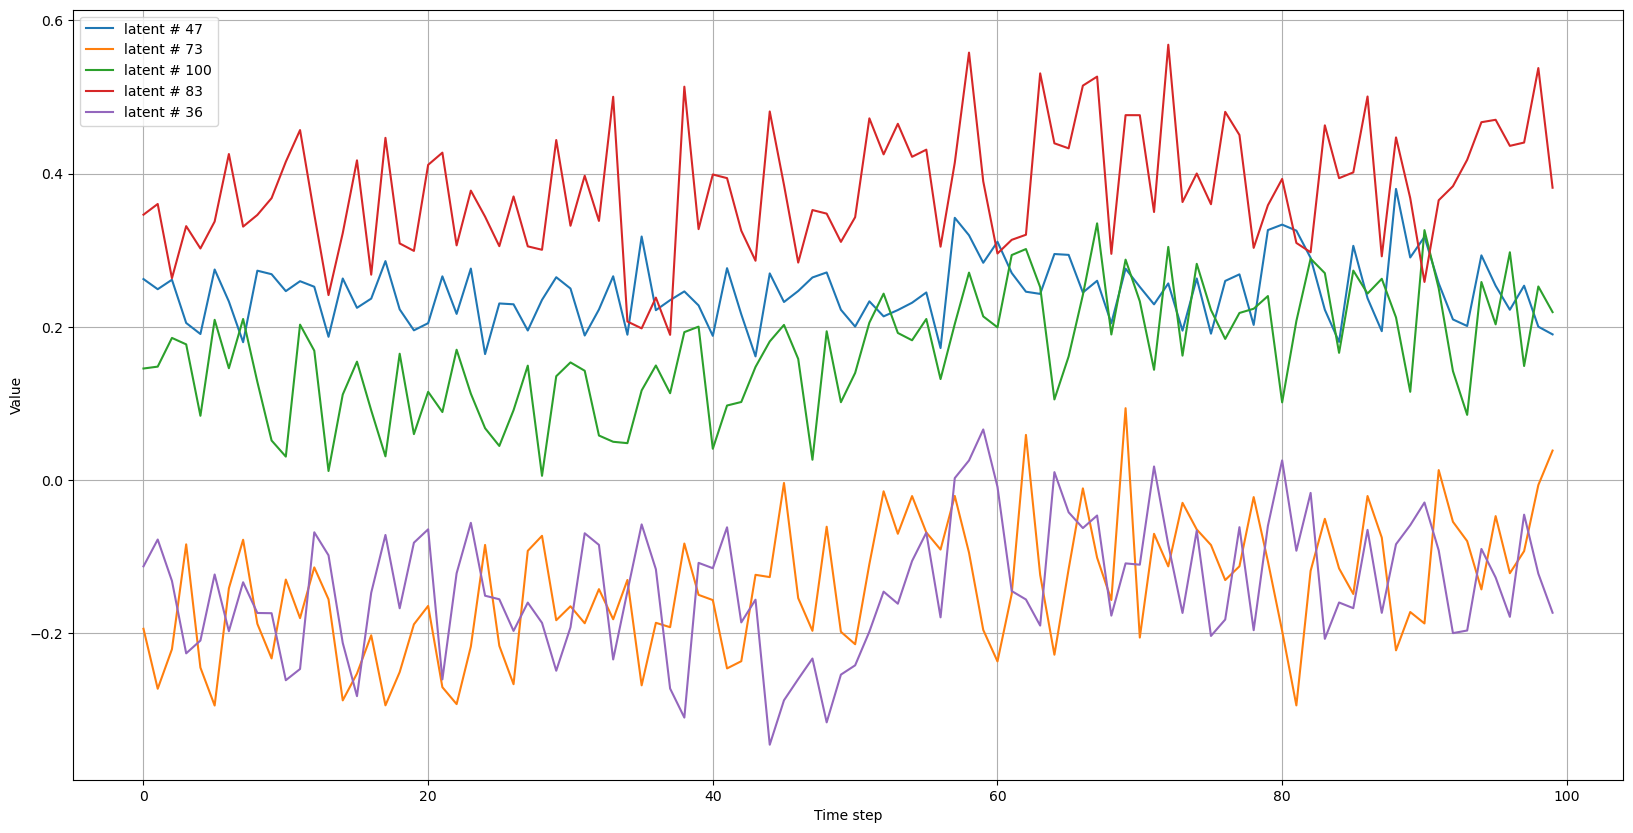

SHAPE: torch.Size([1, 128, 100])


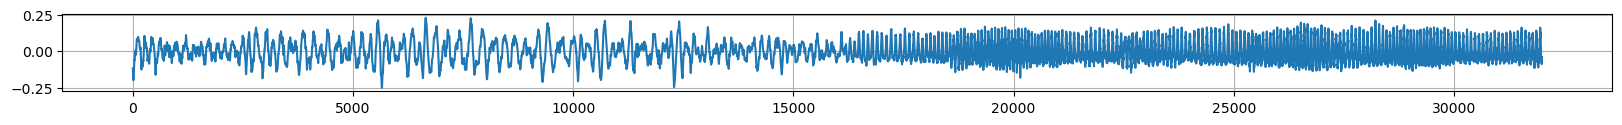

conditioning.shap = torch.Size([100, 8])


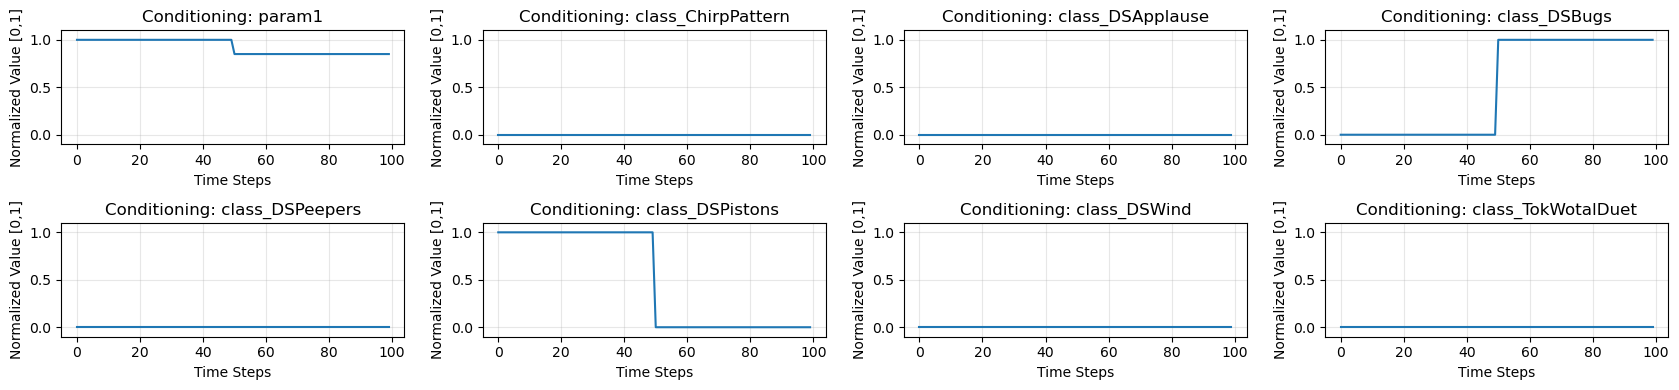

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvect25=samp[25, -model_config.cond_size:]
print(f"pvect[25]: {pvect25}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = torch.zeros((), device=device) # loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0   # start with 1.0; try 0.5 if still unstable
    )
     
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/TESTING/RNeNcodec/dev_notebooks/output/20260205_183830_datapreptest_dynamic_forkad/config_v2.pt
wrote json param file
wrote /home/lonce/TESTING/RNeNcodec/dev_notebooks/output/20260205_183830_datapreptest_dynamic_forkad/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=8, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=2, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.35, top_n_soft=8)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
#optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
optimizer = torch.optim.AdamW(
    rnn.parameters(),
    lr=params['lr'],
    betas=(0.9, 0.99),   # slightly less “sticky” than 0.999
    weight_decay=1e-4
)


criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2414632
latent_proj: 11,739
cond_proj:   333
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,414,632
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2026-02-05 18:38:30 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2026-02-05 18:39:21.469503, epoch 1,  Loss: 0.3308
  Quantizer 0 Loss: 3.8343
  Quantizer 1 Loss: 4.3524
  Quantizer 2 Loss: 4.6597
  Quantizer 3 Loss: 4.8872
  Quantizer 4 Loss: 5.0427
  Quantizer 5 Loss: 5.1335
  Quantizer 6 Loss: 5.2612
  Quantizer 7 Loss: 5.2930
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


/home/lonce/TESTING/RNeNcodec/rnencodec/generator/generator.py:163: UserWarning: Warning: ....... chunk size 300 is <= hop size 300. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


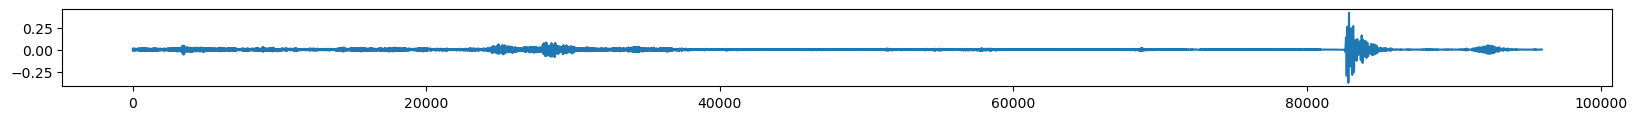

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2026-02-05 18:40:13.883281, epoch 2,  Loss: 0.3207
  Quantizer 0 Loss: 2.8046
  Quantizer 1 Loss: 3.4749
  Quantizer 2 Loss: 3.9713
  Quantizer 3 Loss: 4.2885
  Quantizer 4 Loss: 4.5005
  Quantizer 5 Loss: 4.6392
  Quantizer 6 Loss: 4.8073
  Quantizer 7 Loss: 4.8721
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


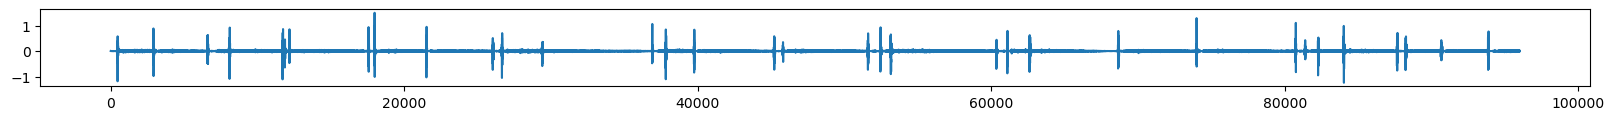

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2026-02-05 18:41:05.958964, epoch 3,  Loss: 0.3148
  Quantizer 0 Loss: 2.6215
  Quantizer 1 Loss: 3.3001
  Quantizer 2 Loss: 3.8329
  Quantizer 3 Loss: 4.1790
  Quantizer 4 Loss: 4.3994
  Quantizer 5 Loss: 4.5497
  Quantizer 6 Loss: 4.7238
  Quantizer 7 Loss: 4.7905
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


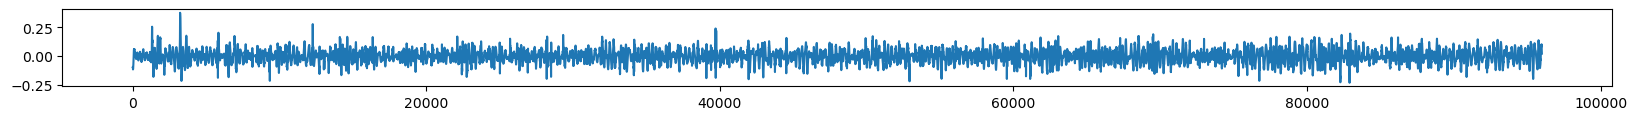

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2026-02-05 18:41:59.662291, epoch 4,  Loss: 0.3118
  Quantizer 0 Loss: 2.4955
  Quantizer 1 Loss: 3.1901
  Quantizer 2 Loss: 3.7511
  Quantizer 3 Loss: 4.1103
  Quantizer 4 Loss: 4.3418
  Quantizer 5 Loss: 4.5029
  Quantizer 6 Loss: 4.6775
  Quantizer 7 Loss: 4.7505
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


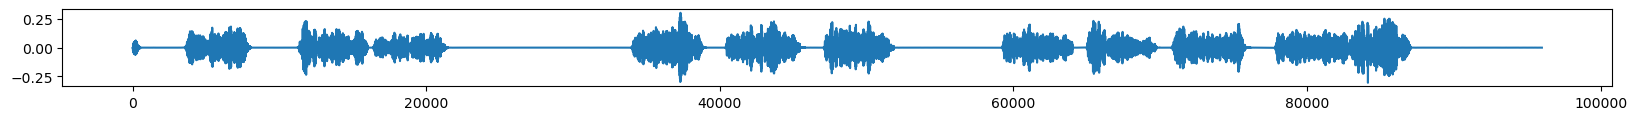

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2026-02-05 18:42:53.741431, epoch 5,  Loss: 0.2991
  Quantizer 0 Loss: 2.4021
  Quantizer 1 Loss: 3.0926
  Quantizer 2 Loss: 3.6781
  Quantizer 3 Loss: 4.0441
  Quantizer 4 Loss: 4.2865
  Quantizer 5 Loss: 4.4451
  Quantizer 6 Loss: 4.6291
  Quantizer 7 Loss: 4.7022
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


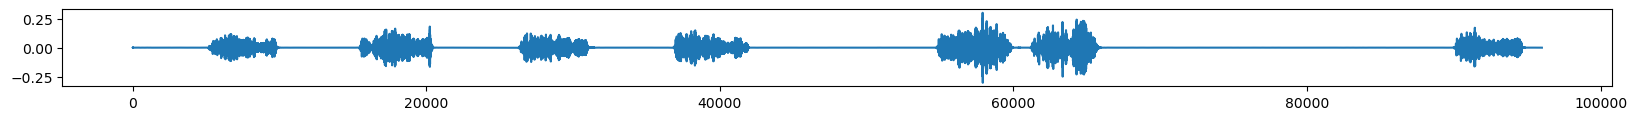

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2026-02-05 18:43:48.186922, epoch 6,  Loss: 0.3002
  Quantizer 0 Loss: 2.3571
  Quantizer 1 Loss: 3.0405
  Quantizer 2 Loss: 3.6287
  Quantizer 3 Loss: 4.0025
  Quantizer 4 Loss: 4.2501
  Quantizer 5 Loss: 4.4116
  Quantizer 6 Loss: 4.5981
  Quantizer 7 Loss: 4.6765
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


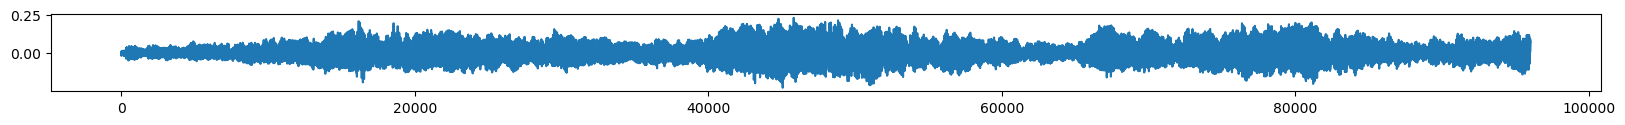

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2026-02-05 18:44:42.591814, epoch 7,  Loss: 0.3018
  Quantizer 0 Loss: 2.3236
  Quantizer 1 Loss: 3.0130
  Quantizer 2 Loss: 3.6048
  Quantizer 3 Loss: 3.9776
  Quantizer 4 Loss: 4.2293
  Quantizer 5 Loss: 4.3984
  Quantizer 6 Loss: 4.5828
  Quantizer 7 Loss: 4.6649
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


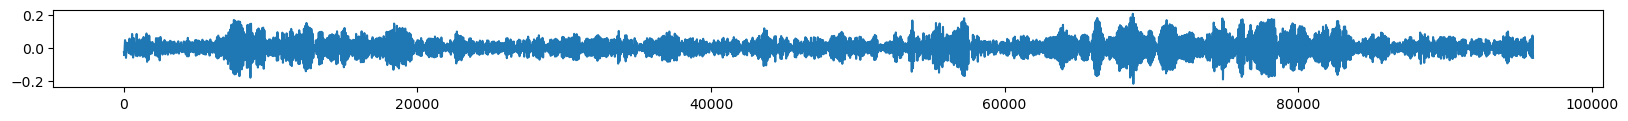

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2026-02-05 18:45:36.344333, epoch 8,  Loss: 0.2950
  Quantizer 0 Loss: 2.2901
  Quantizer 1 Loss: 2.9696
  Quantizer 2 Loss: 3.5662
  Quantizer 3 Loss: 3.9418
  Quantizer 4 Loss: 4.1988
  Quantizer 5 Loss: 4.3604
  Quantizer 6 Loss: 4.5462
  Quantizer 7 Loss: 4.6308
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


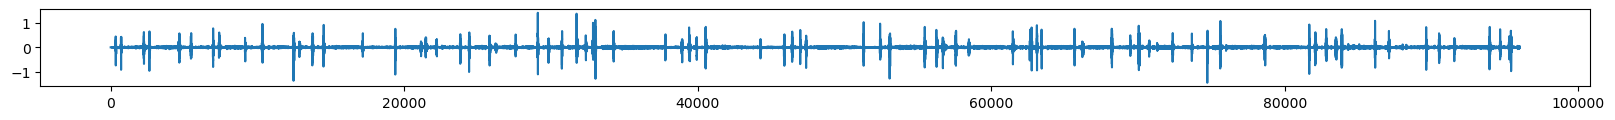

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2026-02-05 18:46:28.658884, epoch 9,  Loss: 0.3014
  Quantizer 0 Loss: 2.2674
  Quantizer 1 Loss: 2.9437
  Quantizer 2 Loss: 3.5405
  Quantizer 3 Loss: 3.9240
  Quantizer 4 Loss: 4.1796
  Quantizer 5 Loss: 4.3521
  Quantizer 6 Loss: 4.5378
  Quantizer 7 Loss: 4.6218
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


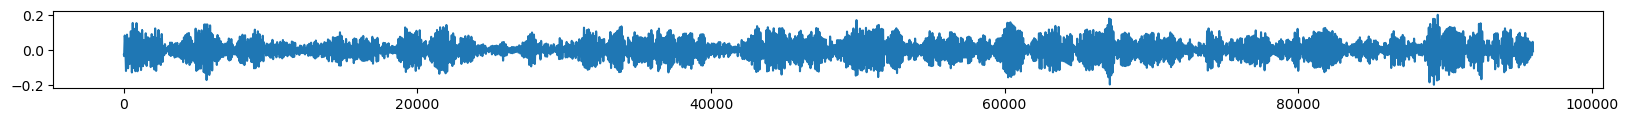

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2026-02-05 18:47:21.120646, epoch 10,  Loss: 0.2920
  Quantizer 0 Loss: 2.2408
  Quantizer 1 Loss: 2.9099
  Quantizer 2 Loss: 3.5115
  Quantizer 3 Loss: 3.8966
  Quantizer 4 Loss: 4.1516
  Quantizer 5 Loss: 4.3283
  Quantizer 6 Loss: 4.5138
  Quantizer 7 Loss: 4.6009
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


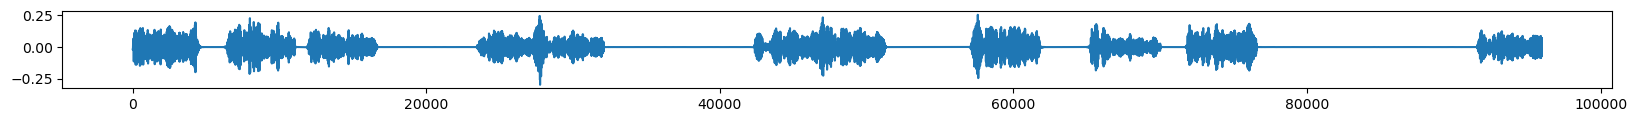

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2026-02-05 18:48:13.548046, epoch 11,  Loss: 0.2866
  Quantizer 0 Loss: 2.2283
  Quantizer 1 Loss: 2.8912
  Quantizer 2 Loss: 3.4963
  Quantizer 3 Loss: 3.8802
  Quantizer 4 Loss: 4.1417
  Quantizer 5 Loss: 4.3153
  Quantizer 6 Loss: 4.5027
  Quantizer 7 Loss: 4.5917
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


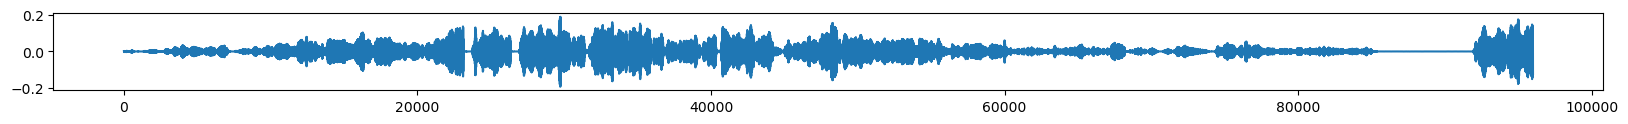

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2026-02-05 18:49:05.998428, epoch 12,  Loss: 0.2897
  Quantizer 0 Loss: 2.2085
  Quantizer 1 Loss: 2.8685
  Quantizer 2 Loss: 3.4704
  Quantizer 3 Loss: 3.8563
  Quantizer 4 Loss: 4.1097
  Quantizer 5 Loss: 4.2899
  Quantizer 6 Loss: 4.4745
  Quantizer 7 Loss: 4.5644
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


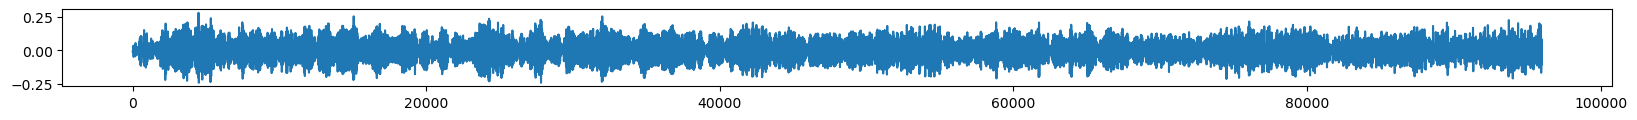

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2026-02-05 18:49:58.186521, epoch 13,  Loss: 0.2910
  Quantizer 0 Loss: 2.1901
  Quantizer 1 Loss: 2.8552
  Quantizer 2 Loss: 3.4530
  Quantizer 3 Loss: 3.8448
  Quantizer 4 Loss: 4.1085
  Quantizer 5 Loss: 4.2848
  Quantizer 6 Loss: 4.4805
  Quantizer 7 Loss: 4.5685
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


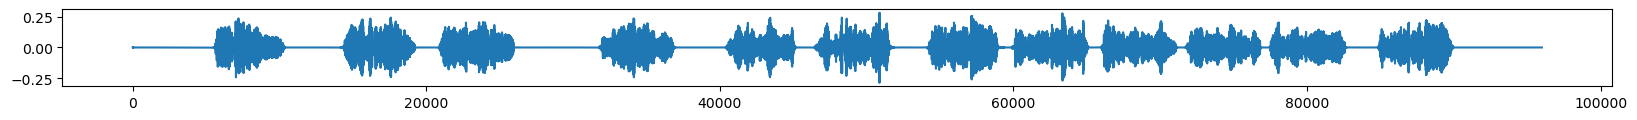

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2026-02-05 18:50:50.556555, epoch 14,  Loss: 0.2916
  Quantizer 0 Loss: 2.1874
  Quantizer 1 Loss: 2.8474
  Quantizer 2 Loss: 3.4505
  Quantizer 3 Loss: 3.8385
  Quantizer 4 Loss: 4.1016
  Quantizer 5 Loss: 4.2772
  Quantizer 6 Loss: 4.4673
  Quantizer 7 Loss: 4.5592
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


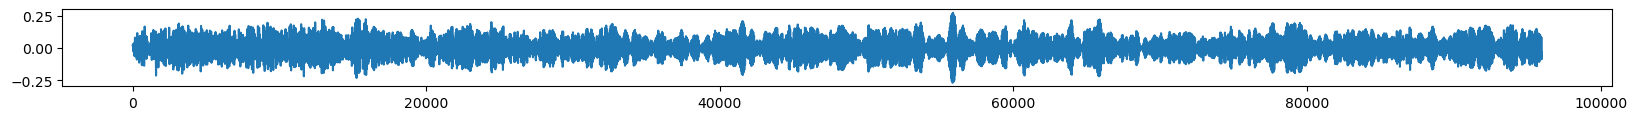

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2026-02-05 18:51:42.901972, epoch 15,  Loss: 0.2754
  Quantizer 0 Loss: 2.1885
  Quantizer 1 Loss: 2.8376
  Quantizer 2 Loss: 3.4361
  Quantizer 3 Loss: 3.8306
  Quantizer 4 Loss: 4.0937
  Quantizer 5 Loss: 4.2739
  Quantizer 6 Loss: 4.4603
  Quantizer 7 Loss: 4.5595
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


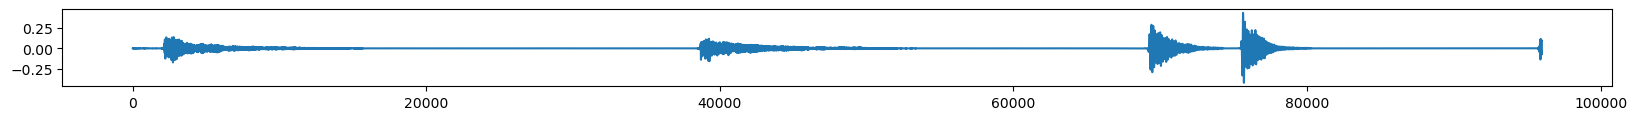

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2026-02-05 18:52:35.421086, epoch 16,  Loss: 0.2849
  Quantizer 0 Loss: 2.1777
  Quantizer 1 Loss: 2.8280
  Quantizer 2 Loss: 3.4350
  Quantizer 3 Loss: 3.8242
  Quantizer 4 Loss: 4.0880
  Quantizer 5 Loss: 4.2632
  Quantizer 6 Loss: 4.4551
  Quantizer 7 Loss: 4.5467
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


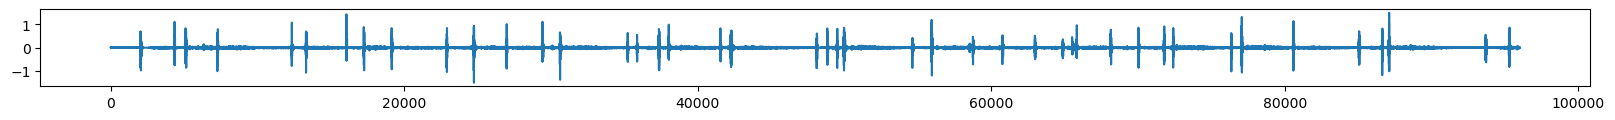

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2026-02-05 18:53:27.882913, epoch 17,  Loss: 0.2880
  Quantizer 0 Loss: 2.1703
  Quantizer 1 Loss: 2.8193
  Quantizer 2 Loss: 3.4112
  Quantizer 3 Loss: 3.8040
  Quantizer 4 Loss: 4.0685
  Quantizer 5 Loss: 4.2473
  Quantizer 6 Loss: 4.4367
  Quantizer 7 Loss: 4.5282
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


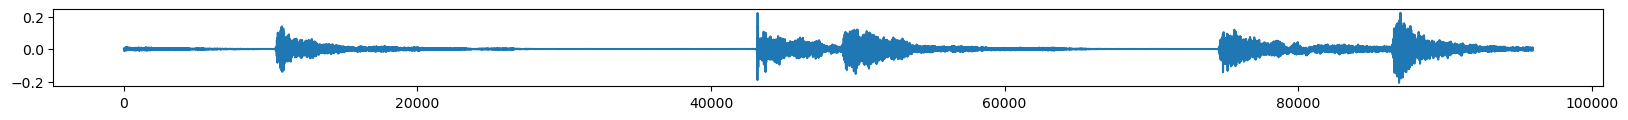

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2026-02-05 18:54:20.809659, epoch 18,  Loss: 0.2859
  Quantizer 0 Loss: 2.1633
  Quantizer 1 Loss: 2.8242
  Quantizer 2 Loss: 3.4244
  Quantizer 3 Loss: 3.8162
  Quantizer 4 Loss: 4.0867
  Quantizer 5 Loss: 4.2678
  Quantizer 6 Loss: 4.4636
  Quantizer 7 Loss: 4.5511
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


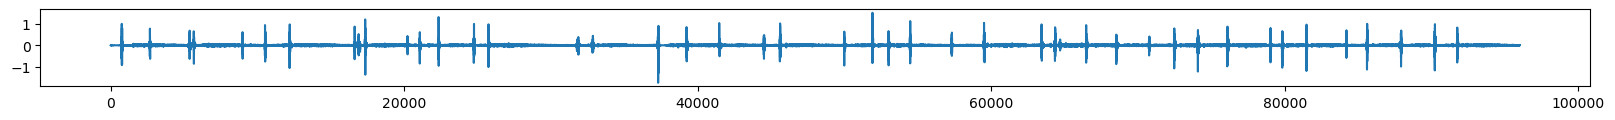

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2026-02-05 18:55:13.217000, epoch 19,  Loss: 0.2856
  Quantizer 0 Loss: 2.1483
  Quantizer 1 Loss: 2.7967
  Quantizer 2 Loss: 3.3963
  Quantizer 3 Loss: 3.7835
  Quantizer 4 Loss: 4.0454
  Quantizer 5 Loss: 4.2275
  Quantizer 6 Loss: 4.4198
  Quantizer 7 Loss: 4.5149
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


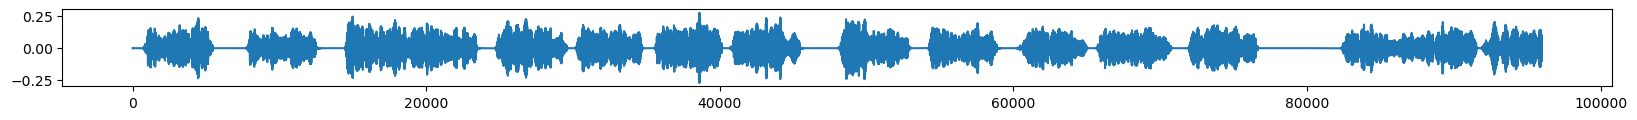

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2026-02-05 18:56:05.635313, epoch 20,  Loss: 0.2734
  Quantizer 0 Loss: 2.1557
  Quantizer 1 Loss: 2.8071
  Quantizer 2 Loss: 3.4116
  Quantizer 3 Loss: 3.8012
  Quantizer 4 Loss: 4.0698
  Quantizer 5 Loss: 4.2524
  Quantizer 6 Loss: 4.4404
  Quantizer 7 Loss: 4.5360
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


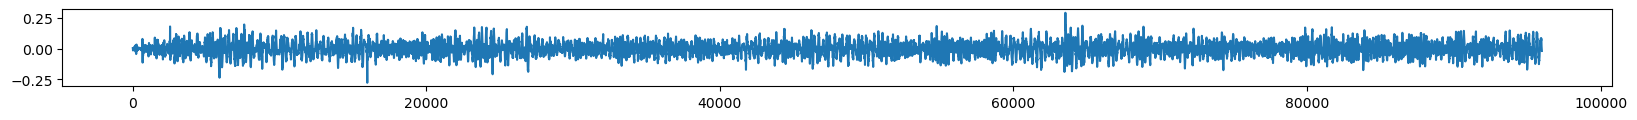

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2026-02-05 18:56:57.580975, epoch 21,  Loss: 0.2754
  Quantizer 0 Loss: 2.1302
  Quantizer 1 Loss: 2.7852
  Quantizer 2 Loss: 3.3840
  Quantizer 3 Loss: 3.7793
  Quantizer 4 Loss: 4.0492
  Quantizer 5 Loss: 4.2329
  Quantizer 6 Loss: 4.4310
  Quantizer 7 Loss: 4.5238
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


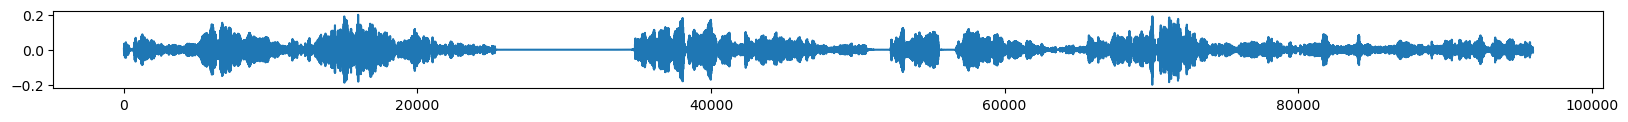

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2026-02-05 18:57:49.945428, epoch 22,  Loss: 0.2784
  Quantizer 0 Loss: 2.1372
  Quantizer 1 Loss: 2.7860
  Quantizer 2 Loss: 3.3798
  Quantizer 3 Loss: 3.7736
  Quantizer 4 Loss: 4.0344
  Quantizer 5 Loss: 4.2215
  Quantizer 6 Loss: 4.4134
  Quantizer 7 Loss: 4.5070
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


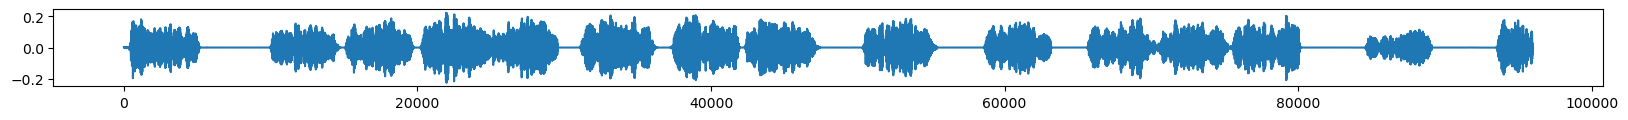

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2026-02-05 18:58:42.175554, epoch 23,  Loss: 0.2854
  Quantizer 0 Loss: 2.1396
  Quantizer 1 Loss: 2.7770
  Quantizer 2 Loss: 3.3778
  Quantizer 3 Loss: 3.7707
  Quantizer 4 Loss: 4.0403
  Quantizer 5 Loss: 4.2178
  Quantizer 6 Loss: 4.4118
  Quantizer 7 Loss: 4.5096
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


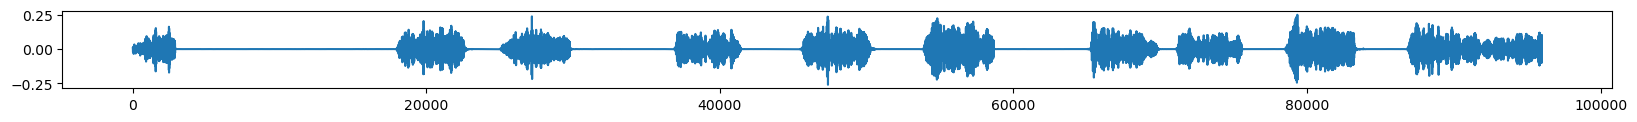

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2026-02-05 18:59:34.470396, epoch 24,  Loss: 0.2869
  Quantizer 0 Loss: 2.1191
  Quantizer 1 Loss: 2.7590
  Quantizer 2 Loss: 3.3600
  Quantizer 3 Loss: 3.7537
  Quantizer 4 Loss: 4.0257
  Quantizer 5 Loss: 4.2024
  Quantizer 6 Loss: 4.4021
  Quantizer 7 Loss: 4.4985
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


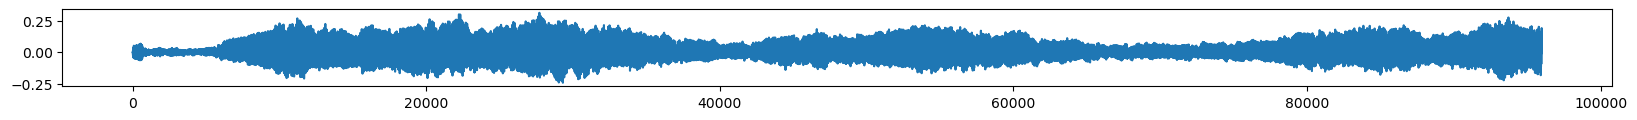

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2026-02-05 19:00:26.597385, epoch 25,  Loss: 0.2815
  Quantizer 0 Loss: 2.1379
  Quantizer 1 Loss: 2.7821
  Quantizer 2 Loss: 3.3824
  Quantizer 3 Loss: 3.7784
  Quantizer 4 Loss: 4.0504
  Quantizer 5 Loss: 4.2300
  Quantizer 6 Loss: 4.4273
  Quantizer 7 Loss: 4.5256
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


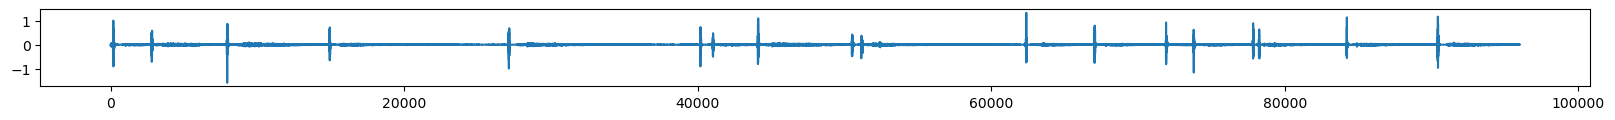

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2026-02-05 19:01:18.834764, epoch 26,  Loss: 0.3233
  Quantizer 0 Loss: 2.1831
  Quantizer 1 Loss: 3.3523
  Quantizer 2 Loss: 4.0667
  Quantizer 3 Loss: 4.4512
  Quantizer 4 Loss: 4.6934
  Quantizer 5 Loss: 4.8309
  Quantizer 6 Loss: 5.0111
  Quantizer 7 Loss: 5.0758
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


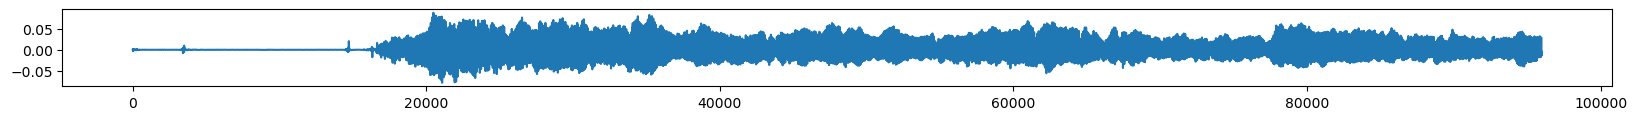

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2026-02-05 19:02:11.633127, epoch 27,  Loss: 0.3333
  Quantizer 0 Loss: 2.1640
  Quantizer 1 Loss: 3.2735
  Quantizer 2 Loss: 4.0017
  Quantizer 3 Loss: 4.3966
  Quantizer 4 Loss: 4.6521
  Quantizer 5 Loss: 4.8030
  Quantizer 6 Loss: 4.9828
  Quantizer 7 Loss: 5.0493
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


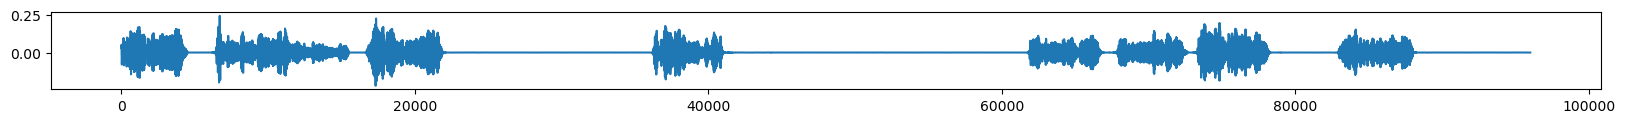

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2026-02-05 19:03:04.194690, epoch 28,  Loss: 0.3164
  Quantizer 0 Loss: 2.1506
  Quantizer 1 Loss: 3.2461
  Quantizer 2 Loss: 3.9744
  Quantizer 3 Loss: 4.3776
  Quantizer 4 Loss: 4.6359
  Quantizer 5 Loss: 4.7895
  Quantizer 6 Loss: 4.9731
  Quantizer 7 Loss: 5.0444
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


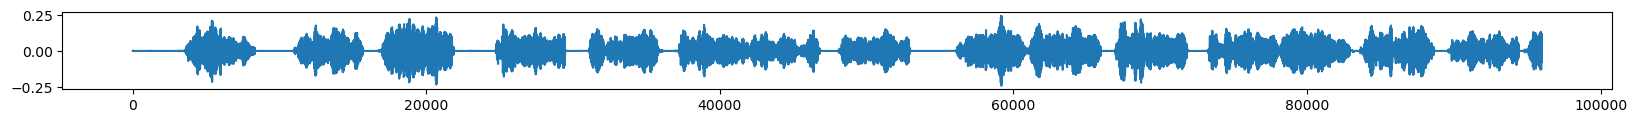

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2026-02-05 19:03:56.719728, epoch 29,  Loss: 0.3220
  Quantizer 0 Loss: 2.1455
  Quantizer 1 Loss: 3.2264
  Quantizer 2 Loss: 3.9594
  Quantizer 3 Loss: 4.3592
  Quantizer 4 Loss: 4.6251
  Quantizer 5 Loss: 4.7812
  Quantizer 6 Loss: 4.9622
  Quantizer 7 Loss: 5.0340
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


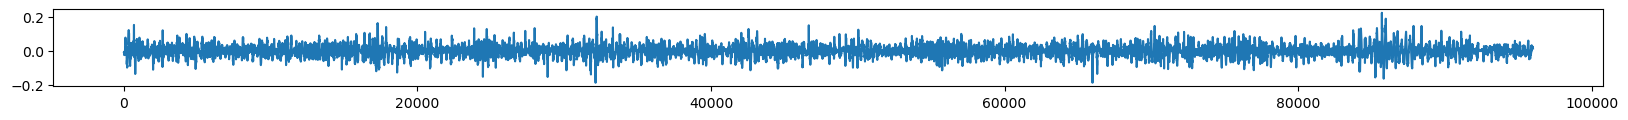

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2026-02-05 19:04:49.000706, epoch 30,  Loss: 0.3168
  Quantizer 0 Loss: 2.1348
  Quantizer 1 Loss: 3.2023
  Quantizer 2 Loss: 3.9400
  Quantizer 3 Loss: 4.3491
  Quantizer 4 Loss: 4.6132
  Quantizer 5 Loss: 4.7751
  Quantizer 6 Loss: 4.9513
  Quantizer 7 Loss: 5.0251
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


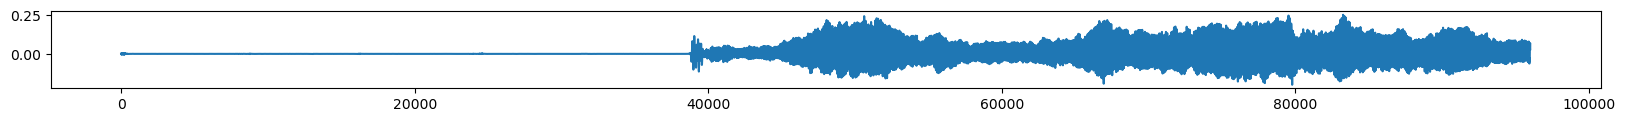

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2026-02-05 19:05:41.478939, epoch 31,  Loss: 0.3083
  Quantizer 0 Loss: 2.1274
  Quantizer 1 Loss: 3.1942
  Quantizer 2 Loss: 3.9201
  Quantizer 3 Loss: 4.3308
  Quantizer 4 Loss: 4.5972
  Quantizer 5 Loss: 4.7566
  Quantizer 6 Loss: 4.9366
  Quantizer 7 Loss: 5.0124
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


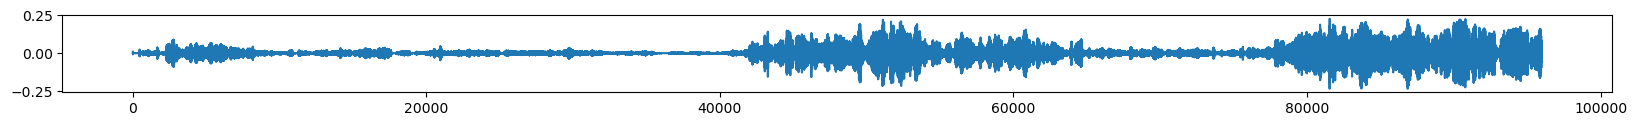

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2026-02-05 19:06:33.820360, epoch 32,  Loss: 0.3162
  Quantizer 0 Loss: 2.1283
  Quantizer 1 Loss: 3.1837
  Quantizer 2 Loss: 3.9218
  Quantizer 3 Loss: 4.3363
  Quantizer 4 Loss: 4.5973
  Quantizer 5 Loss: 4.7601
  Quantizer 6 Loss: 4.9406
  Quantizer 7 Loss: 5.0114
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


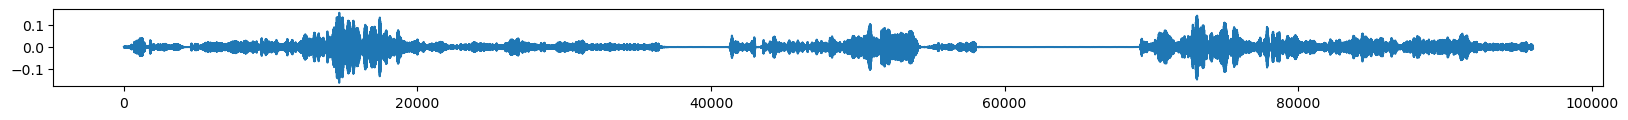

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2026-02-05 19:07:26.479503, epoch 33,  Loss: 0.3161
  Quantizer 0 Loss: 2.1086
  Quantizer 1 Loss: 3.1758
  Quantizer 2 Loss: 3.9030
  Quantizer 3 Loss: 4.3206
  Quantizer 4 Loss: 4.5865
  Quantizer 5 Loss: 4.7536
  Quantizer 6 Loss: 4.9326
  Quantizer 7 Loss: 5.0070
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


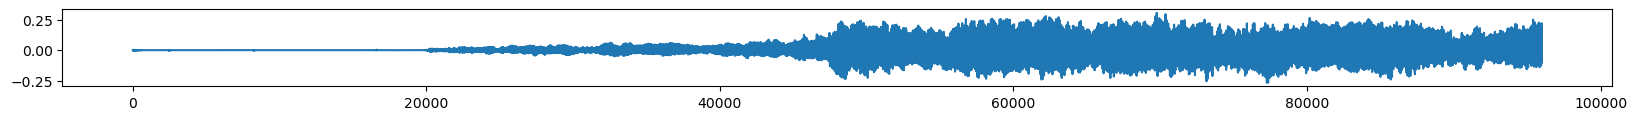

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2026-02-05 19:08:19.164950, epoch 34,  Loss: 0.3155
  Quantizer 0 Loss: 2.1254
  Quantizer 1 Loss: 3.1858
  Quantizer 2 Loss: 3.9192
  Quantizer 3 Loss: 4.3279
  Quantizer 4 Loss: 4.5975
  Quantizer 5 Loss: 4.7579
  Quantizer 6 Loss: 4.9394
  Quantizer 7 Loss: 5.0132
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


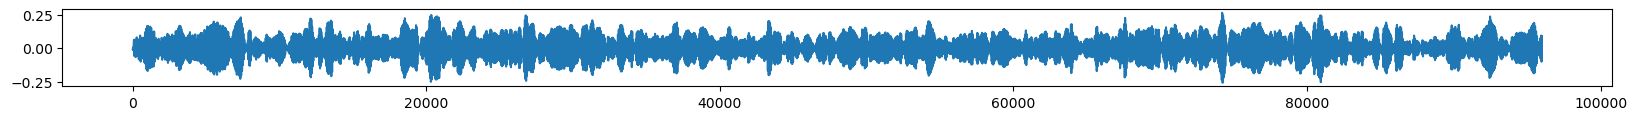

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2026-02-05 19:09:11.726822, epoch 35,  Loss: 0.3199
  Quantizer 0 Loss: 2.1225
  Quantizer 1 Loss: 3.1794
  Quantizer 2 Loss: 3.9166
  Quantizer 3 Loss: 4.3259
  Quantizer 4 Loss: 4.5941
  Quantizer 5 Loss: 4.7519
  Quantizer 6 Loss: 4.9323
  Quantizer 7 Loss: 5.0096
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


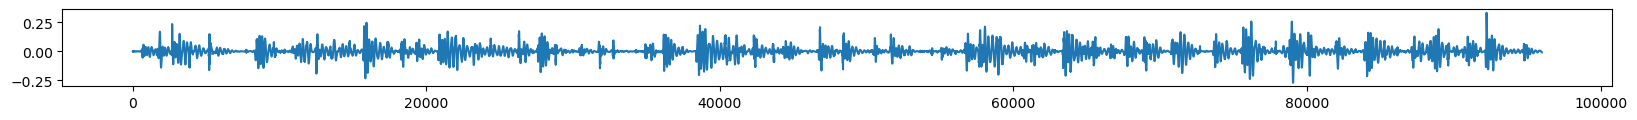

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2026-02-05 19:10:04.396943, epoch 36,  Loss: 0.3249
  Quantizer 0 Loss: 2.1146
  Quantizer 1 Loss: 3.1609
  Quantizer 2 Loss: 3.8954
  Quantizer 3 Loss: 4.3009
  Quantizer 4 Loss: 4.5683
  Quantizer 5 Loss: 4.7304
  Quantizer 6 Loss: 4.9116
  Quantizer 7 Loss: 4.9869
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


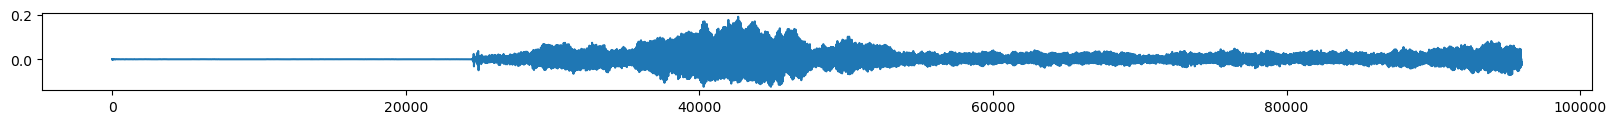

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2026-02-05 19:10:57.011839, epoch 37,  Loss: 0.3156
  Quantizer 0 Loss: 2.1207
  Quantizer 1 Loss: 3.1829
  Quantizer 2 Loss: 3.9054
  Quantizer 3 Loss: 4.3151
  Quantizer 4 Loss: 4.5809
  Quantizer 5 Loss: 4.7477
  Quantizer 6 Loss: 4.9295
  Quantizer 7 Loss: 5.0096
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


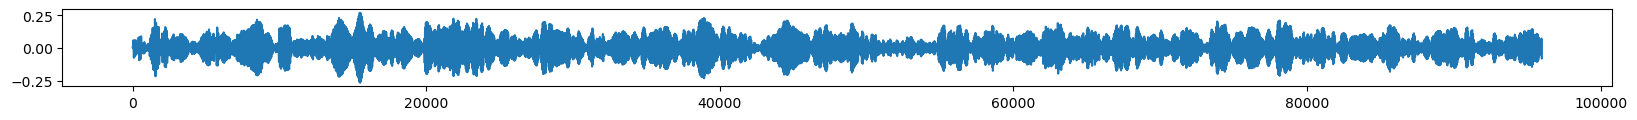

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2026-02-05 19:11:49.258665, epoch 38,  Loss: 0.3230
  Quantizer 0 Loss: 2.1129
  Quantizer 1 Loss: 3.1588
  Quantizer 2 Loss: 3.8913
  Quantizer 3 Loss: 4.3053
  Quantizer 4 Loss: 4.5700
  Quantizer 5 Loss: 4.7371
  Quantizer 6 Loss: 4.9193
  Quantizer 7 Loss: 4.9960
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


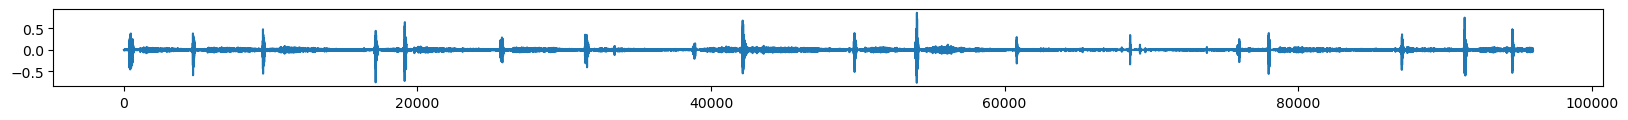

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2026-02-05 19:12:41.798276, epoch 39,  Loss: 0.3140
  Quantizer 0 Loss: 2.1277
  Quantizer 1 Loss: 3.1714
  Quantizer 2 Loss: 3.8985
  Quantizer 3 Loss: 4.3078
  Quantizer 4 Loss: 4.5773
  Quantizer 5 Loss: 4.7411
  Quantizer 6 Loss: 4.9183
  Quantizer 7 Loss: 4.9956
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


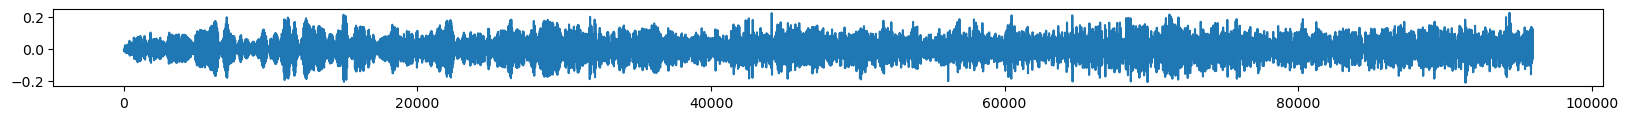

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2026-02-05 19:13:34.317665, epoch 40,  Loss: 0.3151
  Quantizer 0 Loss: 2.0996
  Quantizer 1 Loss: 3.1561
  Quantizer 2 Loss: 3.8856
  Quantizer 3 Loss: 4.2967
  Quantizer 4 Loss: 4.5679
  Quantizer 5 Loss: 4.7376
  Quantizer 6 Loss: 4.9140
  Quantizer 7 Loss: 4.9910
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


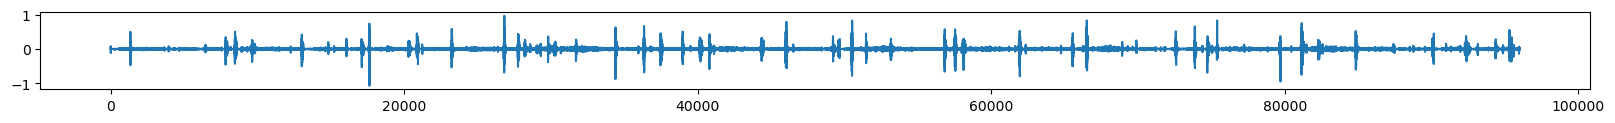

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2026-02-05 19:14:26.949333, epoch 41,  Loss: 0.3181
  Quantizer 0 Loss: 2.1077
  Quantizer 1 Loss: 3.1590
  Quantizer 2 Loss: 3.8904
  Quantizer 3 Loss: 4.3067
  Quantizer 4 Loss: 4.5775
  Quantizer 5 Loss: 4.7418
  Quantizer 6 Loss: 4.9240
  Quantizer 7 Loss: 5.0007
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


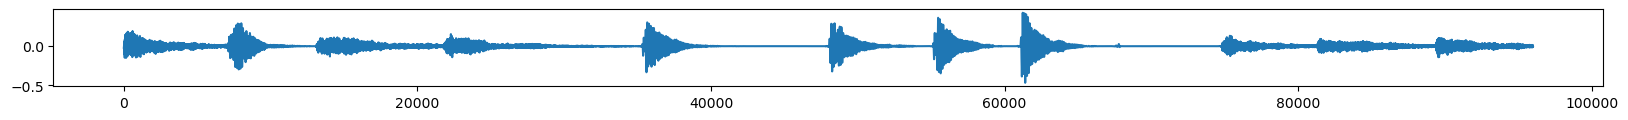

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2026-02-05 19:15:19.702018, epoch 42,  Loss: 0.3127
  Quantizer 0 Loss: 2.0986
  Quantizer 1 Loss: 3.1469
  Quantizer 2 Loss: 3.8786
  Quantizer 3 Loss: 4.2978
  Quantizer 4 Loss: 4.5725
  Quantizer 5 Loss: 4.7397
  Quantizer 6 Loss: 4.9235
  Quantizer 7 Loss: 5.0008
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


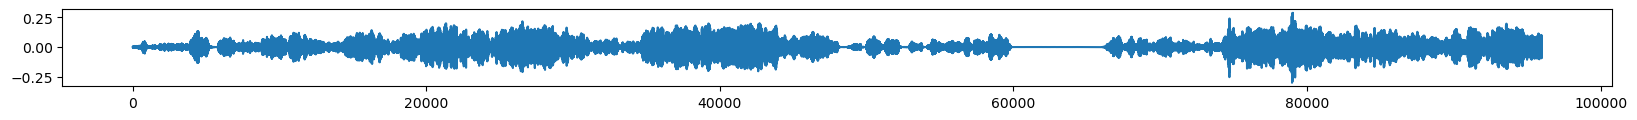

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2026-02-05 19:16:12.272995, epoch 43,  Loss: 0.3087
  Quantizer 0 Loss: 2.1036
  Quantizer 1 Loss: 3.1562
  Quantizer 2 Loss: 3.8839
  Quantizer 3 Loss: 4.2979
  Quantizer 4 Loss: 4.5669
  Quantizer 5 Loss: 4.7324
  Quantizer 6 Loss: 4.9171
  Quantizer 7 Loss: 4.9917
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


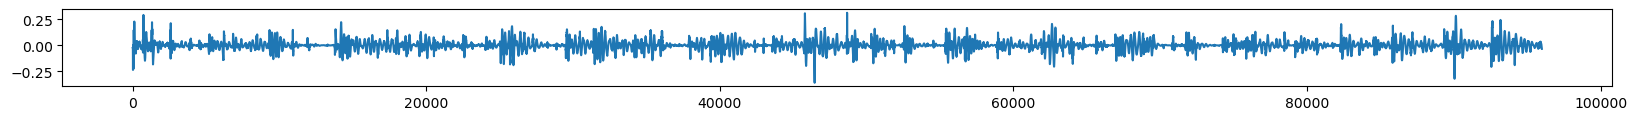

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2026-02-05 19:17:05.013290, epoch 44,  Loss: 0.3165
  Quantizer 0 Loss: 2.1012
  Quantizer 1 Loss: 3.1386
  Quantizer 2 Loss: 3.8729
  Quantizer 3 Loss: 4.2844
  Quantizer 4 Loss: 4.5535
  Quantizer 5 Loss: 4.7140
  Quantizer 6 Loss: 4.8985
  Quantizer 7 Loss: 4.9765
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


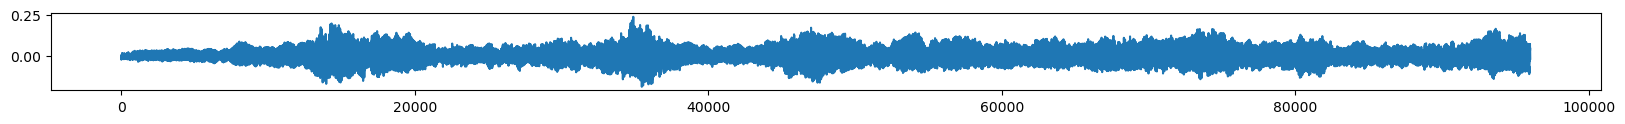

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2026-02-05 19:17:57.529577, epoch 45,  Loss: 0.3093
  Quantizer 0 Loss: 2.0899
  Quantizer 1 Loss: 3.1360
  Quantizer 2 Loss: 3.8728
  Quantizer 3 Loss: 4.2901
  Quantizer 4 Loss: 4.5618
  Quantizer 5 Loss: 4.7336
  Quantizer 6 Loss: 4.9133
  Quantizer 7 Loss: 4.9915
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


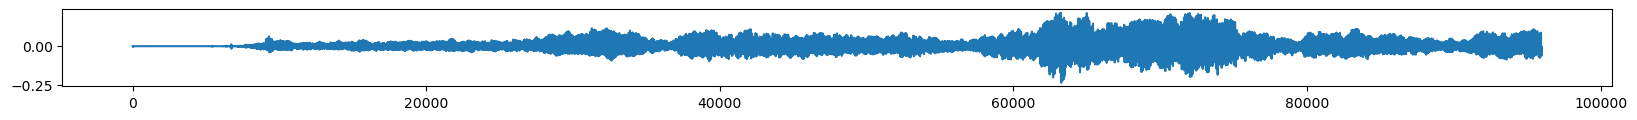

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2026-02-05 19:18:50.038924, epoch 46,  Loss: 0.3290
  Quantizer 0 Loss: 2.1004
  Quantizer 1 Loss: 3.1511
  Quantizer 2 Loss: 3.8816
  Quantizer 3 Loss: 4.2974
  Quantizer 4 Loss: 4.5726
  Quantizer 5 Loss: 4.7378
  Quantizer 6 Loss: 4.9227
  Quantizer 7 Loss: 5.0013
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


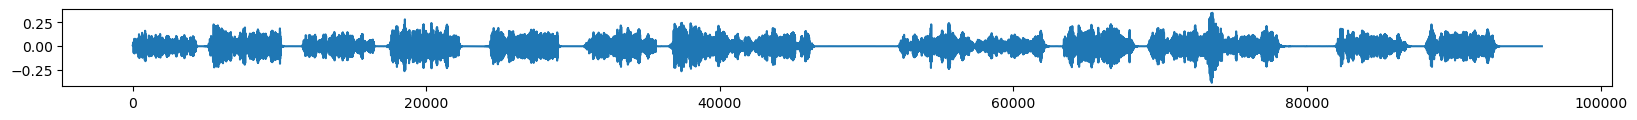

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2026-02-05 19:19:42.489315, epoch 47,  Loss: 0.3086
  Quantizer 0 Loss: 2.0924
  Quantizer 1 Loss: 3.1297
  Quantizer 2 Loss: 3.8598
  Quantizer 3 Loss: 4.2766
  Quantizer 4 Loss: 4.5487
  Quantizer 5 Loss: 4.7148
  Quantizer 6 Loss: 4.8971
  Quantizer 7 Loss: 4.9774
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


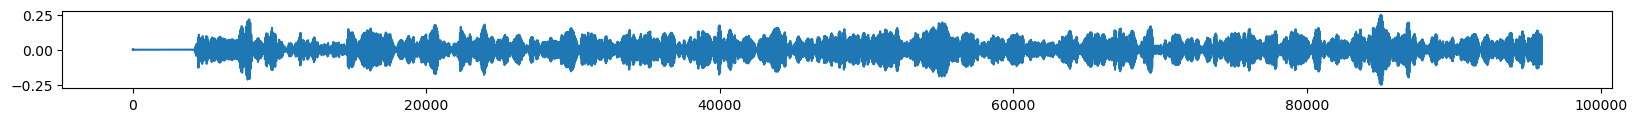

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2026-02-05 19:20:35.104704, epoch 48,  Loss: 0.3098
  Quantizer 0 Loss: 2.0934
  Quantizer 1 Loss: 3.1335
  Quantizer 2 Loss: 3.8692
  Quantizer 3 Loss: 4.2853
  Quantizer 4 Loss: 4.5549
  Quantizer 5 Loss: 4.7241
  Quantizer 6 Loss: 4.9076
  Quantizer 7 Loss: 4.9839
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


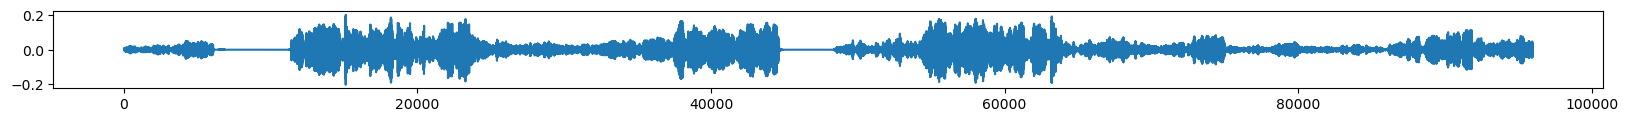

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2026-02-05 19:21:27.505047, epoch 49,  Loss: 0.3257
  Quantizer 0 Loss: 2.0837
  Quantizer 1 Loss: 3.1232
  Quantizer 2 Loss: 3.8547
  Quantizer 3 Loss: 4.2664
  Quantizer 4 Loss: 4.5377
  Quantizer 5 Loss: 4.7069
  Quantizer 6 Loss: 4.8847
  Quantizer 7 Loss: 4.9649
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


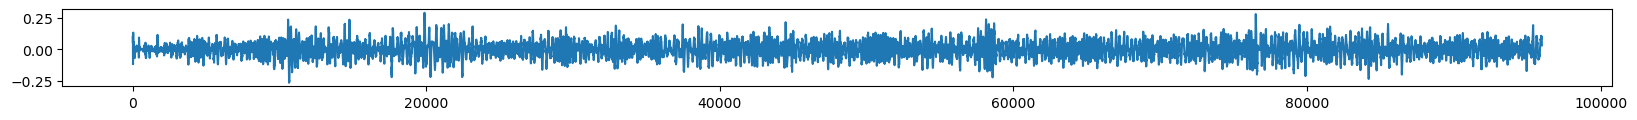

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2026-02-05 19:22:20.033541, epoch 50,  Loss: 0.3220
  Quantizer 0 Loss: 2.0854
  Quantizer 1 Loss: 3.1288
  Quantizer 2 Loss: 3.8593
  Quantizer 3 Loss: 4.2739
  Quantizer 4 Loss: 4.5489
  Quantizer 5 Loss: 4.7137
  Quantizer 6 Loss: 4.8982
  Quantizer 7 Loss: 4.9813
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


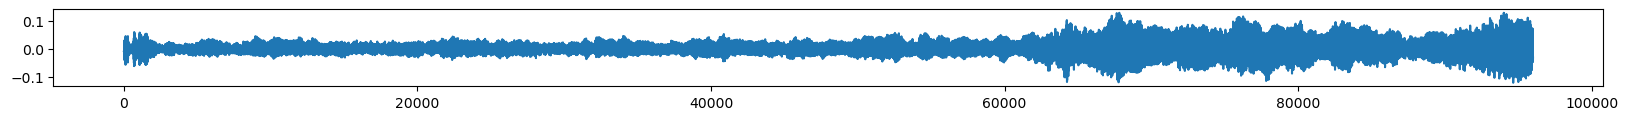

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2026-02-05 19:23:12.492197, epoch 51,  Loss: 0.2788
  Quantizer 0 Loss: 2.0911
  Quantizer 1 Loss: 2.8006
  Quantizer 2 Loss: 3.4732
  Quantizer 3 Loss: 3.8925
  Quantizer 4 Loss: 4.1805
  Quantizer 5 Loss: 4.3715
  Quantizer 6 Loss: 4.5700
  Quantizer 7 Loss: 4.6658
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


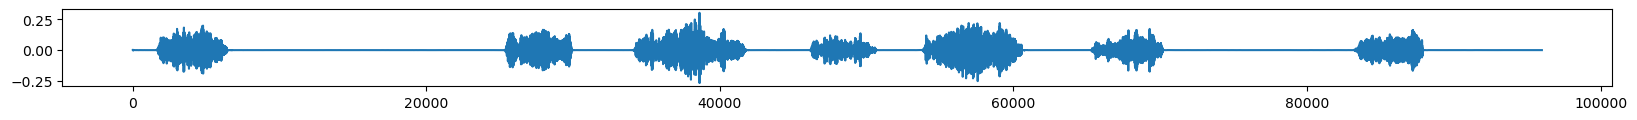

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2026-02-05 19:24:04.804445, epoch 52,  Loss: 0.2831
  Quantizer 0 Loss: 2.0811
  Quantizer 1 Loss: 2.7495
  Quantizer 2 Loss: 3.3730
  Quantizer 3 Loss: 3.7883
  Quantizer 4 Loss: 4.0703
  Quantizer 5 Loss: 4.2605
  Quantizer 6 Loss: 4.4633
  Quantizer 7 Loss: 4.5642
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


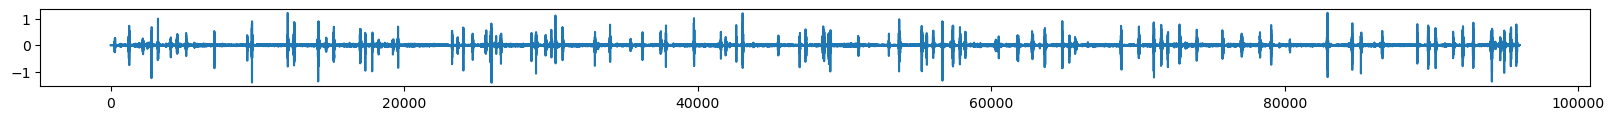

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2026-02-05 19:24:57.168555, epoch 53,  Loss: 0.2882
  Quantizer 0 Loss: 2.0790
  Quantizer 1 Loss: 2.7354
  Quantizer 2 Loss: 3.3555
  Quantizer 3 Loss: 3.7607
  Quantizer 4 Loss: 4.0423
  Quantizer 5 Loss: 4.2278
  Quantizer 6 Loss: 4.4252
  Quantizer 7 Loss: 4.5292
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


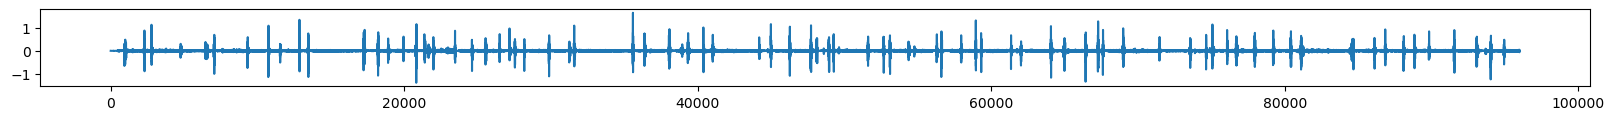

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2026-02-05 19:25:49.481622, epoch 54,  Loss: 0.2871
  Quantizer 0 Loss: 2.0834
  Quantizer 1 Loss: 2.7373
  Quantizer 2 Loss: 3.3532
  Quantizer 3 Loss: 3.7546
  Quantizer 4 Loss: 4.0368
  Quantizer 5 Loss: 4.2283
  Quantizer 6 Loss: 4.4212
  Quantizer 7 Loss: 4.5209
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


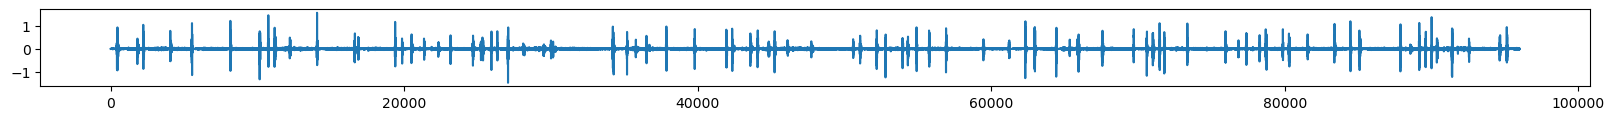

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2026-02-05 19:26:41.706373, epoch 55,  Loss: 0.2895
  Quantizer 0 Loss: 2.0848
  Quantizer 1 Loss: 2.7395
  Quantizer 2 Loss: 3.3482
  Quantizer 3 Loss: 3.7473
  Quantizer 4 Loss: 4.0295
  Quantizer 5 Loss: 4.2195
  Quantizer 6 Loss: 4.4203
  Quantizer 7 Loss: 4.5149
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


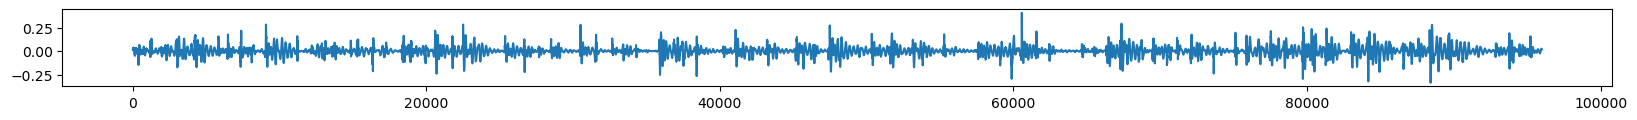

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2026-02-05 19:27:33.827792, epoch 56,  Loss: 0.2739
  Quantizer 0 Loss: 2.0849
  Quantizer 1 Loss: 2.7358
  Quantizer 2 Loss: 3.3362
  Quantizer 3 Loss: 3.7337
  Quantizer 4 Loss: 4.0104
  Quantizer 5 Loss: 4.2022
  Quantizer 6 Loss: 4.3987
  Quantizer 7 Loss: 4.5016
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


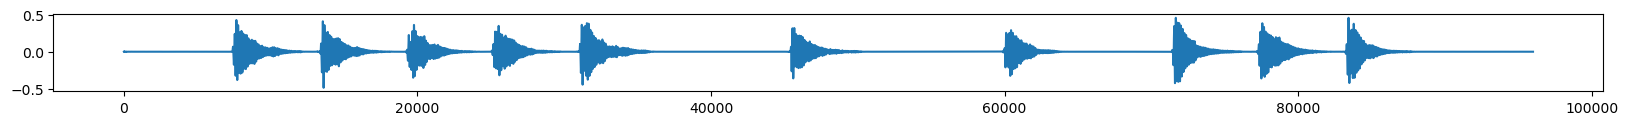

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2026-02-05 19:28:26.287241, epoch 57,  Loss: 0.2850
  Quantizer 0 Loss: 2.0580
  Quantizer 1 Loss: 2.7119
  Quantizer 2 Loss: 3.3146
  Quantizer 3 Loss: 3.7191
  Quantizer 4 Loss: 3.9944
  Quantizer 5 Loss: 4.1815
  Quantizer 6 Loss: 4.3798
  Quantizer 7 Loss: 4.4844
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


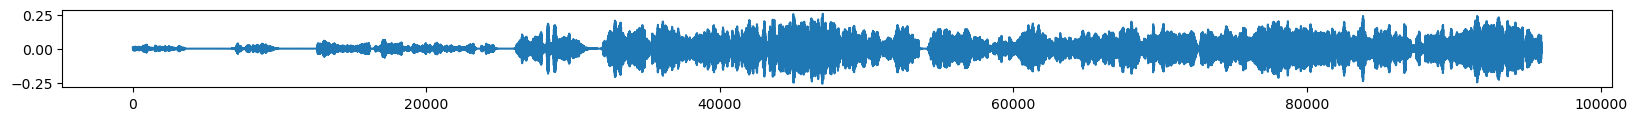

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2026-02-05 19:29:18.514866, epoch 58,  Loss: 0.2881
  Quantizer 0 Loss: 2.0753
  Quantizer 1 Loss: 2.7272
  Quantizer 2 Loss: 3.3265
  Quantizer 3 Loss: 3.7250
  Quantizer 4 Loss: 3.9920
  Quantizer 5 Loss: 4.1847
  Quantizer 6 Loss: 4.3805
  Quantizer 7 Loss: 4.4793
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


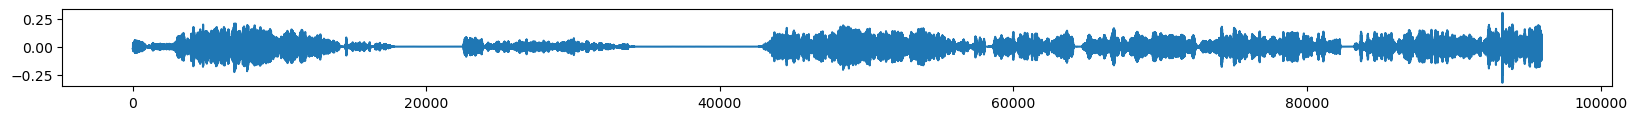

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2026-02-05 19:30:10.855355, epoch 59,  Loss: 0.2621
  Quantizer 0 Loss: 2.0818
  Quantizer 1 Loss: 2.7216
  Quantizer 2 Loss: 3.3277
  Quantizer 3 Loss: 3.7246
  Quantizer 4 Loss: 4.0012
  Quantizer 5 Loss: 4.1891
  Quantizer 6 Loss: 4.3822
  Quantizer 7 Loss: 4.4849
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


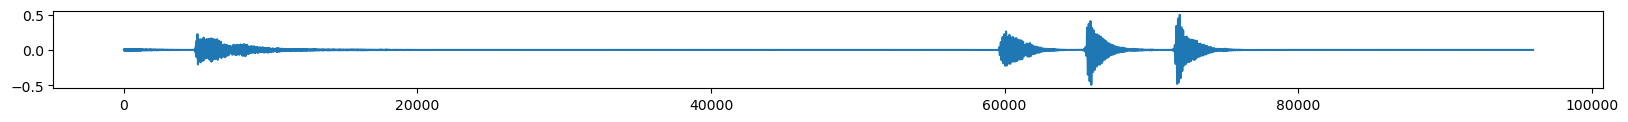

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2026-02-05 19:31:03.146450, epoch 60,  Loss: 0.2897
  Quantizer 0 Loss: 2.0712
  Quantizer 1 Loss: 2.7146
  Quantizer 2 Loss: 3.3179
  Quantizer 3 Loss: 3.7192
  Quantizer 4 Loss: 3.9967
  Quantizer 5 Loss: 4.1854
  Quantizer 6 Loss: 4.3849
  Quantizer 7 Loss: 4.4878
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


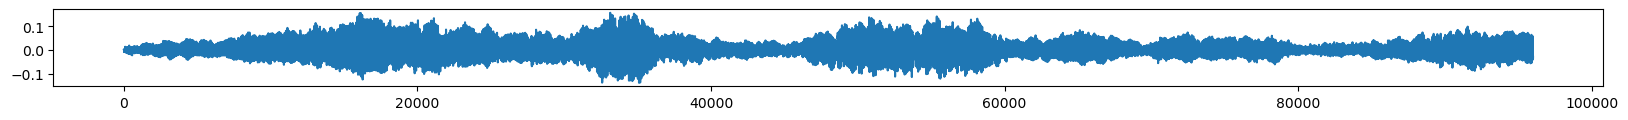

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2026-02-05 19:31:55.256056, epoch 61,  Loss: 0.2862
  Quantizer 0 Loss: 2.0744
  Quantizer 1 Loss: 2.7137
  Quantizer 2 Loss: 3.3158
  Quantizer 3 Loss: 3.7118
  Quantizer 4 Loss: 3.9856
  Quantizer 5 Loss: 4.1730
  Quantizer 6 Loss: 4.3723
  Quantizer 7 Loss: 4.4728
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


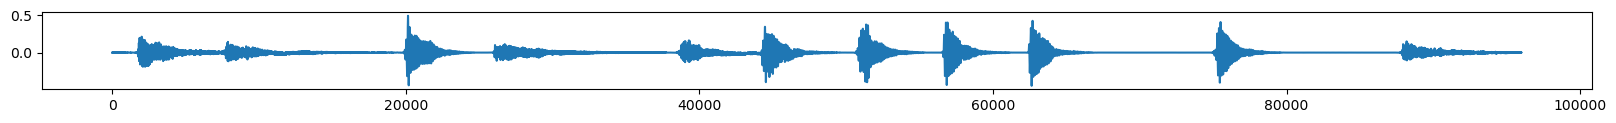

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2026-02-05 19:32:47.408111, epoch 62,  Loss: 0.2675
  Quantizer 0 Loss: 2.0606
  Quantizer 1 Loss: 2.7067
  Quantizer 2 Loss: 3.3045
  Quantizer 3 Loss: 3.7040
  Quantizer 4 Loss: 3.9750
  Quantizer 5 Loss: 4.1717
  Quantizer 6 Loss: 4.3682
  Quantizer 7 Loss: 4.4734
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


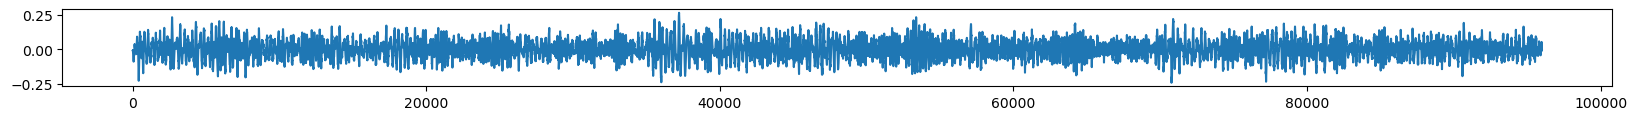

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2026-02-05 19:33:39.356510, epoch 63,  Loss: 0.2786
  Quantizer 0 Loss: 2.0661
  Quantizer 1 Loss: 2.7139
  Quantizer 2 Loss: 3.3107
  Quantizer 3 Loss: 3.7118
  Quantizer 4 Loss: 3.9888
  Quantizer 5 Loss: 4.1803
  Quantizer 6 Loss: 4.3796
  Quantizer 7 Loss: 4.4815
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


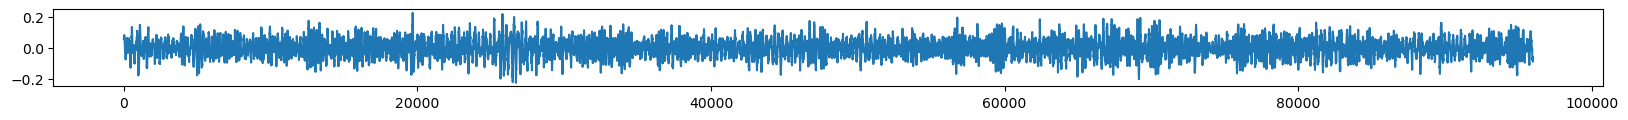

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2026-02-05 19:34:31.543562, epoch 64,  Loss: 0.2736
  Quantizer 0 Loss: 2.0731
  Quantizer 1 Loss: 2.7088
  Quantizer 2 Loss: 3.3057
  Quantizer 3 Loss: 3.7058
  Quantizer 4 Loss: 3.9817
  Quantizer 5 Loss: 4.1738
  Quantizer 6 Loss: 4.3639
  Quantizer 7 Loss: 4.4675
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


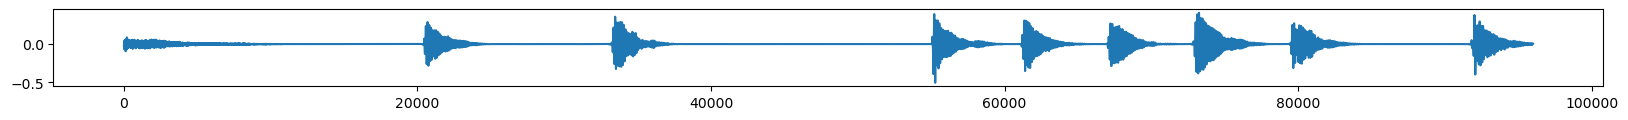

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2026-02-05 19:35:23.796315, epoch 65,  Loss: 0.2779
  Quantizer 0 Loss: 2.0692
  Quantizer 1 Loss: 2.7063
  Quantizer 2 Loss: 3.3064
  Quantizer 3 Loss: 3.7016
  Quantizer 4 Loss: 3.9771
  Quantizer 5 Loss: 4.1687
  Quantizer 6 Loss: 4.3670
  Quantizer 7 Loss: 4.4683
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


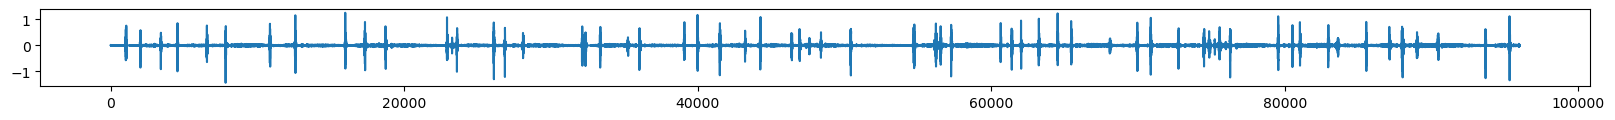

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2026-02-05 19:36:15.964926, epoch 66,  Loss: 0.2746
  Quantizer 0 Loss: 2.0627
  Quantizer 1 Loss: 2.6977
  Quantizer 2 Loss: 3.2995
  Quantizer 3 Loss: 3.6982
  Quantizer 4 Loss: 3.9756
  Quantizer 5 Loss: 4.1659
  Quantizer 6 Loss: 4.3635
  Quantizer 7 Loss: 4.4659
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


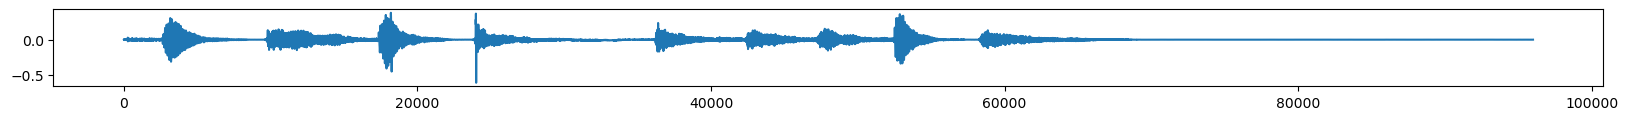

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2026-02-05 19:37:08.334588, epoch 67,  Loss: 0.2834
  Quantizer 0 Loss: 2.0711
  Quantizer 1 Loss: 2.7035
  Quantizer 2 Loss: 3.3072
  Quantizer 3 Loss: 3.7050
  Quantizer 4 Loss: 3.9820
  Quantizer 5 Loss: 4.1708
  Quantizer 6 Loss: 4.3649
  Quantizer 7 Loss: 4.4674
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


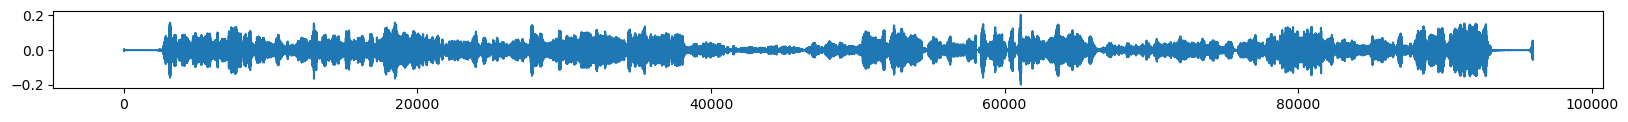

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2026-02-05 19:38:00.754475, epoch 68,  Loss: 0.2744
  Quantizer 0 Loss: 2.0745
  Quantizer 1 Loss: 2.7065
  Quantizer 2 Loss: 3.3060
  Quantizer 3 Loss: 3.7003
  Quantizer 4 Loss: 3.9766
  Quantizer 5 Loss: 4.1662
  Quantizer 6 Loss: 4.3589
  Quantizer 7 Loss: 4.4628
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


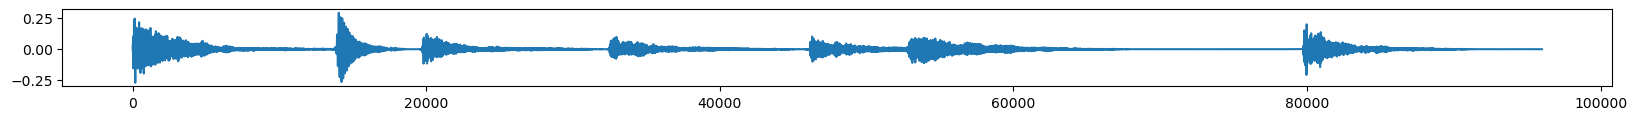

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2026-02-05 19:38:53.200227, epoch 69,  Loss: 0.2783
  Quantizer 0 Loss: 2.0601
  Quantizer 1 Loss: 2.6984
  Quantizer 2 Loss: 3.2973
  Quantizer 3 Loss: 3.6973
  Quantizer 4 Loss: 3.9706
  Quantizer 5 Loss: 4.1577
  Quantizer 6 Loss: 4.3596
  Quantizer 7 Loss: 4.4630
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


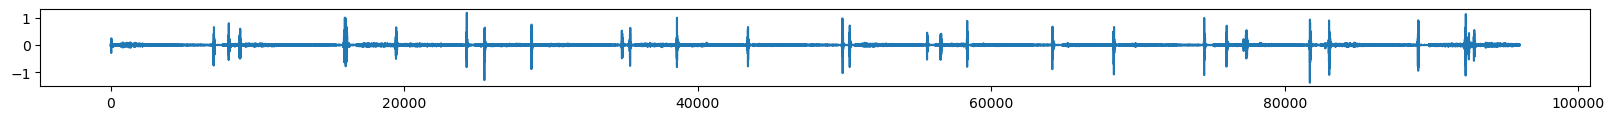

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2026-02-05 19:39:45.388450, epoch 70,  Loss: 0.2776
  Quantizer 0 Loss: 2.0613
  Quantizer 1 Loss: 2.7013
  Quantizer 2 Loss: 3.2946
  Quantizer 3 Loss: 3.6943
  Quantizer 4 Loss: 3.9724
  Quantizer 5 Loss: 4.1608
  Quantizer 6 Loss: 4.3573
  Quantizer 7 Loss: 4.4627
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


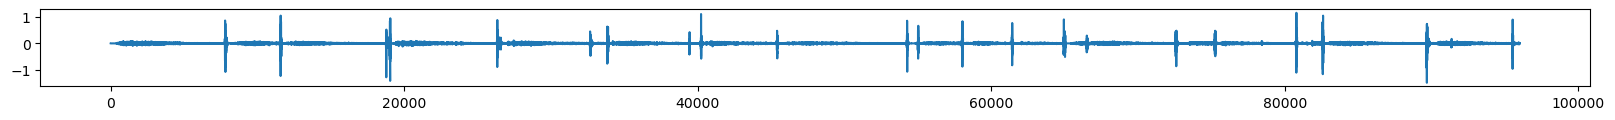

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2026-02-05 19:40:37.696612, epoch 71,  Loss: 0.2736
  Quantizer 0 Loss: 2.0591
  Quantizer 1 Loss: 2.6914
  Quantizer 2 Loss: 3.2949
  Quantizer 3 Loss: 3.6872
  Quantizer 4 Loss: 3.9709
  Quantizer 5 Loss: 4.1599
  Quantizer 6 Loss: 4.3586
  Quantizer 7 Loss: 4.4616
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


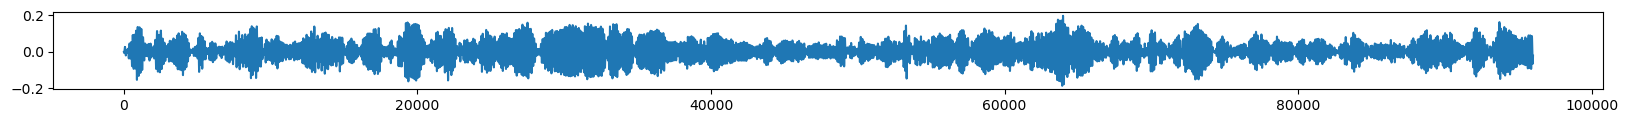

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2026-02-05 19:41:29.911563, epoch 72,  Loss: 0.2842
  Quantizer 0 Loss: 2.0635
  Quantizer 1 Loss: 2.7012
  Quantizer 2 Loss: 3.2956
  Quantizer 3 Loss: 3.6877
  Quantizer 4 Loss: 3.9636
  Quantizer 5 Loss: 4.1532
  Quantizer 6 Loss: 4.3530
  Quantizer 7 Loss: 4.4546
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


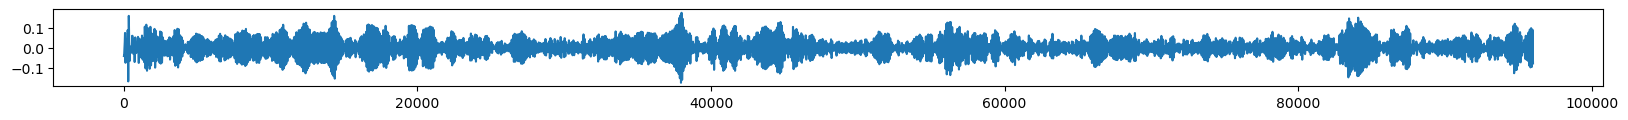

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2026-02-05 19:42:22.046723, epoch 73,  Loss: 0.2892
  Quantizer 0 Loss: 2.0579
  Quantizer 1 Loss: 2.6880
  Quantizer 2 Loss: 3.2875
  Quantizer 3 Loss: 3.6852
  Quantizer 4 Loss: 3.9600
  Quantizer 5 Loss: 4.1525
  Quantizer 6 Loss: 4.3478
  Quantizer 7 Loss: 4.4459
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


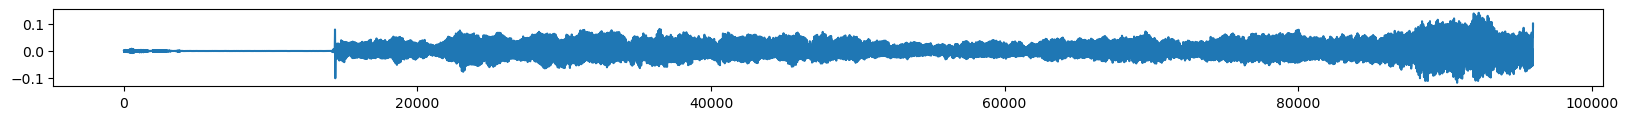

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2026-02-05 19:43:14.285844, epoch 74,  Loss: 0.2883
  Quantizer 0 Loss: 2.0574
  Quantizer 1 Loss: 2.6901
  Quantizer 2 Loss: 3.2863
  Quantizer 3 Loss: 3.6833
  Quantizer 4 Loss: 3.9681
  Quantizer 5 Loss: 4.1509
  Quantizer 6 Loss: 4.3444
  Quantizer 7 Loss: 4.4532
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


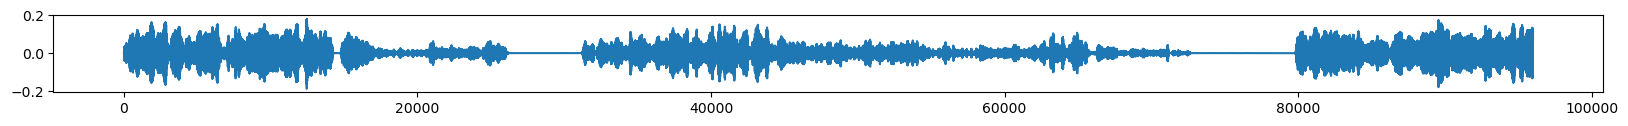

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2026-02-05 19:44:06.352214, epoch 75,  Loss: 0.2775
  Quantizer 0 Loss: 2.0495
  Quantizer 1 Loss: 2.6776
  Quantizer 2 Loss: 3.2816
  Quantizer 3 Loss: 3.6751
  Quantizer 4 Loss: 3.9486
  Quantizer 5 Loss: 4.1395
  Quantizer 6 Loss: 4.3368
  Quantizer 7 Loss: 4.4421
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


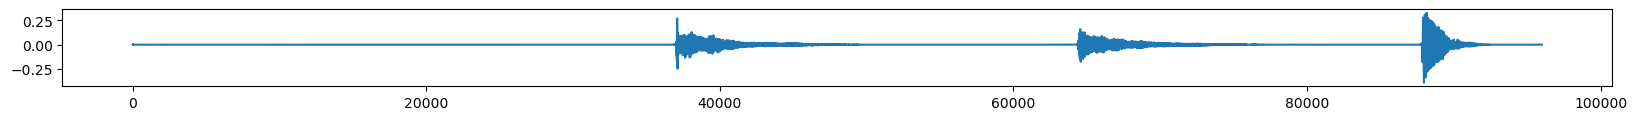

Saved checkpoint at epoch 75
Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2026-02-05 19:44:59.071531, epoch 76,  Loss: 0.3297
  Quantizer 0 Loss: 2.1270
  Quantizer 1 Loss: 3.3039
  Quantizer 2 Loss: 4.0352
  Quantizer 3 Loss: 4.4209
  Quantizer 4 Loss: 4.6701
  Quantizer 5 Loss: 4.8140
  Quantizer 6 Loss: 4.9859
  Quantizer 7 Loss: 5.0516
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


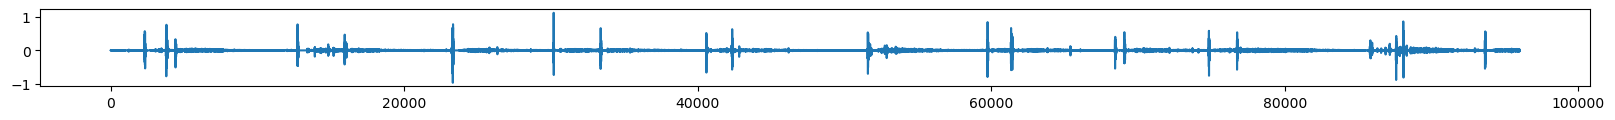

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2026-02-05 19:45:51.403091, epoch 77,  Loss: 0.3134
  Quantizer 0 Loss: 2.0964
  Quantizer 1 Loss: 3.2047
  Quantizer 2 Loss: 3.9524
  Quantizer 3 Loss: 4.3598
  Quantizer 4 Loss: 4.6196
  Quantizer 5 Loss: 4.7746
  Quantizer 6 Loss: 4.9506
  Quantizer 7 Loss: 5.0251
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


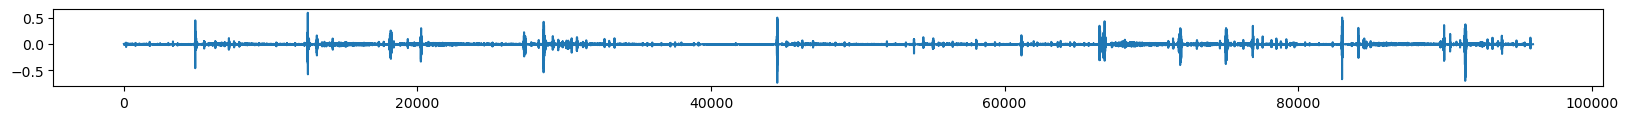

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2026-02-05 19:46:43.873669, epoch 78,  Loss: 0.3138
  Quantizer 0 Loss: 2.0882
  Quantizer 1 Loss: 3.1780
  Quantizer 2 Loss: 3.9245
  Quantizer 3 Loss: 4.3448
  Quantizer 4 Loss: 4.6066
  Quantizer 5 Loss: 4.7722
  Quantizer 6 Loss: 4.9538
  Quantizer 7 Loss: 5.0223
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


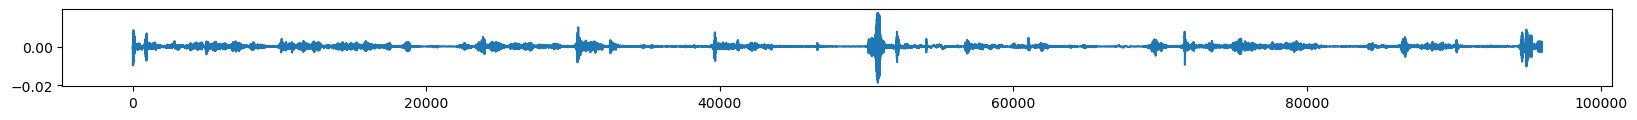

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2026-02-05 19:47:36.485593, epoch 79,  Loss: 0.3135
  Quantizer 0 Loss: 2.0886
  Quantizer 1 Loss: 3.1610
  Quantizer 2 Loss: 3.9045
  Quantizer 3 Loss: 4.3239
  Quantizer 4 Loss: 4.5935
  Quantizer 5 Loss: 4.7561
  Quantizer 6 Loss: 4.9335
  Quantizer 7 Loss: 5.0045
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


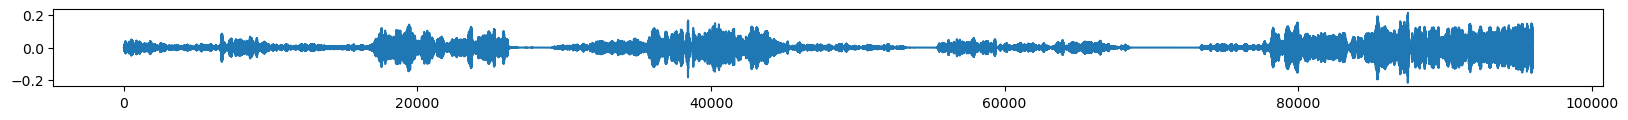

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2026-02-05 19:48:29.003096, epoch 80,  Loss: 0.3204
  Quantizer 0 Loss: 2.0937
  Quantizer 1 Loss: 3.1656
  Quantizer 2 Loss: 3.9096
  Quantizer 3 Loss: 4.3299
  Quantizer 4 Loss: 4.5950
  Quantizer 5 Loss: 4.7661
  Quantizer 6 Loss: 4.9439
  Quantizer 7 Loss: 5.0212
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


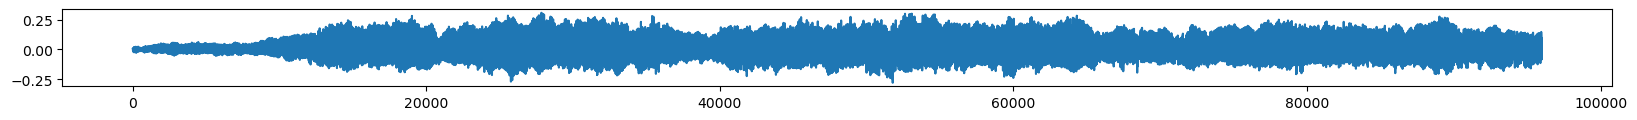

Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2026-02-05 19:49:21.341116, epoch 81,  Loss: 0.3139
  Quantizer 0 Loss: 2.0724
  Quantizer 1 Loss: 3.1335
  Quantizer 2 Loss: 3.8741
  Quantizer 3 Loss: 4.2908
  Quantizer 4 Loss: 4.5649
  Quantizer 5 Loss: 4.7288
  Quantizer 6 Loss: 4.9165
  Quantizer 7 Loss: 4.9890
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


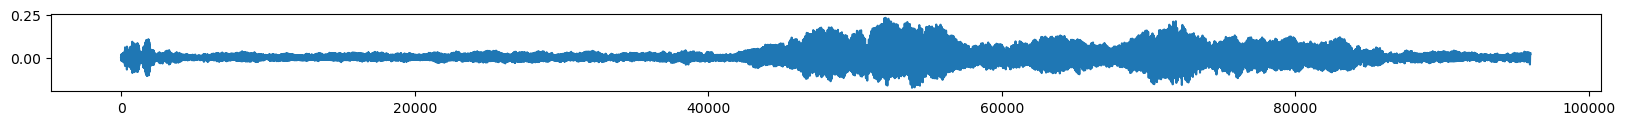

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2026-02-05 19:50:13.777567, epoch 82,  Loss: 0.3101
  Quantizer 0 Loss: 2.0700
  Quantizer 1 Loss: 3.1235
  Quantizer 2 Loss: 3.8764
  Quantizer 3 Loss: 4.2934
  Quantizer 4 Loss: 4.5680
  Quantizer 5 Loss: 4.7317
  Quantizer 6 Loss: 4.9121
  Quantizer 7 Loss: 4.9921
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


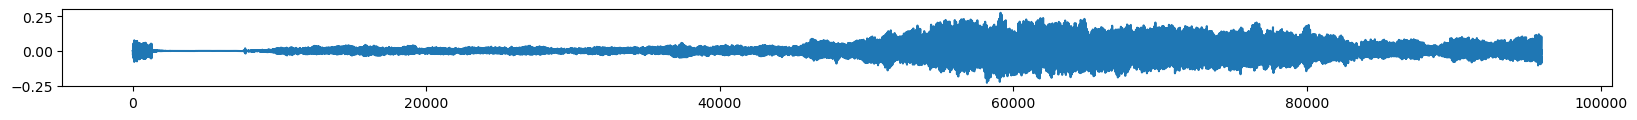

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2026-02-05 19:51:06.515727, epoch 83,  Loss: 0.3224
  Quantizer 0 Loss: 2.0768
  Quantizer 1 Loss: 3.1271
  Quantizer 2 Loss: 3.8732
  Quantizer 3 Loss: 4.2927
  Quantizer 4 Loss: 4.5663
  Quantizer 5 Loss: 4.7326
  Quantizer 6 Loss: 4.9113
  Quantizer 7 Loss: 4.9919
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


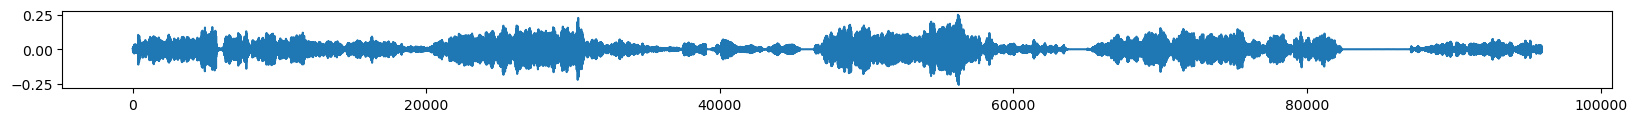

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2026-02-05 19:51:59.002485, epoch 84,  Loss: 0.3165
  Quantizer 0 Loss: 2.0795
  Quantizer 1 Loss: 3.1318
  Quantizer 2 Loss: 3.8757
  Quantizer 3 Loss: 4.2926
  Quantizer 4 Loss: 4.5659
  Quantizer 5 Loss: 4.7321
  Quantizer 6 Loss: 4.9180
  Quantizer 7 Loss: 4.9951
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


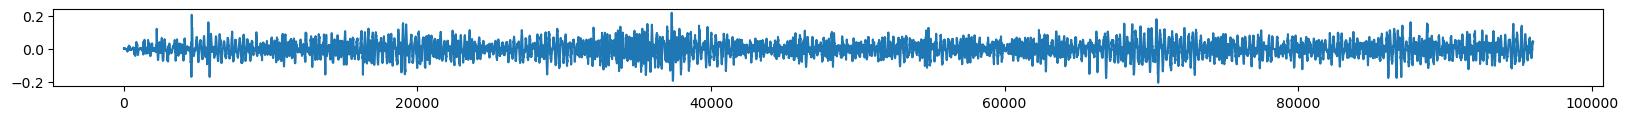

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2026-02-05 19:52:51.505295, epoch 85,  Loss: 0.3202
  Quantizer 0 Loss: 2.0792
  Quantizer 1 Loss: 3.1301
  Quantizer 2 Loss: 3.8776
  Quantizer 3 Loss: 4.2994
  Quantizer 4 Loss: 4.5668
  Quantizer 5 Loss: 4.7313
  Quantizer 6 Loss: 4.9144
  Quantizer 7 Loss: 4.9951
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


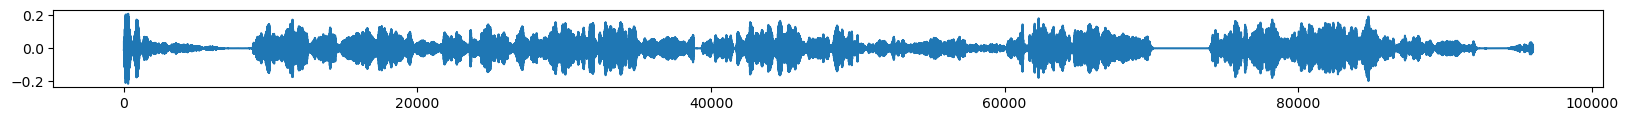

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2026-02-05 19:53:43.946543, epoch 86,  Loss: 0.3117
  Quantizer 0 Loss: 2.0733
  Quantizer 1 Loss: 3.1218
  Quantizer 2 Loss: 3.8637
  Quantizer 3 Loss: 4.2797
  Quantizer 4 Loss: 4.5540
  Quantizer 5 Loss: 4.7205
  Quantizer 6 Loss: 4.9045
  Quantizer 7 Loss: 4.9830
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


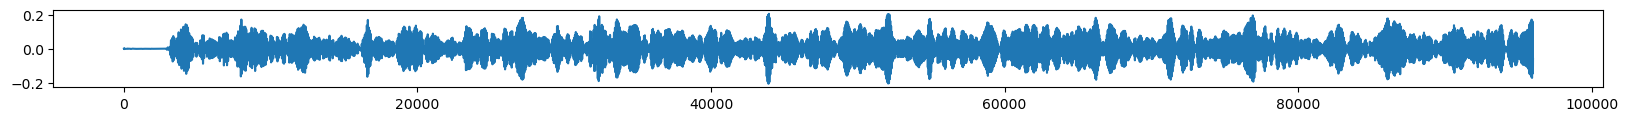

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2026-02-05 19:54:36.253729, epoch 87,  Loss: 0.3181
  Quantizer 0 Loss: 2.0831
  Quantizer 1 Loss: 3.1344
  Quantizer 2 Loss: 3.8725
  Quantizer 3 Loss: 4.2906
  Quantizer 4 Loss: 4.5660
  Quantizer 5 Loss: 4.7356
  Quantizer 6 Loss: 4.9188
  Quantizer 7 Loss: 4.9942
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


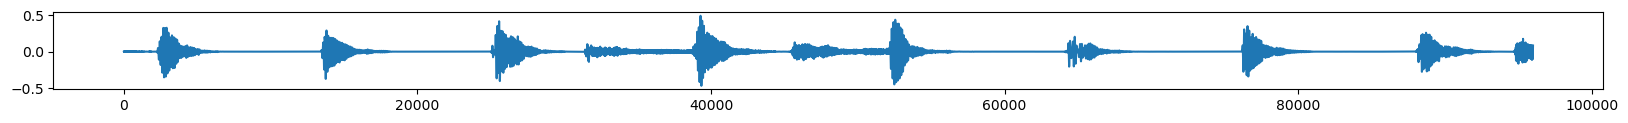

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2026-02-05 19:55:28.525264, epoch 88,  Loss: 0.3124
  Quantizer 0 Loss: 2.0578
  Quantizer 1 Loss: 3.1122
  Quantizer 2 Loss: 3.8512
  Quantizer 3 Loss: 4.2772
  Quantizer 4 Loss: 4.5496
  Quantizer 5 Loss: 4.7185
  Quantizer 6 Loss: 4.9057
  Quantizer 7 Loss: 4.9829
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


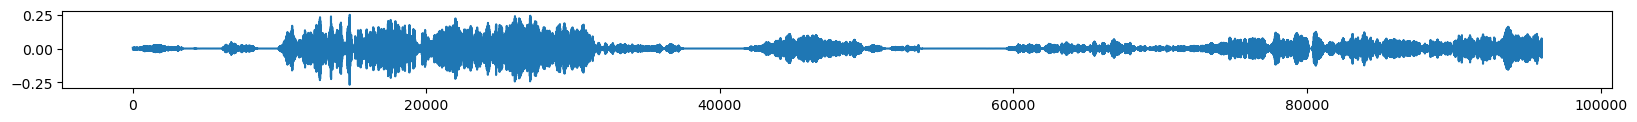

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2026-02-05 19:56:21.287352, epoch 89,  Loss: 0.3121
  Quantizer 0 Loss: 2.0640
  Quantizer 1 Loss: 3.1156
  Quantizer 2 Loss: 3.8578
  Quantizer 3 Loss: 4.2784
  Quantizer 4 Loss: 4.5580
  Quantizer 5 Loss: 4.7250
  Quantizer 6 Loss: 4.9105
  Quantizer 7 Loss: 4.9890
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


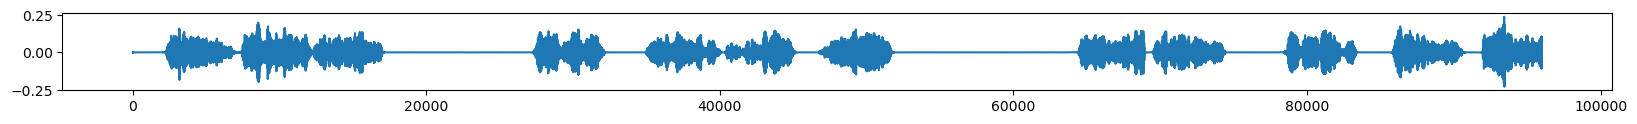

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2026-02-05 19:57:13.935646, epoch 90,  Loss: 0.3134
  Quantizer 0 Loss: 2.0605
  Quantizer 1 Loss: 3.0902
  Quantizer 2 Loss: 3.8302
  Quantizer 3 Loss: 4.2508
  Quantizer 4 Loss: 4.5238
  Quantizer 5 Loss: 4.6927
  Quantizer 6 Loss: 4.8731
  Quantizer 7 Loss: 4.9478
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


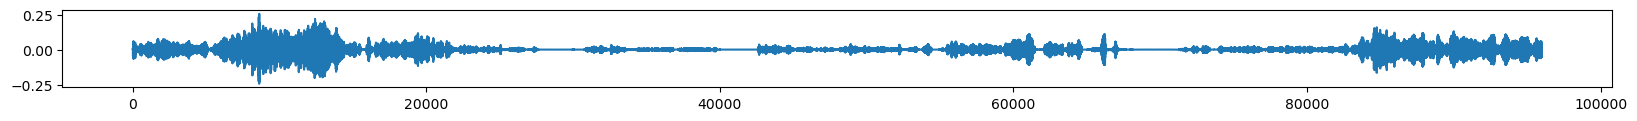

Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2026-02-05 19:58:06.625309, epoch 91,  Loss: 0.3154
  Quantizer 0 Loss: 2.0596
  Quantizer 1 Loss: 3.1052
  Quantizer 2 Loss: 3.8465
  Quantizer 3 Loss: 4.2630
  Quantizer 4 Loss: 4.5376
  Quantizer 5 Loss: 4.7082
  Quantizer 6 Loss: 4.8908
  Quantizer 7 Loss: 4.9718
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


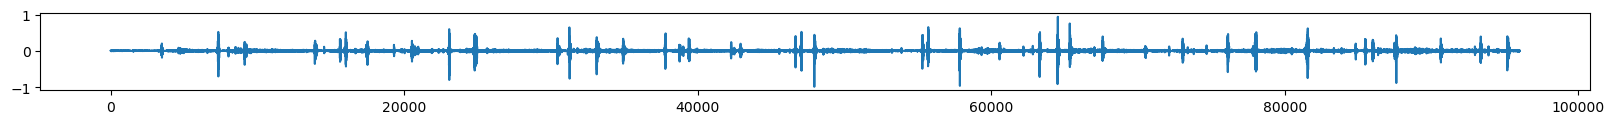

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2026-02-05 19:58:59.266506, epoch 92,  Loss: 0.3186
  Quantizer 0 Loss: 2.0537
  Quantizer 1 Loss: 3.0941
  Quantizer 2 Loss: 3.8327
  Quantizer 3 Loss: 4.2544
  Quantizer 4 Loss: 4.5267
  Quantizer 5 Loss: 4.6979
  Quantizer 6 Loss: 4.8799
  Quantizer 7 Loss: 4.9581
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


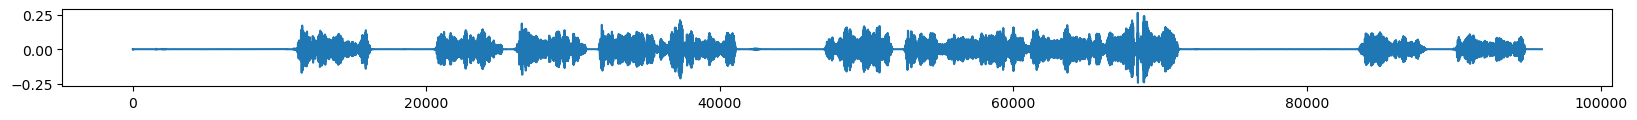

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2026-02-05 19:59:51.931497, epoch 93,  Loss: 0.3205
  Quantizer 0 Loss: 2.0591
  Quantizer 1 Loss: 3.1003
  Quantizer 2 Loss: 3.8355
  Quantizer 3 Loss: 4.2581
  Quantizer 4 Loss: 4.5346
  Quantizer 5 Loss: 4.7068
  Quantizer 6 Loss: 4.8884
  Quantizer 7 Loss: 4.9657
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


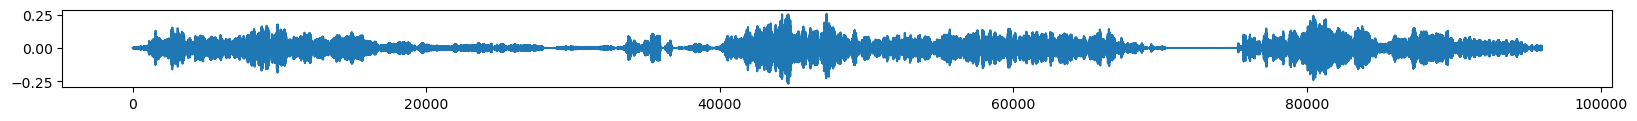

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2026-02-05 20:00:44.507752, epoch 94,  Loss: 0.3193
  Quantizer 0 Loss: 2.0682
  Quantizer 1 Loss: 3.1133
  Quantizer 2 Loss: 3.8495
  Quantizer 3 Loss: 4.2690
  Quantizer 4 Loss: 4.5342
  Quantizer 5 Loss: 4.7029
  Quantizer 6 Loss: 4.8859
  Quantizer 7 Loss: 4.9655
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


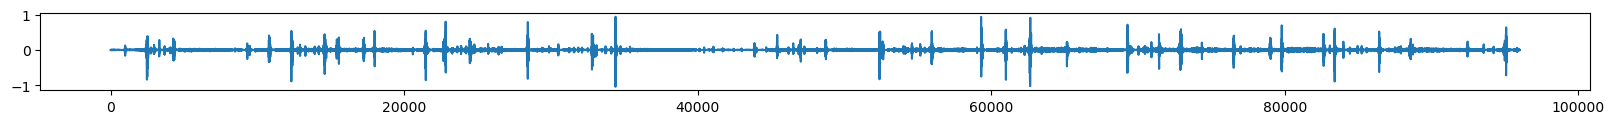

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2026-02-05 20:01:36.839272, epoch 95,  Loss: 0.3148
  Quantizer 0 Loss: 2.0596
  Quantizer 1 Loss: 3.0974
  Quantizer 2 Loss: 3.8292
  Quantizer 3 Loss: 4.2584
  Quantizer 4 Loss: 4.5318
  Quantizer 5 Loss: 4.7031
  Quantizer 6 Loss: 4.8853
  Quantizer 7 Loss: 4.9690
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


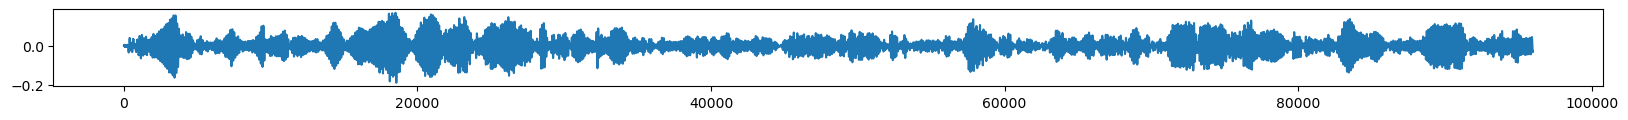

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2026-02-05 20:02:29.359220, epoch 96,  Loss: 0.3038
  Quantizer 0 Loss: 2.0630
  Quantizer 1 Loss: 3.1027
  Quantizer 2 Loss: 3.8370
  Quantizer 3 Loss: 4.2601
  Quantizer 4 Loss: 4.5347
  Quantizer 5 Loss: 4.7091
  Quantizer 6 Loss: 4.8858
  Quantizer 7 Loss: 4.9632
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


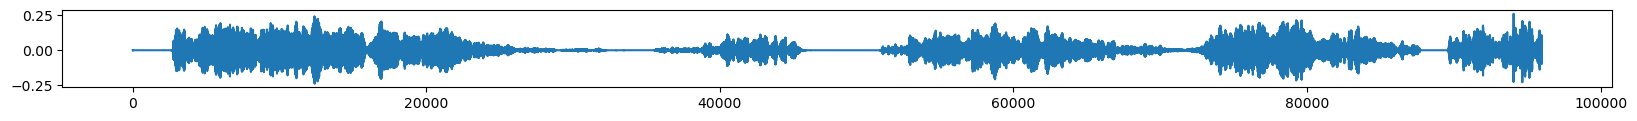

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2026-02-05 20:03:21.852489, epoch 97,  Loss: 0.3131
  Quantizer 0 Loss: 2.0542
  Quantizer 1 Loss: 3.0873
  Quantizer 2 Loss: 3.8251
  Quantizer 3 Loss: 4.2474
  Quantizer 4 Loss: 4.5188
  Quantizer 5 Loss: 4.6875
  Quantizer 6 Loss: 4.8734
  Quantizer 7 Loss: 4.9564
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


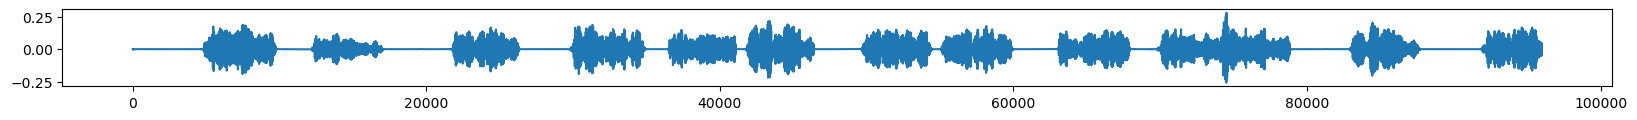

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2026-02-05 20:04:14.262516, epoch 98,  Loss: 0.3145
  Quantizer 0 Loss: 2.0631
  Quantizer 1 Loss: 3.1067
  Quantizer 2 Loss: 3.8463
  Quantizer 3 Loss: 4.2632
  Quantizer 4 Loss: 4.5406
  Quantizer 5 Loss: 4.7080
  Quantizer 6 Loss: 4.8898
  Quantizer 7 Loss: 4.9729
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


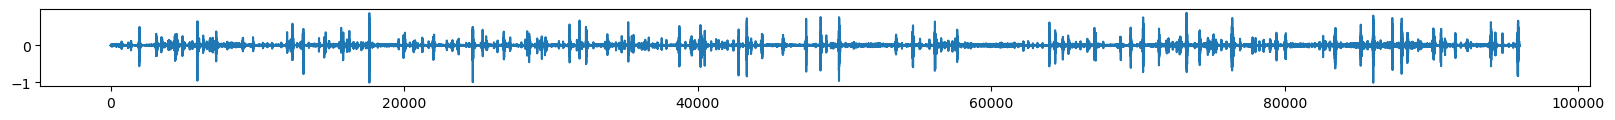

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2026-02-05 20:05:06.702547, epoch 99,  Loss: 0.3176
  Quantizer 0 Loss: 2.0557
  Quantizer 1 Loss: 3.0910
  Quantizer 2 Loss: 3.8322
  Quantizer 3 Loss: 4.2558
  Quantizer 4 Loss: 4.5290
  Quantizer 5 Loss: 4.6996
  Quantizer 6 Loss: 4.8806
  Quantizer 7 Loss: 4.9643
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


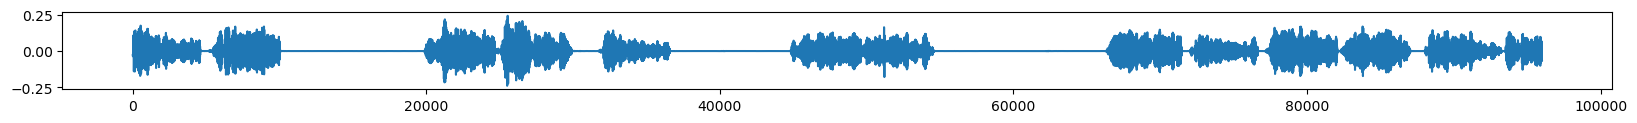

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2026-02-05 20:05:59.051997, epoch 100,  Loss: 0.3199
  Quantizer 0 Loss: 2.0552
  Quantizer 1 Loss: 3.0928
  Quantizer 2 Loss: 3.8278
  Quantizer 3 Loss: 4.2465
  Quantizer 4 Loss: 4.5203
  Quantizer 5 Loss: 4.6966
  Quantizer 6 Loss: 4.8786
  Quantizer 7 Loss: 4.9606
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


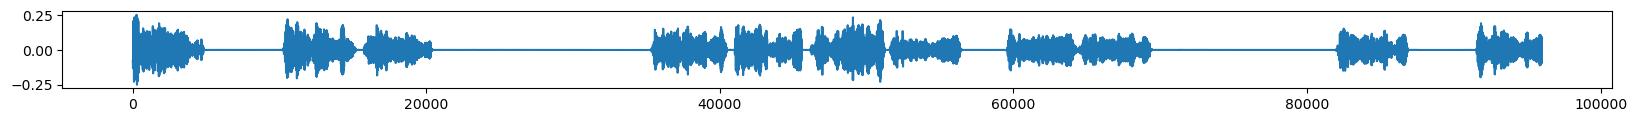

Saved checkpoint at epoch 100
Finished epoch number 100 with a total of 10000 debug_seqs
 time: 2026-02-05 20:06:51.487365, epoch 101,  Loss: 0.2802
  Quantizer 0 Loss: 2.0360
  Quantizer 1 Loss: 2.7419
  Quantizer 2 Loss: 3.3941
  Quantizer 3 Loss: 3.8215
  Quantizer 4 Loss: 4.1098
  Quantizer 5 Loss: 4.3061
  Quantizer 6 Loss: 4.5093
  Quantizer 7 Loss: 4.6096
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


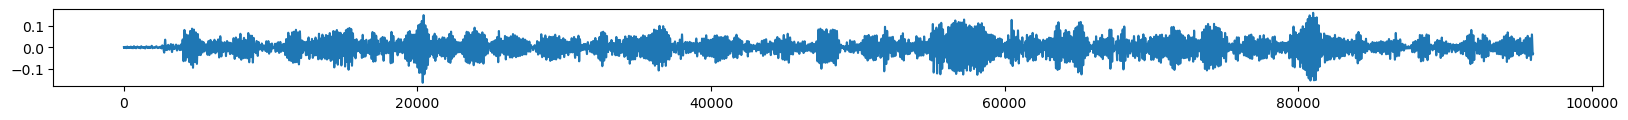

Finished epoch number 101 with a total of 10000 debug_seqs
 time: 2026-02-05 20:07:43.648325, epoch 102,  Loss: 0.2797
  Quantizer 0 Loss: 2.0478
  Quantizer 1 Loss: 2.7081
  Quantizer 2 Loss: 3.3348
  Quantizer 3 Loss: 3.7454
  Quantizer 4 Loss: 4.0302
  Quantizer 5 Loss: 4.2257
  Quantizer 6 Loss: 4.4268
  Quantizer 7 Loss: 4.5321
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


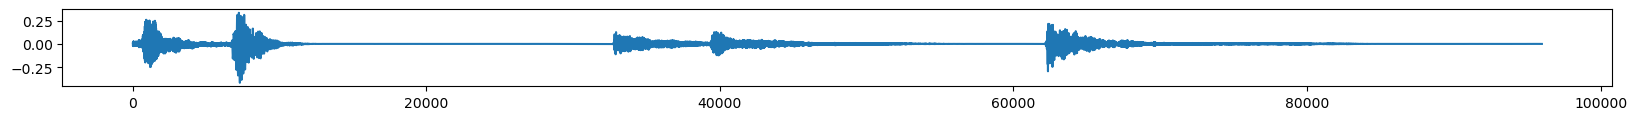

Finished epoch number 102 with a total of 10000 debug_seqs
 time: 2026-02-05 20:08:35.697897, epoch 103,  Loss: 0.2777
  Quantizer 0 Loss: 2.0565
  Quantizer 1 Loss: 2.7017
  Quantizer 2 Loss: 3.3139
  Quantizer 3 Loss: 3.7156
  Quantizer 4 Loss: 3.9985
  Quantizer 5 Loss: 4.1899
  Quantizer 6 Loss: 4.3888
  Quantizer 7 Loss: 4.4946
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


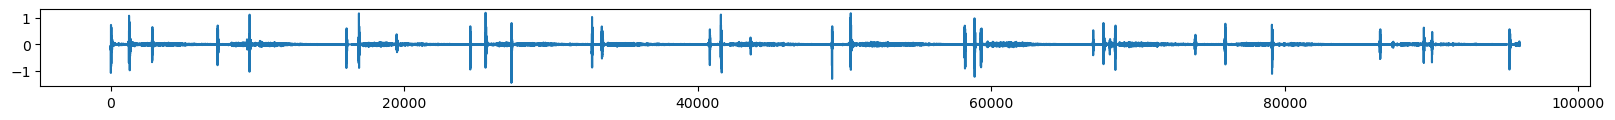

Finished epoch number 103 with a total of 10000 debug_seqs
 time: 2026-02-05 20:09:28.141067, epoch 104,  Loss: 0.2640
  Quantizer 0 Loss: 2.0495
  Quantizer 1 Loss: 2.7033
  Quantizer 2 Loss: 3.3082
  Quantizer 3 Loss: 3.7153
  Quantizer 4 Loss: 3.9924
  Quantizer 5 Loss: 4.1859
  Quantizer 6 Loss: 4.3871
  Quantizer 7 Loss: 4.4917
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


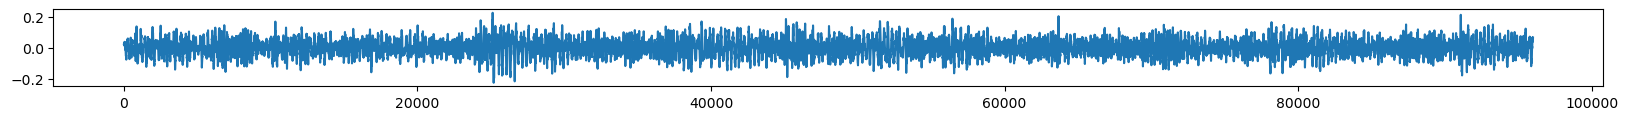

Finished epoch number 104 with a total of 10000 debug_seqs
 time: 2026-02-05 20:10:20.532387, epoch 105,  Loss: 0.2795
  Quantizer 0 Loss: 2.0455
  Quantizer 1 Loss: 2.6849
  Quantizer 2 Loss: 3.2916
  Quantizer 3 Loss: 3.6933
  Quantizer 4 Loss: 3.9744
  Quantizer 5 Loss: 4.1666
  Quantizer 6 Loss: 4.3618
  Quantizer 7 Loss: 4.4650
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


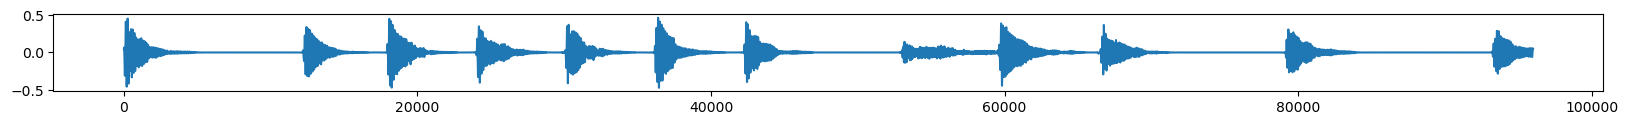

Finished epoch number 105 with a total of 10000 debug_seqs
 time: 2026-02-05 20:11:12.829758, epoch 106,  Loss: 0.2823
  Quantizer 0 Loss: 2.0426
  Quantizer 1 Loss: 2.6834
  Quantizer 2 Loss: 3.2910
  Quantizer 3 Loss: 3.6909
  Quantizer 4 Loss: 3.9681
  Quantizer 5 Loss: 4.1585
  Quantizer 6 Loss: 4.3611
  Quantizer 7 Loss: 4.4598
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


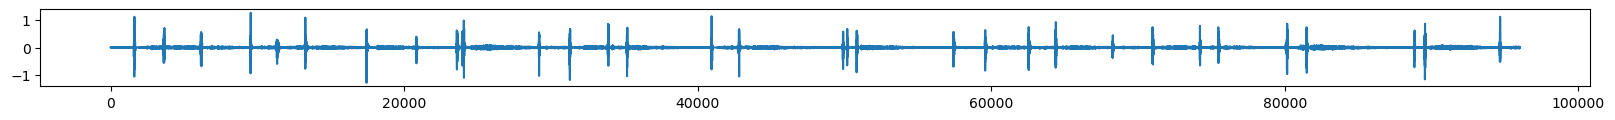

Finished epoch number 106 with a total of 10000 debug_seqs
 time: 2026-02-05 20:12:05.052677, epoch 107,  Loss: 0.2768
  Quantizer 0 Loss: 2.0434
  Quantizer 1 Loss: 2.6862
  Quantizer 2 Loss: 3.2852
  Quantizer 3 Loss: 3.6892
  Quantizer 4 Loss: 3.9673
  Quantizer 5 Loss: 4.1545
  Quantizer 6 Loss: 4.3520
  Quantizer 7 Loss: 4.4585
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


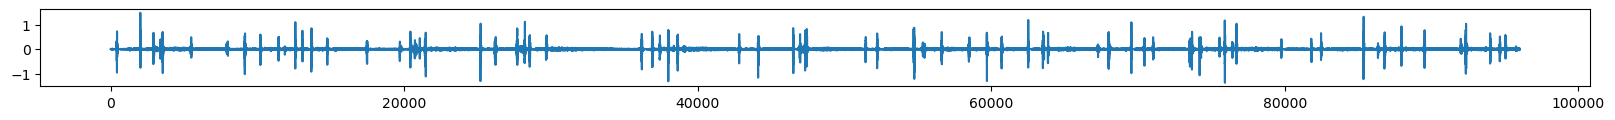

Finished epoch number 107 with a total of 10000 debug_seqs
 time: 2026-02-05 20:12:57.114621, epoch 108,  Loss: 0.2788
  Quantizer 0 Loss: 2.0411
  Quantizer 1 Loss: 2.6769
  Quantizer 2 Loss: 3.2745
  Quantizer 3 Loss: 3.6803
  Quantizer 4 Loss: 3.9569
  Quantizer 5 Loss: 4.1501
  Quantizer 6 Loss: 4.3473
  Quantizer 7 Loss: 4.4491
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


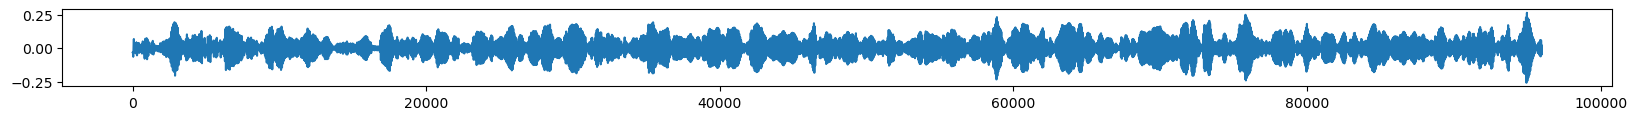

Finished epoch number 108 with a total of 10000 debug_seqs
 time: 2026-02-05 20:13:49.117474, epoch 109,  Loss: 0.2770
  Quantizer 0 Loss: 2.0459
  Quantizer 1 Loss: 2.6831
  Quantizer 2 Loss: 3.2856
  Quantizer 3 Loss: 3.6874
  Quantizer 4 Loss: 3.9608
  Quantizer 5 Loss: 4.1559
  Quantizer 6 Loss: 4.3530
  Quantizer 7 Loss: 4.4539
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


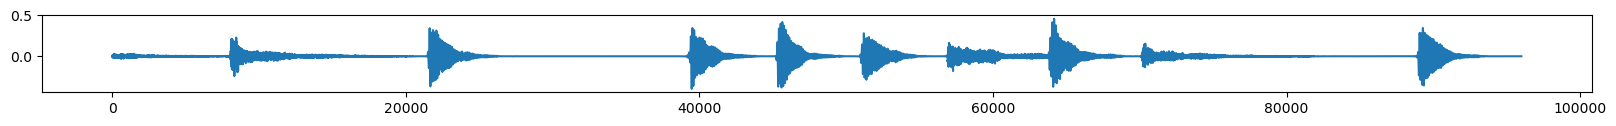

Finished epoch number 109 with a total of 10000 debug_seqs
 time: 2026-02-05 20:14:41.489800, epoch 110,  Loss: 0.2751
  Quantizer 0 Loss: 2.0523
  Quantizer 1 Loss: 2.6930
  Quantizer 2 Loss: 3.2954
  Quantizer 3 Loss: 3.6905
  Quantizer 4 Loss: 3.9685
  Quantizer 5 Loss: 4.1544
  Quantizer 6 Loss: 4.3542
  Quantizer 7 Loss: 4.4550
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


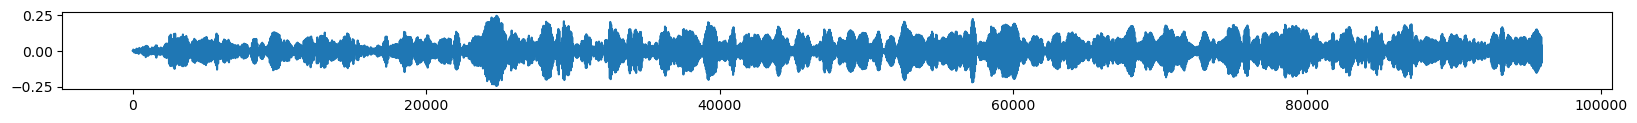

Finished epoch number 110 with a total of 10000 debug_seqs
 time: 2026-02-05 20:15:33.582489, epoch 111,  Loss: 0.2792
  Quantizer 0 Loss: 2.0436
  Quantizer 1 Loss: 2.6775
  Quantizer 2 Loss: 3.2794
  Quantizer 3 Loss: 3.6797
  Quantizer 4 Loss: 3.9565
  Quantizer 5 Loss: 4.1504
  Quantizer 6 Loss: 4.3501
  Quantizer 7 Loss: 4.4536
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


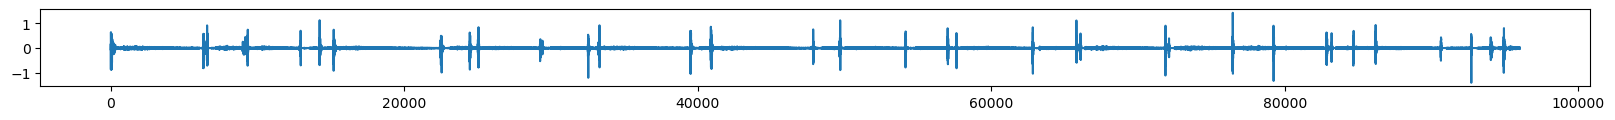

Finished epoch number 111 with a total of 10000 debug_seqs
 time: 2026-02-05 20:16:25.685542, epoch 112,  Loss: 0.2741
  Quantizer 0 Loss: 2.0432
  Quantizer 1 Loss: 2.6723
  Quantizer 2 Loss: 3.2754
  Quantizer 3 Loss: 3.6748
  Quantizer 4 Loss: 3.9536
  Quantizer 5 Loss: 4.1385
  Quantizer 6 Loss: 4.3405
  Quantizer 7 Loss: 4.4420
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


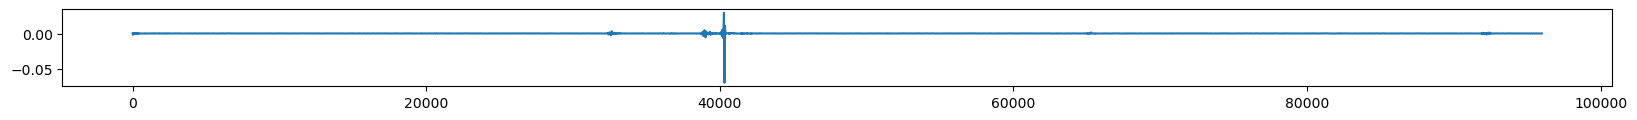

Finished epoch number 112 with a total of 10000 debug_seqs
 time: 2026-02-05 20:17:17.986681, epoch 113,  Loss: 0.2699
  Quantizer 0 Loss: 2.0433
  Quantizer 1 Loss: 2.6764
  Quantizer 2 Loss: 3.2745
  Quantizer 3 Loss: 3.6795
  Quantizer 4 Loss: 3.9585
  Quantizer 5 Loss: 4.1473
  Quantizer 6 Loss: 4.3465
  Quantizer 7 Loss: 4.4476
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


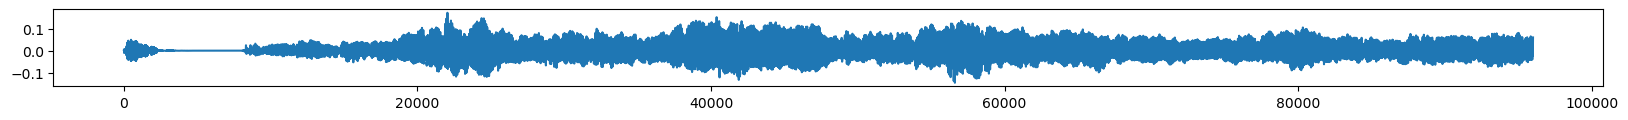

Finished epoch number 113 with a total of 10000 debug_seqs
 time: 2026-02-05 20:18:10.414433, epoch 114,  Loss: 0.2740
  Quantizer 0 Loss: 2.0465
  Quantizer 1 Loss: 2.6762
  Quantizer 2 Loss: 3.2775
  Quantizer 3 Loss: 3.6737
  Quantizer 4 Loss: 3.9518
  Quantizer 5 Loss: 4.1497
  Quantizer 6 Loss: 4.3420
  Quantizer 7 Loss: 4.4516
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


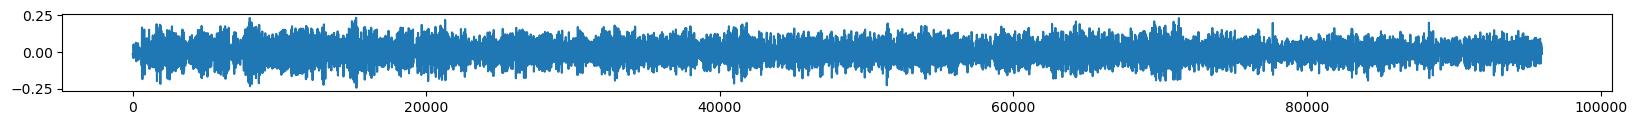

Finished epoch number 114 with a total of 10000 debug_seqs
 time: 2026-02-05 20:19:02.505874, epoch 115,  Loss: 0.2808
  Quantizer 0 Loss: 2.0353
  Quantizer 1 Loss: 2.6637
  Quantizer 2 Loss: 3.2608
  Quantizer 3 Loss: 3.6589
  Quantizer 4 Loss: 3.9337
  Quantizer 5 Loss: 4.1300
  Quantizer 6 Loss: 4.3258
  Quantizer 7 Loss: 4.4296
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


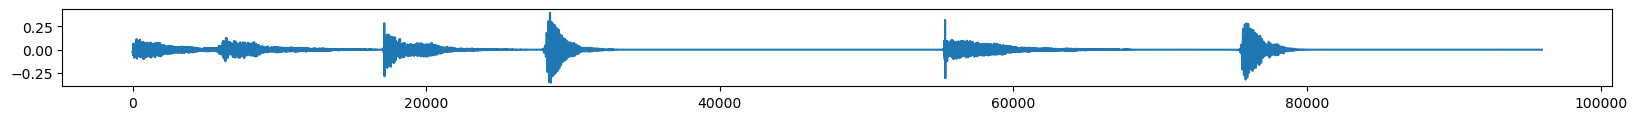

Finished epoch number 115 with a total of 10000 debug_seqs
 time: 2026-02-05 20:19:54.757910, epoch 116,  Loss: 0.2736
  Quantizer 0 Loss: 2.0465
  Quantizer 1 Loss: 2.6772
  Quantizer 2 Loss: 3.2781
  Quantizer 3 Loss: 3.6734
  Quantizer 4 Loss: 3.9523
  Quantizer 5 Loss: 4.1460
  Quantizer 6 Loss: 4.3467
  Quantizer 7 Loss: 4.4484
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


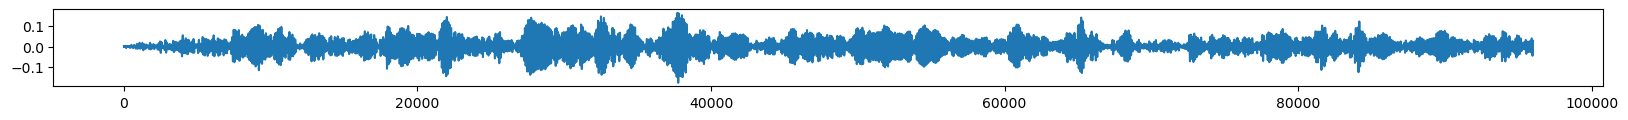

Finished epoch number 116 with a total of 10000 debug_seqs
 time: 2026-02-05 20:20:47.065003, epoch 117,  Loss: 0.2706
  Quantizer 0 Loss: 2.0490
  Quantizer 1 Loss: 2.6829
  Quantizer 2 Loss: 3.2780
  Quantizer 3 Loss: 3.6784
  Quantizer 4 Loss: 3.9606
  Quantizer 5 Loss: 4.1472
  Quantizer 6 Loss: 4.3450
  Quantizer 7 Loss: 4.4482
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


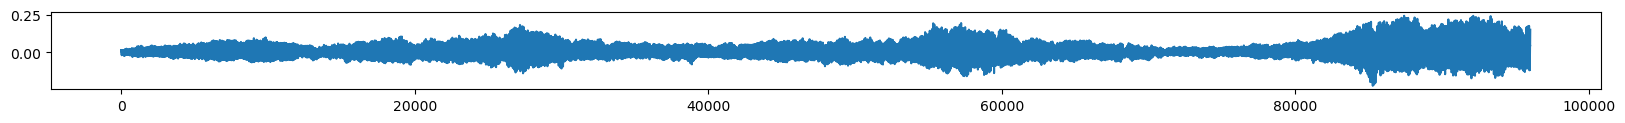

Finished epoch number 117 with a total of 10000 debug_seqs
 time: 2026-02-05 20:21:39.342592, epoch 118,  Loss: 0.2785
  Quantizer 0 Loss: 2.0422
  Quantizer 1 Loss: 2.6759
  Quantizer 2 Loss: 3.2736
  Quantizer 3 Loss: 3.6677
  Quantizer 4 Loss: 3.9516
  Quantizer 5 Loss: 4.1392
  Quantizer 6 Loss: 4.3379
  Quantizer 7 Loss: 4.4468
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


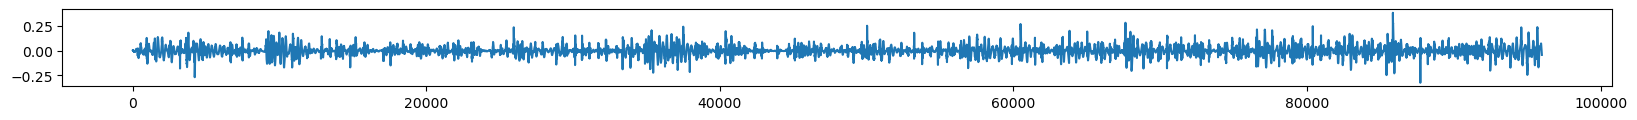

Finished epoch number 118 with a total of 10000 debug_seqs
 time: 2026-02-05 20:22:31.955368, epoch 119,  Loss: 0.2680
  Quantizer 0 Loss: 2.0344
  Quantizer 1 Loss: 2.6656
  Quantizer 2 Loss: 3.2631
  Quantizer 3 Loss: 3.6584
  Quantizer 4 Loss: 3.9297
  Quantizer 5 Loss: 4.1246
  Quantizer 6 Loss: 4.3192
  Quantizer 7 Loss: 4.4241
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


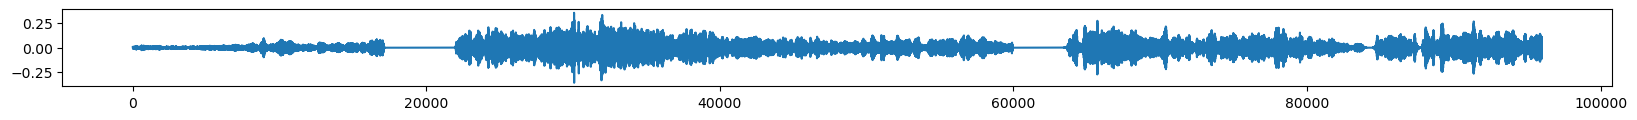

Finished epoch number 119 with a total of 10000 debug_seqs
 time: 2026-02-05 20:23:24.109412, epoch 120,  Loss: 0.2812
  Quantizer 0 Loss: 2.0469
  Quantizer 1 Loss: 2.6803
  Quantizer 2 Loss: 3.2795
  Quantizer 3 Loss: 3.6807
  Quantizer 4 Loss: 3.9593
  Quantizer 5 Loss: 4.1486
  Quantizer 6 Loss: 4.3496
  Quantizer 7 Loss: 4.4499
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


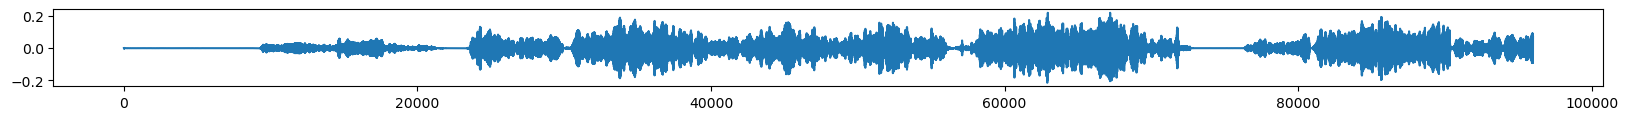

Finished epoch number 120 with a total of 10000 debug_seqs
 time: 2026-02-05 20:24:16.371208, epoch 121,  Loss: 0.2788
  Quantizer 0 Loss: 2.0401
  Quantizer 1 Loss: 2.6634
  Quantizer 2 Loss: 3.2633
  Quantizer 3 Loss: 3.6565
  Quantizer 4 Loss: 3.9348
  Quantizer 5 Loss: 4.1263
  Quantizer 6 Loss: 4.3257
  Quantizer 7 Loss: 4.4256
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


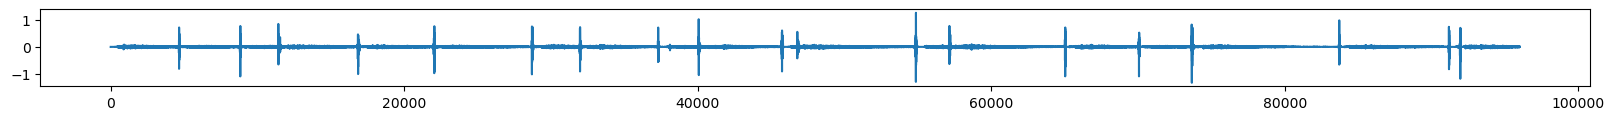

Finished epoch number 121 with a total of 10000 debug_seqs
 time: 2026-02-05 20:25:08.582678, epoch 122,  Loss: 0.2803
  Quantizer 0 Loss: 2.0362
  Quantizer 1 Loss: 2.6634
  Quantizer 2 Loss: 3.2604
  Quantizer 3 Loss: 3.6626
  Quantizer 4 Loss: 3.9406
  Quantizer 5 Loss: 4.1328
  Quantizer 6 Loss: 4.3274
  Quantizer 7 Loss: 4.4316
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


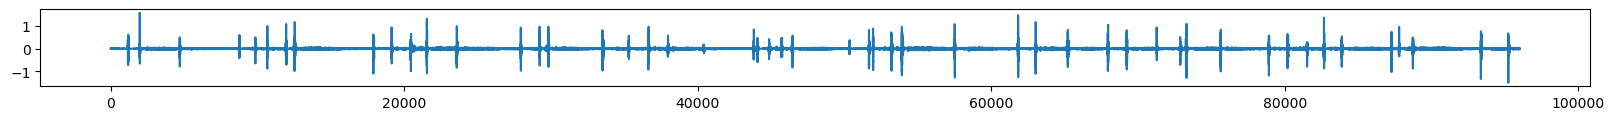

Finished epoch number 122 with a total of 10000 debug_seqs
 time: 2026-02-05 20:26:00.839444, epoch 123,  Loss: 0.2751
  Quantizer 0 Loss: 2.0373
  Quantizer 1 Loss: 2.6612
  Quantizer 2 Loss: 3.2639
  Quantizer 3 Loss: 3.6632
  Quantizer 4 Loss: 3.9410
  Quantizer 5 Loss: 4.1332
  Quantizer 6 Loss: 4.3350
  Quantizer 7 Loss: 4.4396
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


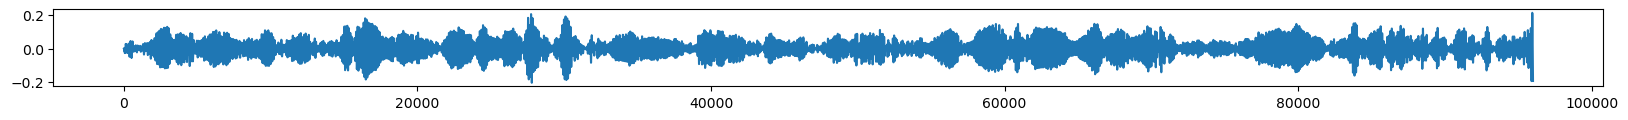

Finished epoch number 123 with a total of 10000 debug_seqs
 time: 2026-02-05 20:26:52.953445, epoch 124,  Loss: 0.2791
  Quantizer 0 Loss: 2.0512
  Quantizer 1 Loss: 2.6659
  Quantizer 2 Loss: 3.2686
  Quantizer 3 Loss: 3.6651
  Quantizer 4 Loss: 3.9383
  Quantizer 5 Loss: 4.1316
  Quantizer 6 Loss: 4.3258
  Quantizer 7 Loss: 4.4357
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


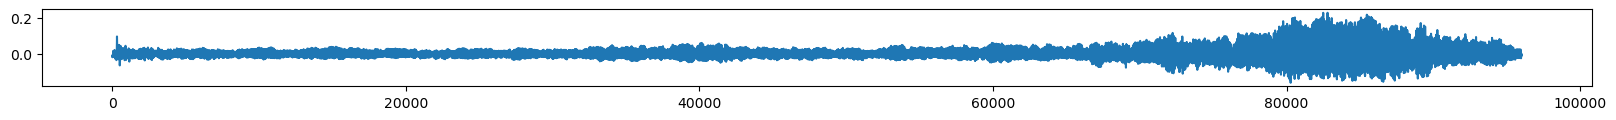

Finished epoch number 124 with a total of 10000 debug_seqs
 time: 2026-02-05 20:27:45.475140, epoch 125,  Loss: 0.2832
  Quantizer 0 Loss: 2.0397
  Quantizer 1 Loss: 2.6686
  Quantizer 2 Loss: 3.2661
  Quantizer 3 Loss: 3.6608
  Quantizer 4 Loss: 3.9368
  Quantizer 5 Loss: 4.1265
  Quantizer 6 Loss: 4.3255
  Quantizer 7 Loss: 4.4297
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


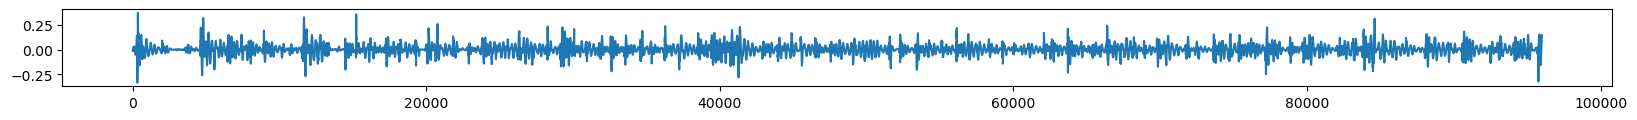

Saved checkpoint at epoch 125
Finished epoch number 125 with a total of 10000 debug_seqs
 time: 2026-02-05 20:28:37.792589, epoch 126,  Loss: 0.3100
  Quantizer 0 Loss: 2.1009
  Quantizer 1 Loss: 3.2820
  Quantizer 2 Loss: 4.0137
  Quantizer 3 Loss: 4.4034
  Quantizer 4 Loss: 4.6512
  Quantizer 5 Loss: 4.7964
  Quantizer 6 Loss: 4.9663
  Quantizer 7 Loss: 5.0328
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


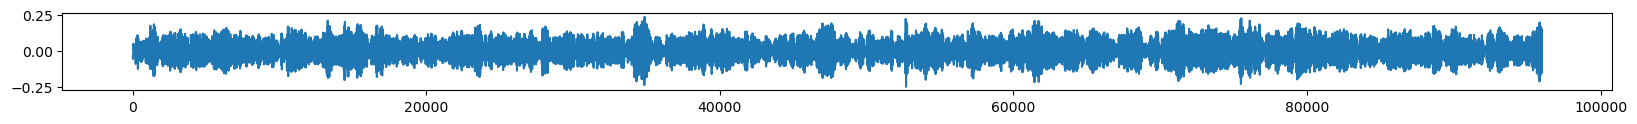

Finished epoch number 126 with a total of 10000 debug_seqs
 time: 2026-02-05 20:29:30.448381, epoch 127,  Loss: 0.3248
  Quantizer 0 Loss: 2.0738
  Quantizer 1 Loss: 3.1814
  Quantizer 2 Loss: 3.9242
  Quantizer 3 Loss: 4.3385
  Quantizer 4 Loss: 4.5961
  Quantizer 5 Loss: 4.7544
  Quantizer 6 Loss: 4.9300
  Quantizer 7 Loss: 5.0057
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


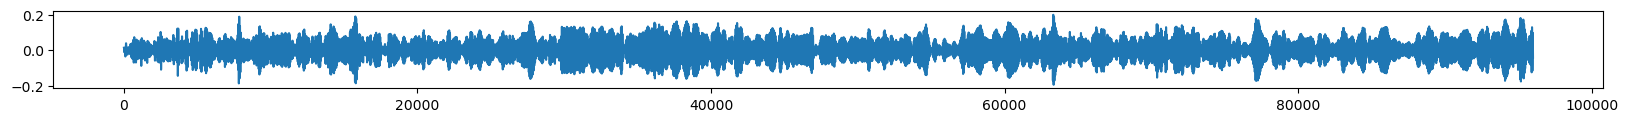

Finished epoch number 127 with a total of 10000 debug_seqs
 time: 2026-02-05 20:30:22.695312, epoch 128,  Loss: 0.3109
  Quantizer 0 Loss: 2.0685
  Quantizer 1 Loss: 3.1470
  Quantizer 2 Loss: 3.8990
  Quantizer 3 Loss: 4.3160
  Quantizer 4 Loss: 4.5875
  Quantizer 5 Loss: 4.7488
  Quantizer 6 Loss: 4.9238
  Quantizer 7 Loss: 5.0006
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


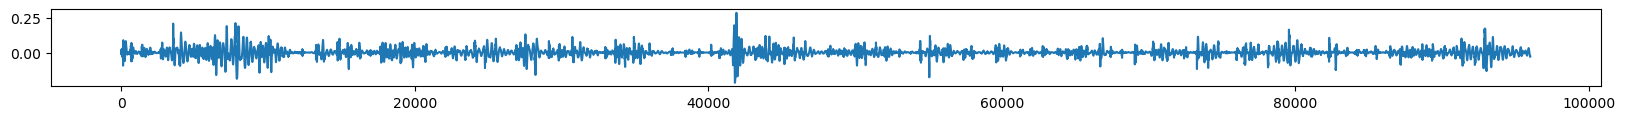

Finished epoch number 128 with a total of 10000 debug_seqs
 time: 2026-02-05 20:31:15.099459, epoch 129,  Loss: 0.3228
  Quantizer 0 Loss: 2.0558
  Quantizer 1 Loss: 3.1216
  Quantizer 2 Loss: 3.8769
  Quantizer 3 Loss: 4.2942
  Quantizer 4 Loss: 4.5655
  Quantizer 5 Loss: 4.7344
  Quantizer 6 Loss: 4.9133
  Quantizer 7 Loss: 4.9881
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


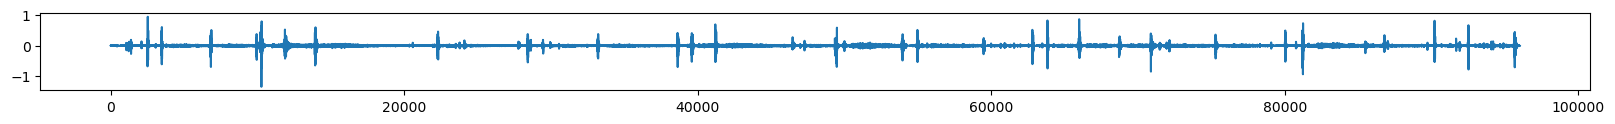

Finished epoch number 129 with a total of 10000 debug_seqs
 time: 2026-02-05 20:32:07.683996, epoch 130,  Loss: 0.3173
  Quantizer 0 Loss: 2.0696
  Quantizer 1 Loss: 3.1340
  Quantizer 2 Loss: 3.8884
  Quantizer 3 Loss: 4.3036
  Quantizer 4 Loss: 4.5732
  Quantizer 5 Loss: 4.7426
  Quantizer 6 Loss: 4.9210
  Quantizer 7 Loss: 4.9991
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


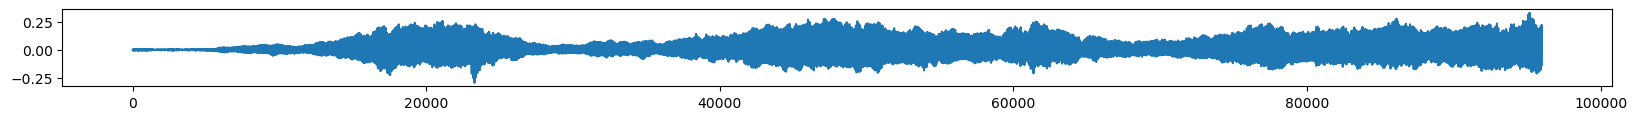

Finished epoch number 130 with a total of 10000 debug_seqs
 time: 2026-02-05 20:33:00.532518, epoch 131,  Loss: 0.3223
  Quantizer 0 Loss: 2.0674
  Quantizer 1 Loss: 3.1297
  Quantizer 2 Loss: 3.8767
  Quantizer 3 Loss: 4.2981
  Quantizer 4 Loss: 4.5669
  Quantizer 5 Loss: 4.7362
  Quantizer 6 Loss: 4.9158
  Quantizer 7 Loss: 4.9944
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


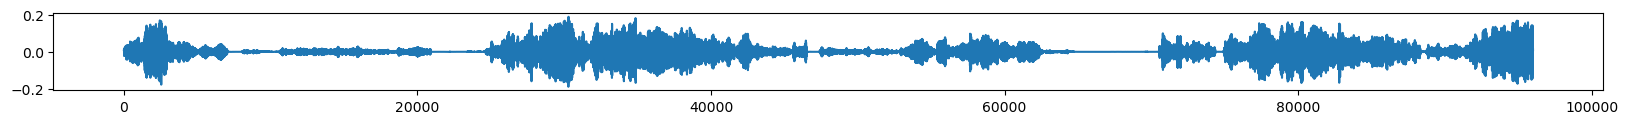

Finished epoch number 131 with a total of 10000 debug_seqs
 time: 2026-02-05 20:33:53.091350, epoch 132,  Loss: 0.3112
  Quantizer 0 Loss: 2.0572
  Quantizer 1 Loss: 3.1086
  Quantizer 2 Loss: 3.8584
  Quantizer 3 Loss: 4.2824
  Quantizer 4 Loss: 4.5514
  Quantizer 5 Loss: 4.7169
  Quantizer 6 Loss: 4.8960
  Quantizer 7 Loss: 4.9757
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


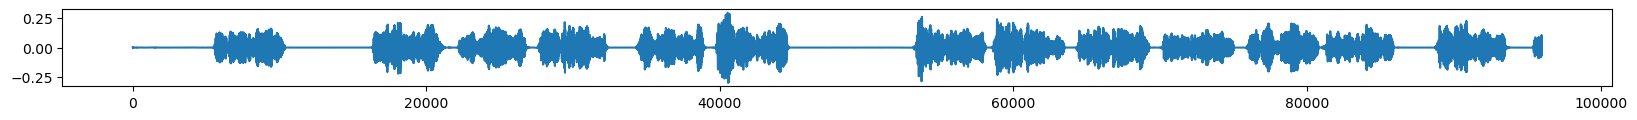

Finished epoch number 132 with a total of 10000 debug_seqs
 time: 2026-02-05 20:34:45.595348, epoch 133,  Loss: 0.3096
  Quantizer 0 Loss: 2.0635
  Quantizer 1 Loss: 3.1241
  Quantizer 2 Loss: 3.8671
  Quantizer 3 Loss: 4.2905
  Quantizer 4 Loss: 4.5618
  Quantizer 5 Loss: 4.7293
  Quantizer 6 Loss: 4.9099
  Quantizer 7 Loss: 4.9880
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


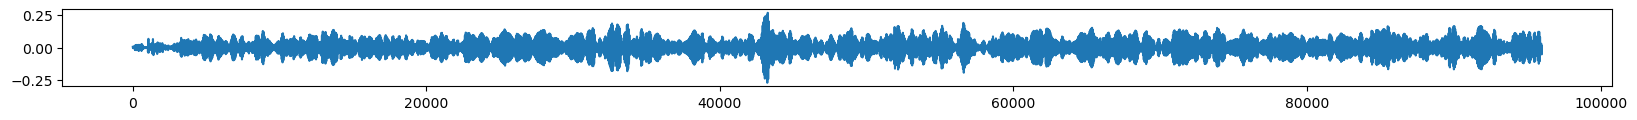

Finished epoch number 133 with a total of 10000 debug_seqs
 time: 2026-02-05 20:35:38.432557, epoch 134,  Loss: 0.3291
  Quantizer 0 Loss: 2.0625
  Quantizer 1 Loss: 3.1117
  Quantizer 2 Loss: 3.8542
  Quantizer 3 Loss: 4.2762
  Quantizer 4 Loss: 4.5485
  Quantizer 5 Loss: 4.7214
  Quantizer 6 Loss: 4.8985
  Quantizer 7 Loss: 4.9780
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


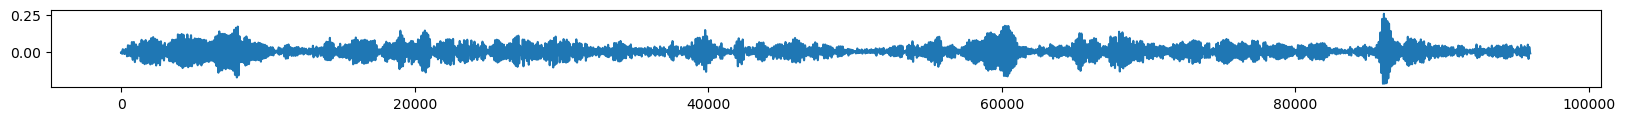

Finished epoch number 134 with a total of 10000 debug_seqs
 time: 2026-02-05 20:36:31.068780, epoch 135,  Loss: 0.3154
  Quantizer 0 Loss: 2.0590
  Quantizer 1 Loss: 3.1012
  Quantizer 2 Loss: 3.8490
  Quantizer 3 Loss: 4.2673
  Quantizer 4 Loss: 4.5430
  Quantizer 5 Loss: 4.7115
  Quantizer 6 Loss: 4.8922
  Quantizer 7 Loss: 4.9784
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


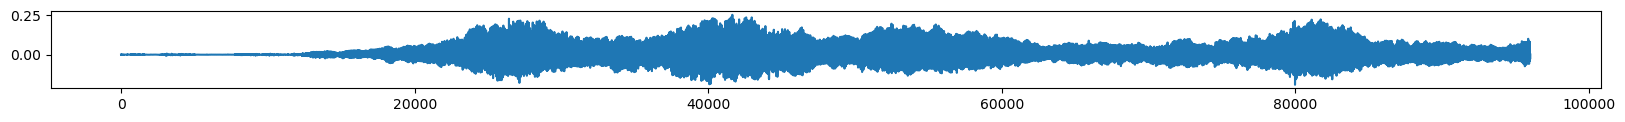

Finished epoch number 135 with a total of 10000 debug_seqs
 time: 2026-02-05 20:37:23.880920, epoch 136,  Loss: 0.3130
  Quantizer 0 Loss: 2.0576
  Quantizer 1 Loss: 3.0998
  Quantizer 2 Loss: 3.8457
  Quantizer 3 Loss: 4.2663
  Quantizer 4 Loss: 4.5411
  Quantizer 5 Loss: 4.7088
  Quantizer 6 Loss: 4.8969
  Quantizer 7 Loss: 4.9727
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


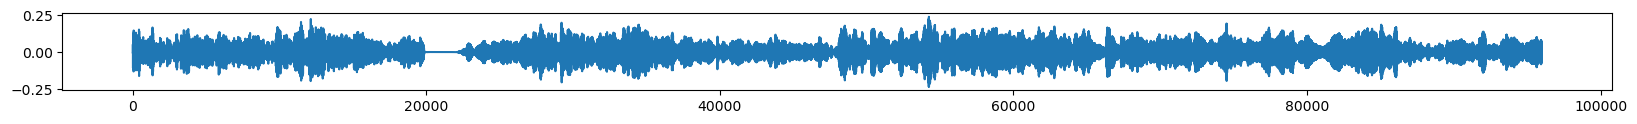

Finished epoch number 136 with a total of 10000 debug_seqs
 time: 2026-02-05 20:38:16.289413, epoch 137,  Loss: 0.3224
  Quantizer 0 Loss: 2.0692
  Quantizer 1 Loss: 3.1161
  Quantizer 2 Loss: 3.8530
  Quantizer 3 Loss: 4.2773
  Quantizer 4 Loss: 4.5528
  Quantizer 5 Loss: 4.7224
  Quantizer 6 Loss: 4.8997
  Quantizer 7 Loss: 4.9785
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


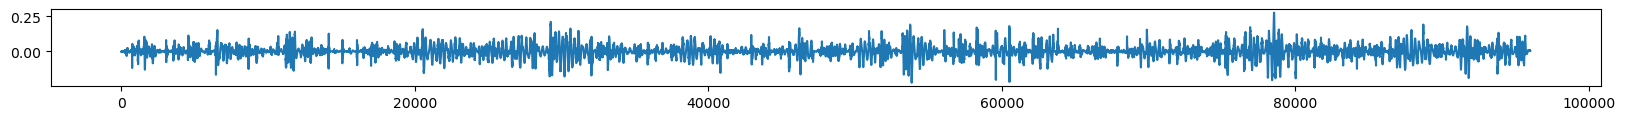

Finished epoch number 137 with a total of 10000 debug_seqs
 time: 2026-02-05 20:39:08.562326, epoch 138,  Loss: 0.3059
  Quantizer 0 Loss: 2.0501
  Quantizer 1 Loss: 3.0890
  Quantizer 2 Loss: 3.8394
  Quantizer 3 Loss: 4.2586
  Quantizer 4 Loss: 4.5325
  Quantizer 5 Loss: 4.7035
  Quantizer 6 Loss: 4.8850
  Quantizer 7 Loss: 4.9673
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


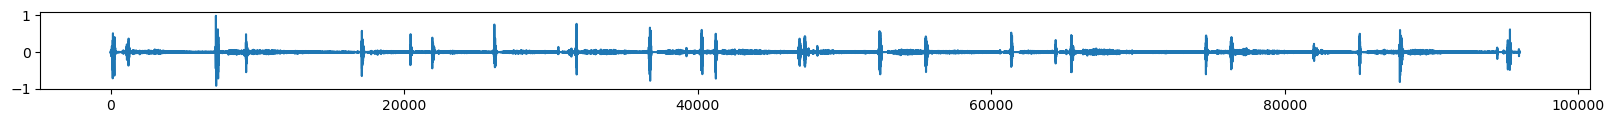

Finished epoch number 138 with a total of 10000 debug_seqs
 time: 2026-02-05 20:40:01.202149, epoch 139,  Loss: 0.3092
  Quantizer 0 Loss: 2.0449
  Quantizer 1 Loss: 3.0866
  Quantizer 2 Loss: 3.8327
  Quantizer 3 Loss: 4.2534
  Quantizer 4 Loss: 4.5324
  Quantizer 5 Loss: 4.7043
  Quantizer 6 Loss: 4.8911
  Quantizer 7 Loss: 4.9704
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


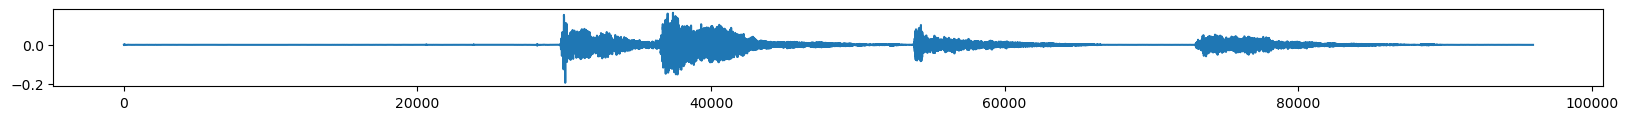

Finished epoch number 139 with a total of 10000 debug_seqs
 time: 2026-02-05 20:40:54.127407, epoch 140,  Loss: 0.3107
  Quantizer 0 Loss: 2.0443
  Quantizer 1 Loss: 3.0834
  Quantizer 2 Loss: 3.8279
  Quantizer 3 Loss: 4.2508
  Quantizer 4 Loss: 4.5257
  Quantizer 5 Loss: 4.6979
  Quantizer 6 Loss: 4.8789
  Quantizer 7 Loss: 4.9600
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


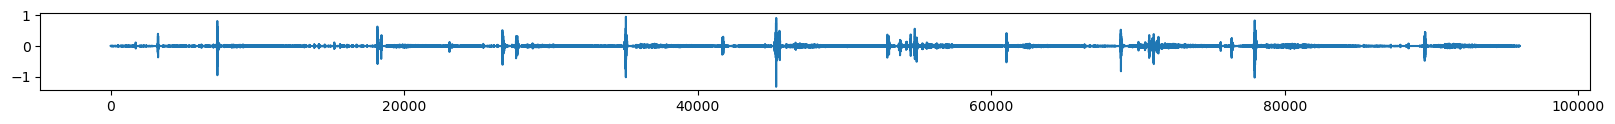

Finished epoch number 140 with a total of 10000 debug_seqs
 time: 2026-02-05 20:41:46.739282, epoch 141,  Loss: 0.3121
  Quantizer 0 Loss: 2.0597
  Quantizer 1 Loss: 3.0924
  Quantizer 2 Loss: 3.8340
  Quantizer 3 Loss: 4.2542
  Quantizer 4 Loss: 4.5271
  Quantizer 5 Loss: 4.6955
  Quantizer 6 Loss: 4.8757
  Quantizer 7 Loss: 4.9526
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


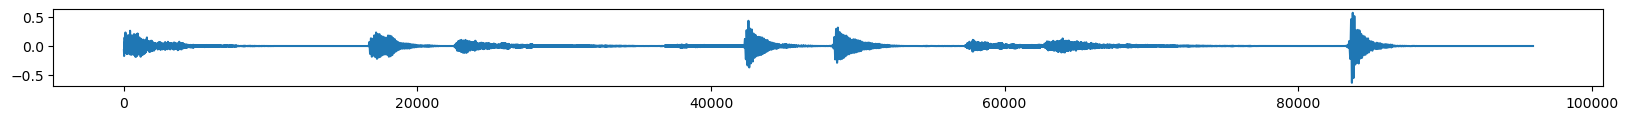

Finished epoch number 141 with a total of 10000 debug_seqs
 time: 2026-02-05 20:42:39.314313, epoch 142,  Loss: 0.3160
  Quantizer 0 Loss: 2.0556
  Quantizer 1 Loss: 3.0900
  Quantizer 2 Loss: 3.8378
  Quantizer 3 Loss: 4.2515
  Quantizer 4 Loss: 4.5296
  Quantizer 5 Loss: 4.7016
  Quantizer 6 Loss: 4.8812
  Quantizer 7 Loss: 4.9622
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


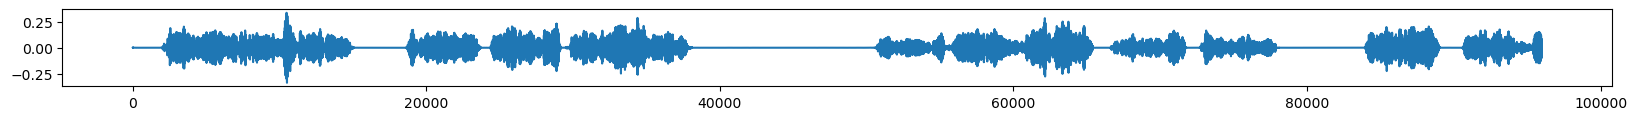

Finished epoch number 142 with a total of 10000 debug_seqs
 time: 2026-02-05 20:43:32.054138, epoch 143,  Loss: 0.3091
  Quantizer 0 Loss: 2.0545
  Quantizer 1 Loss: 3.0916
  Quantizer 2 Loss: 3.8364
  Quantizer 3 Loss: 4.2619
  Quantizer 4 Loss: 4.5372
  Quantizer 5 Loss: 4.7112
  Quantizer 6 Loss: 4.8895
  Quantizer 7 Loss: 4.9704
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


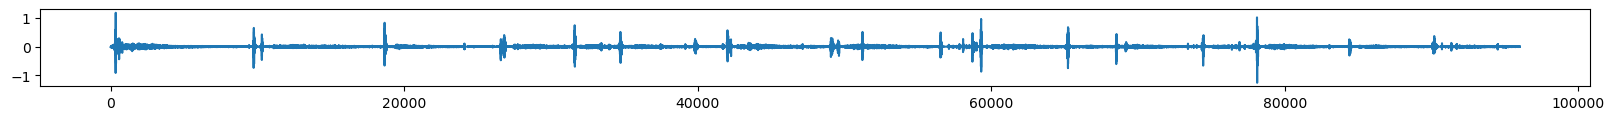

Finished epoch number 143 with a total of 10000 debug_seqs
 time: 2026-02-05 20:44:24.846505, epoch 144,  Loss: 0.3078
  Quantizer 0 Loss: 2.0365
  Quantizer 1 Loss: 3.0778
  Quantizer 2 Loss: 3.8218
  Quantizer 3 Loss: 4.2426
  Quantizer 4 Loss: 4.5228
  Quantizer 5 Loss: 4.6927
  Quantizer 6 Loss: 4.8792
  Quantizer 7 Loss: 4.9622
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


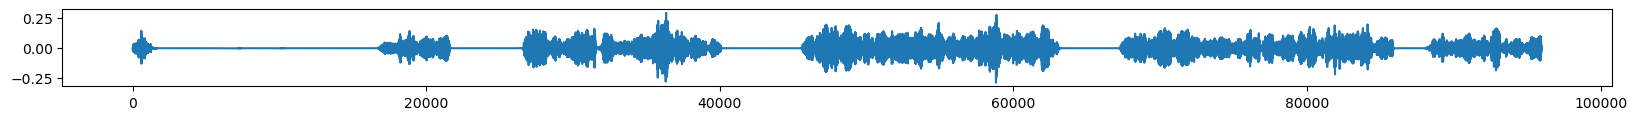

Finished epoch number 144 with a total of 10000 debug_seqs
 time: 2026-02-05 20:45:17.511282, epoch 145,  Loss: 0.3058
  Quantizer 0 Loss: 2.0467
  Quantizer 1 Loss: 3.0793
  Quantizer 2 Loss: 3.8121
  Quantizer 3 Loss: 4.2325
  Quantizer 4 Loss: 4.5112
  Quantizer 5 Loss: 4.6781
  Quantizer 6 Loss: 4.8572
  Quantizer 7 Loss: 4.9408
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


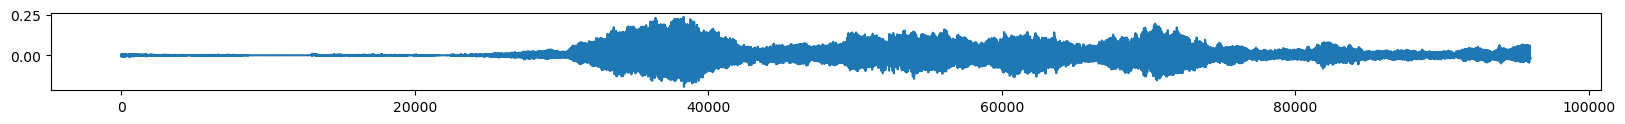

Finished epoch number 145 with a total of 10000 debug_seqs
 time: 2026-02-05 20:46:09.959858, epoch 146,  Loss: 0.3178
  Quantizer 0 Loss: 2.0535
  Quantizer 1 Loss: 3.0911
  Quantizer 2 Loss: 3.8317
  Quantizer 3 Loss: 4.2555
  Quantizer 4 Loss: 4.5316
  Quantizer 5 Loss: 4.7010
  Quantizer 6 Loss: 4.8825
  Quantizer 7 Loss: 4.9691
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


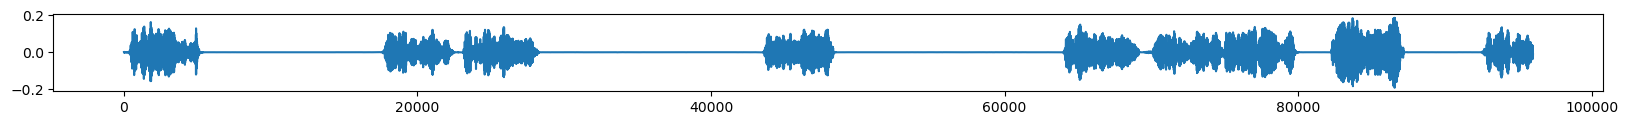

Finished epoch number 146 with a total of 10000 debug_seqs
 time: 2026-02-05 20:47:02.280628, epoch 147,  Loss: 0.3132
  Quantizer 0 Loss: 2.0504
  Quantizer 1 Loss: 3.0771
  Quantizer 2 Loss: 3.8245
  Quantizer 3 Loss: 4.2433
  Quantizer 4 Loss: 4.5201
  Quantizer 5 Loss: 4.6886
  Quantizer 6 Loss: 4.8687
  Quantizer 7 Loss: 4.9526
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


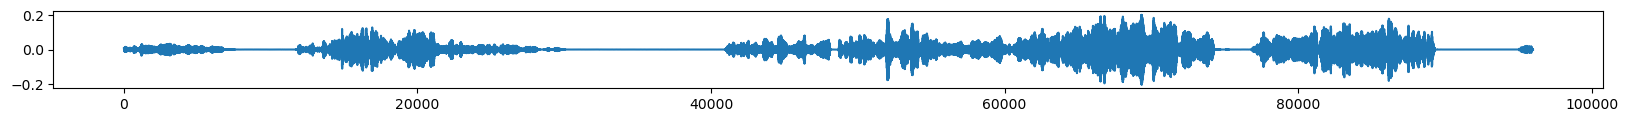

Finished epoch number 147 with a total of 10000 debug_seqs
 time: 2026-02-05 20:47:55.022245, epoch 148,  Loss: 0.3107
  Quantizer 0 Loss: 2.0556
  Quantizer 1 Loss: 3.0952
  Quantizer 2 Loss: 3.8329
  Quantizer 3 Loss: 4.2513
  Quantizer 4 Loss: 4.5300
  Quantizer 5 Loss: 4.7009
  Quantizer 6 Loss: 4.8834
  Quantizer 7 Loss: 4.9629
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


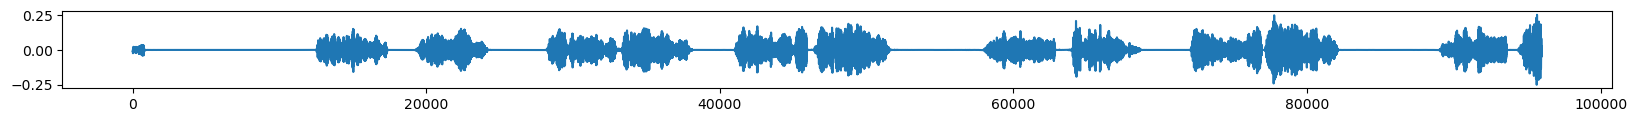

Finished epoch number 148 with a total of 10000 debug_seqs
 time: 2026-02-05 20:48:47.793865, epoch 149,  Loss: 0.3108
  Quantizer 0 Loss: 2.0501
  Quantizer 1 Loss: 3.0784
  Quantizer 2 Loss: 3.8197
  Quantizer 3 Loss: 4.2391
  Quantizer 4 Loss: 4.5168
  Quantizer 5 Loss: 4.6874
  Quantizer 6 Loss: 4.8702
  Quantizer 7 Loss: 4.9477
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


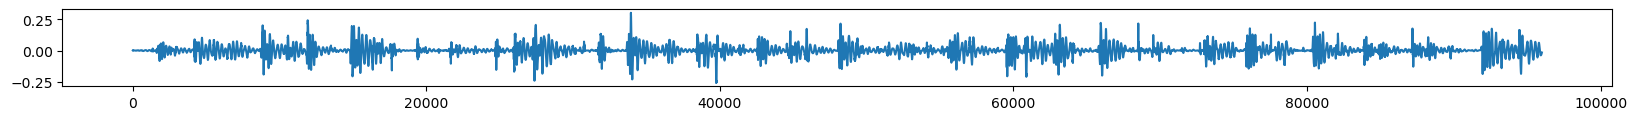

Finished epoch number 149 with a total of 10000 debug_seqs
 time: 2026-02-05 20:49:40.194098, epoch 150,  Loss: 0.2973
  Quantizer 0 Loss: 2.0381
  Quantizer 1 Loss: 3.0787
  Quantizer 2 Loss: 3.8137
  Quantizer 3 Loss: 4.2363
  Quantizer 4 Loss: 4.5154
  Quantizer 5 Loss: 4.6841
  Quantizer 6 Loss: 4.8710
  Quantizer 7 Loss: 4.9518
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


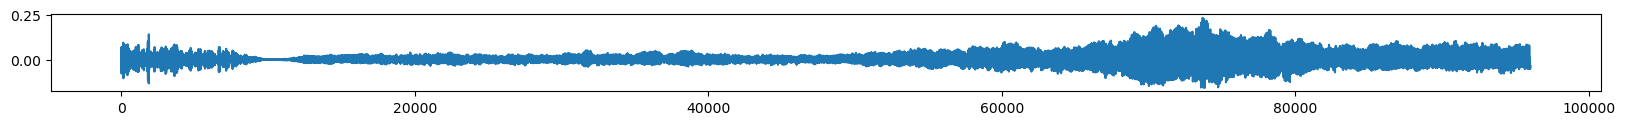

Saved checkpoint at epoch 150
Finished epoch number 150 with a total of 10000 debug_seqs
 time: 2026-02-05 20:50:31.564751, epoch 151,  Loss: 0.2903
  Quantizer 0 Loss: 2.0305
  Quantizer 1 Loss: 2.7302
  Quantizer 2 Loss: 3.3794
  Quantizer 3 Loss: 3.8052
  Quantizer 4 Loss: 4.0922
  Quantizer 5 Loss: 4.2877
  Quantizer 6 Loss: 4.4907
  Quantizer 7 Loss: 4.5940
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


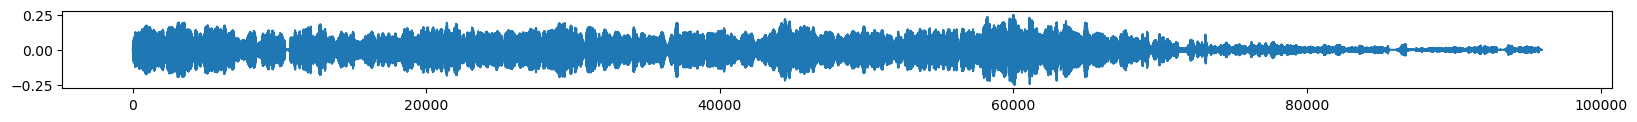

Finished epoch number 151 with a total of 10000 debug_seqs
 time: 2026-02-05 20:51:23.016081, epoch 152,  Loss: 0.2721
  Quantizer 0 Loss: 2.0261
  Quantizer 1 Loss: 2.6832
  Quantizer 2 Loss: 3.3081
  Quantizer 3 Loss: 3.7224
  Quantizer 4 Loss: 4.0078
  Quantizer 5 Loss: 4.2080
  Quantizer 6 Loss: 4.4118
  Quantizer 7 Loss: 4.5220
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


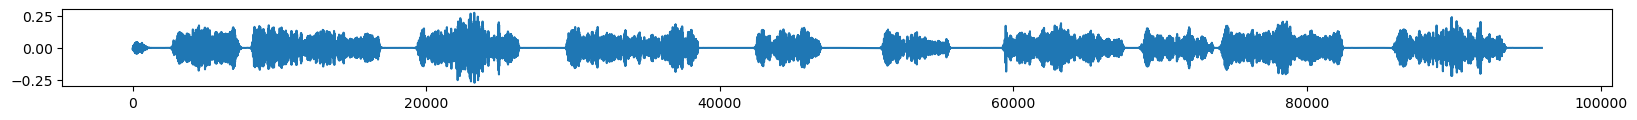

Finished epoch number 152 with a total of 10000 debug_seqs
 time: 2026-02-05 20:52:14.399485, epoch 153,  Loss: 0.2690
  Quantizer 0 Loss: 2.0275
  Quantizer 1 Loss: 2.6647
  Quantizer 2 Loss: 3.2782
  Quantizer 3 Loss: 3.6802
  Quantizer 4 Loss: 3.9671
  Quantizer 5 Loss: 4.1594
  Quantizer 6 Loss: 4.3577
  Quantizer 7 Loss: 4.4643
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


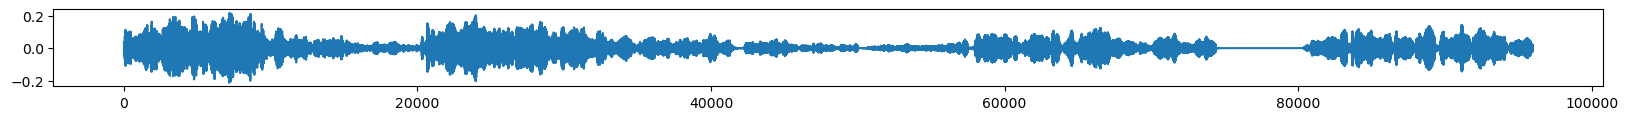

Finished epoch number 153 with a total of 10000 debug_seqs
 time: 2026-02-05 20:53:05.470406, epoch 154,  Loss: 0.2694
  Quantizer 0 Loss: 2.0224
  Quantizer 1 Loss: 2.6632
  Quantizer 2 Loss: 3.2714
  Quantizer 3 Loss: 3.6780
  Quantizer 4 Loss: 3.9596
  Quantizer 5 Loss: 4.1540
  Quantizer 6 Loss: 4.3594
  Quantizer 7 Loss: 4.4665
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


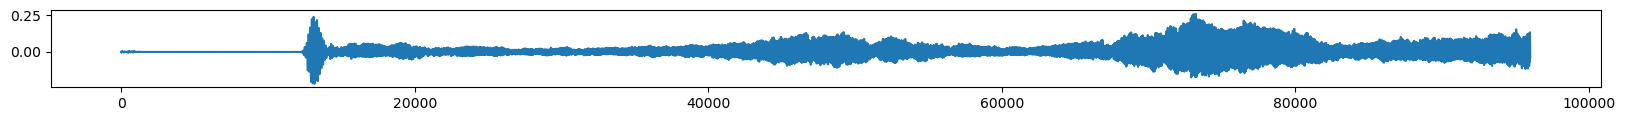

Finished epoch number 154 with a total of 10000 debug_seqs
 time: 2026-02-05 20:53:56.613570, epoch 155,  Loss: 0.2702
  Quantizer 0 Loss: 2.0286
  Quantizer 1 Loss: 2.6694
  Quantizer 2 Loss: 3.2712
  Quantizer 3 Loss: 3.6727
  Quantizer 4 Loss: 3.9566
  Quantizer 5 Loss: 4.1537
  Quantizer 6 Loss: 4.3504
  Quantizer 7 Loss: 4.4571
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


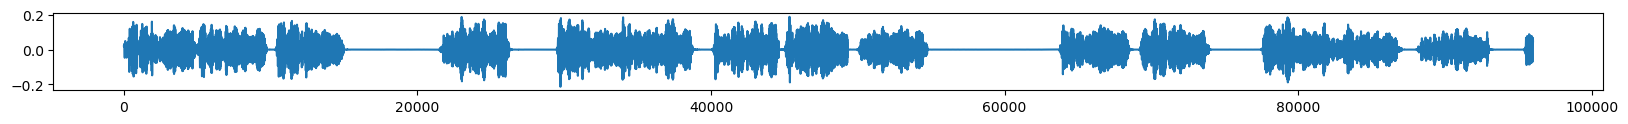

Finished epoch number 155 with a total of 10000 debug_seqs
 time: 2026-02-05 20:54:48.000303, epoch 156,  Loss: 0.2741
  Quantizer 0 Loss: 2.0262
  Quantizer 1 Loss: 2.6609
  Quantizer 2 Loss: 3.2647
  Quantizer 3 Loss: 3.6640
  Quantizer 4 Loss: 3.9459
  Quantizer 5 Loss: 4.1394
  Quantizer 6 Loss: 4.3398
  Quantizer 7 Loss: 4.4436
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


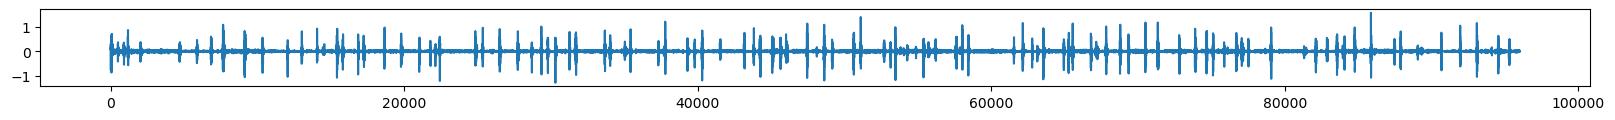

Finished epoch number 156 with a total of 10000 debug_seqs
 time: 2026-02-05 20:55:39.146279, epoch 157,  Loss: 0.2703
  Quantizer 0 Loss: 2.0267
  Quantizer 1 Loss: 2.6592
  Quantizer 2 Loss: 3.2619
  Quantizer 3 Loss: 3.6590
  Quantizer 4 Loss: 3.9357
  Quantizer 5 Loss: 4.1362
  Quantizer 6 Loss: 4.3282
  Quantizer 7 Loss: 4.4318
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


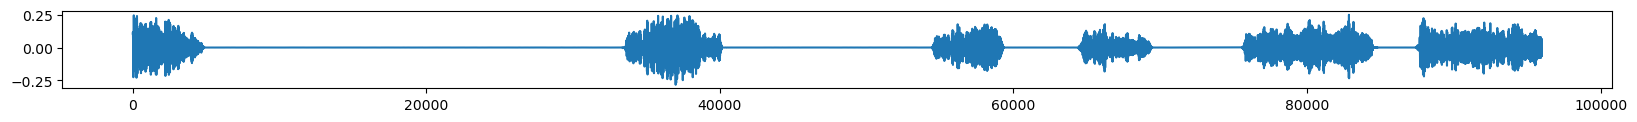

Finished epoch number 157 with a total of 10000 debug_seqs
 time: 2026-02-05 20:56:30.456264, epoch 158,  Loss: 0.2813
  Quantizer 0 Loss: 2.0188
  Quantizer 1 Loss: 2.6477
  Quantizer 2 Loss: 3.2497
  Quantizer 3 Loss: 3.6507
  Quantizer 4 Loss: 3.9303
  Quantizer 5 Loss: 4.1222
  Quantizer 6 Loss: 4.3211
  Quantizer 7 Loss: 4.4257
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


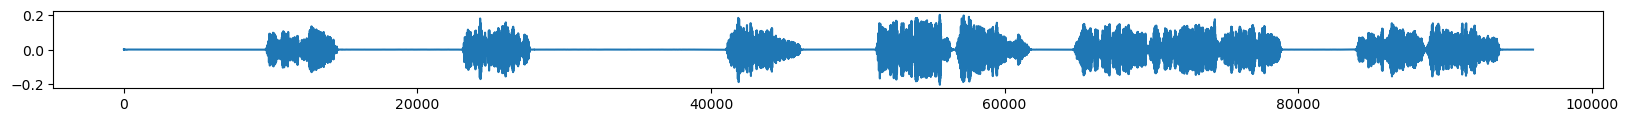

Finished epoch number 158 with a total of 10000 debug_seqs
 time: 2026-02-05 20:57:21.654820, epoch 159,  Loss: 0.2748
  Quantizer 0 Loss: 2.0278
  Quantizer 1 Loss: 2.6566
  Quantizer 2 Loss: 3.2574
  Quantizer 3 Loss: 3.6580
  Quantizer 4 Loss: 3.9406
  Quantizer 5 Loss: 4.1353
  Quantizer 6 Loss: 4.3305
  Quantizer 7 Loss: 4.4378
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


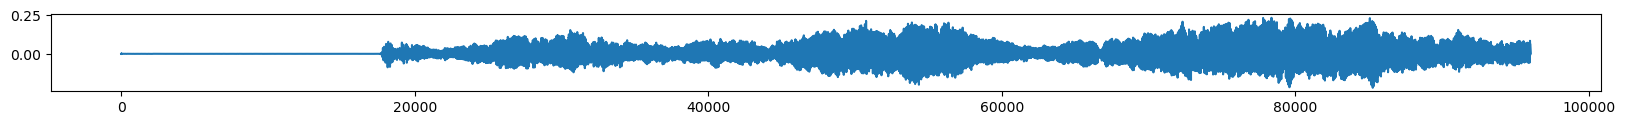

Finished epoch number 159 with a total of 10000 debug_seqs
 time: 2026-02-05 20:58:13.185906, epoch 160,  Loss: 0.2766
  Quantizer 0 Loss: 2.0247
  Quantizer 1 Loss: 2.6525
  Quantizer 2 Loss: 3.2537
  Quantizer 3 Loss: 3.6534
  Quantizer 4 Loss: 3.9335
  Quantizer 5 Loss: 4.1260
  Quantizer 6 Loss: 4.3280
  Quantizer 7 Loss: 4.4333
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


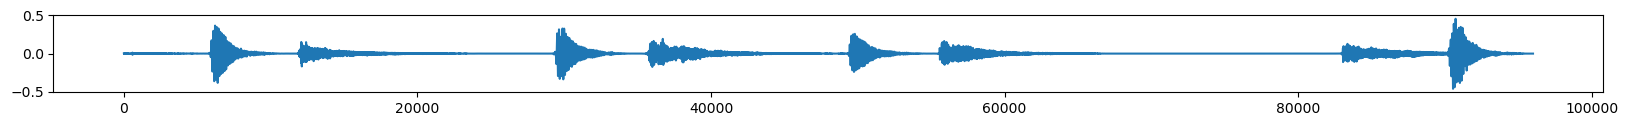

Finished epoch number 160 with a total of 10000 debug_seqs
 time: 2026-02-05 20:59:04.264921, epoch 161,  Loss: 0.2736
  Quantizer 0 Loss: 2.0276
  Quantizer 1 Loss: 2.6621
  Quantizer 2 Loss: 3.2614
  Quantizer 3 Loss: 3.6624
  Quantizer 4 Loss: 3.9419
  Quantizer 5 Loss: 4.1364
  Quantizer 6 Loss: 4.3328
  Quantizer 7 Loss: 4.4408
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


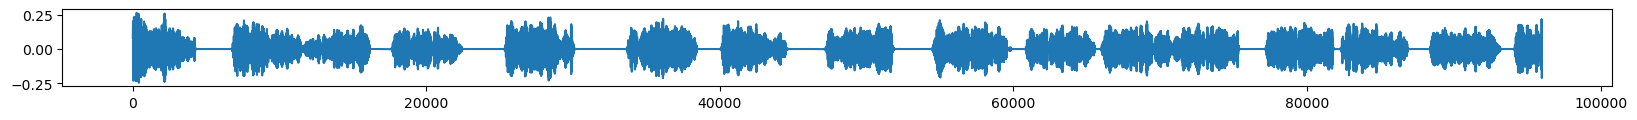

Finished epoch number 161 with a total of 10000 debug_seqs
 time: 2026-02-05 20:59:55.504592, epoch 162,  Loss: 0.2642
  Quantizer 0 Loss: 2.0198
  Quantizer 1 Loss: 2.6486
  Quantizer 2 Loss: 3.2477
  Quantizer 3 Loss: 3.6474
  Quantizer 4 Loss: 3.9271
  Quantizer 5 Loss: 4.1242
  Quantizer 6 Loss: 4.3209
  Quantizer 7 Loss: 4.4234
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


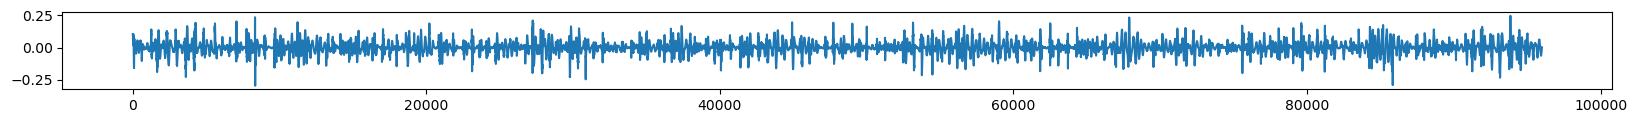

Finished epoch number 162 with a total of 10000 debug_seqs
 time: 2026-02-05 21:00:46.935364, epoch 163,  Loss: 0.2784
  Quantizer 0 Loss: 2.0396
  Quantizer 1 Loss: 2.6665
  Quantizer 2 Loss: 3.2739
  Quantizer 3 Loss: 3.6685
  Quantizer 4 Loss: 3.9482
  Quantizer 5 Loss: 4.1435
  Quantizer 6 Loss: 4.3390
  Quantizer 7 Loss: 4.4437
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


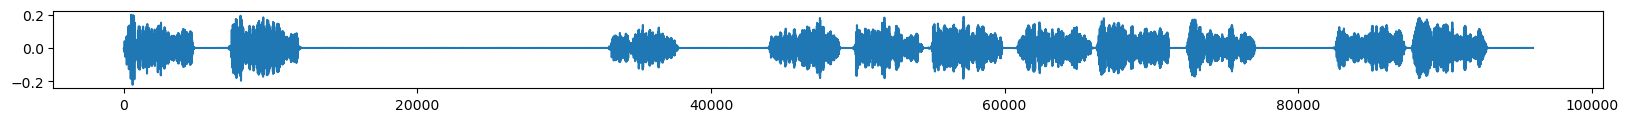

Finished epoch number 163 with a total of 10000 debug_seqs
 time: 2026-02-05 21:01:38.118828, epoch 164,  Loss: 0.2757
  Quantizer 0 Loss: 2.0304
  Quantizer 1 Loss: 2.6593
  Quantizer 2 Loss: 3.2558
  Quantizer 3 Loss: 3.6574
  Quantizer 4 Loss: 3.9411
  Quantizer 5 Loss: 4.1294
  Quantizer 6 Loss: 4.3296
  Quantizer 7 Loss: 4.4377
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


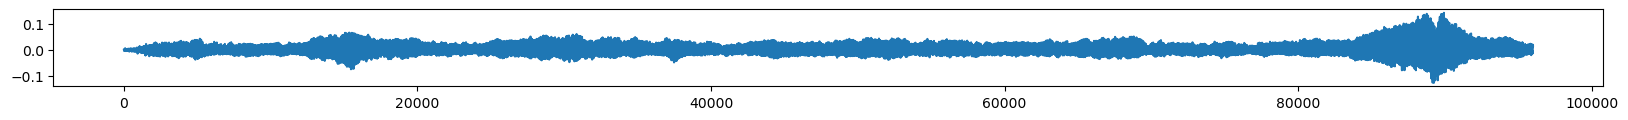

Finished epoch number 164 with a total of 10000 debug_seqs
 time: 2026-02-05 21:02:29.401125, epoch 165,  Loss: 0.2797
  Quantizer 0 Loss: 2.0391
  Quantizer 1 Loss: 2.6560
  Quantizer 2 Loss: 3.2568
  Quantizer 3 Loss: 3.6556
  Quantizer 4 Loss: 3.9324
  Quantizer 5 Loss: 4.1260
  Quantizer 6 Loss: 4.3203
  Quantizer 7 Loss: 4.4196
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


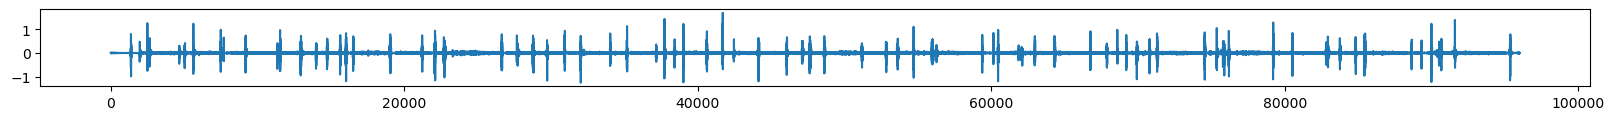

Finished epoch number 165 with a total of 10000 debug_seqs
 time: 2026-02-05 21:03:20.707522, epoch 166,  Loss: 0.2809
  Quantizer 0 Loss: 2.0319
  Quantizer 1 Loss: 2.6625
  Quantizer 2 Loss: 3.2623
  Quantizer 3 Loss: 3.6602
  Quantizer 4 Loss: 3.9377
  Quantizer 5 Loss: 4.1314
  Quantizer 6 Loss: 4.3298
  Quantizer 7 Loss: 4.4340
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


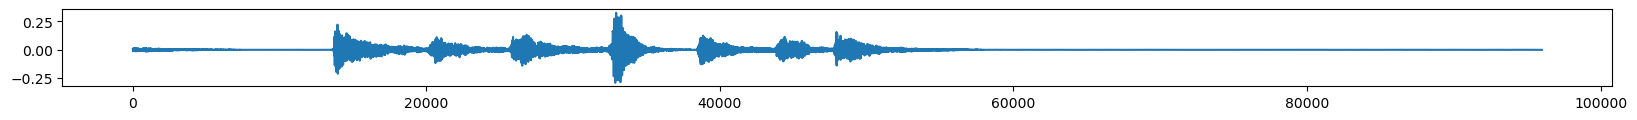

Finished epoch number 166 with a total of 10000 debug_seqs
 time: 2026-02-05 21:04:12.014895, epoch 167,  Loss: 0.2749
  Quantizer 0 Loss: 2.0319
  Quantizer 1 Loss: 2.6588
  Quantizer 2 Loss: 3.2576
  Quantizer 3 Loss: 3.6501
  Quantizer 4 Loss: 3.9301
  Quantizer 5 Loss: 4.1238
  Quantizer 6 Loss: 4.3190
  Quantizer 7 Loss: 4.4206
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


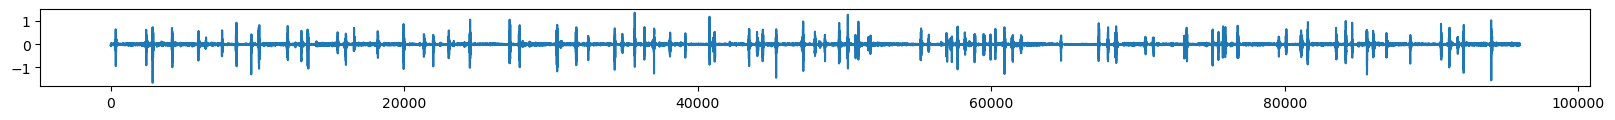

Finished epoch number 167 with a total of 10000 debug_seqs
 time: 2026-02-05 21:05:03.253110, epoch 168,  Loss: 0.2734
  Quantizer 0 Loss: 2.0241
  Quantizer 1 Loss: 2.6465
  Quantizer 2 Loss: 3.2374
  Quantizer 3 Loss: 3.6337
  Quantizer 4 Loss: 3.9168
  Quantizer 5 Loss: 4.1119
  Quantizer 6 Loss: 4.3067
  Quantizer 7 Loss: 4.4130
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


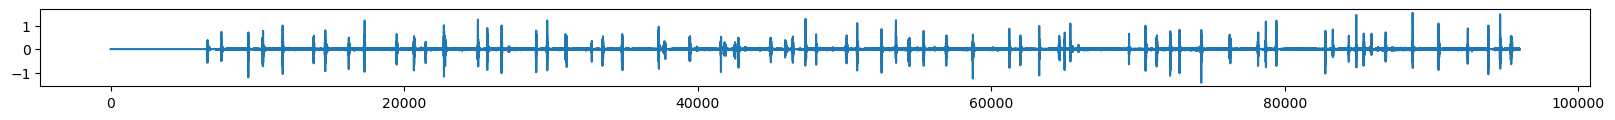

Finished epoch number 168 with a total of 10000 debug_seqs
 time: 2026-02-05 21:05:54.830061, epoch 169,  Loss: 0.2658
  Quantizer 0 Loss: 2.0342
  Quantizer 1 Loss: 2.6516
  Quantizer 2 Loss: 3.2502
  Quantizer 3 Loss: 3.6461
  Quantizer 4 Loss: 3.9316
  Quantizer 5 Loss: 4.1216
  Quantizer 6 Loss: 4.3177
  Quantizer 7 Loss: 4.4264
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


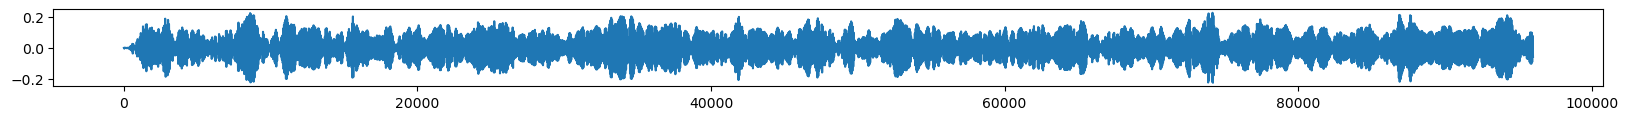

Finished epoch number 169 with a total of 10000 debug_seqs
 time: 2026-02-05 21:06:45.997663, epoch 170,  Loss: 0.2757
  Quantizer 0 Loss: 2.0329
  Quantizer 1 Loss: 2.6590
  Quantizer 2 Loss: 3.2557
  Quantizer 3 Loss: 3.6530
  Quantizer 4 Loss: 3.9332
  Quantizer 5 Loss: 4.1223
  Quantizer 6 Loss: 4.3236
  Quantizer 7 Loss: 4.4237
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


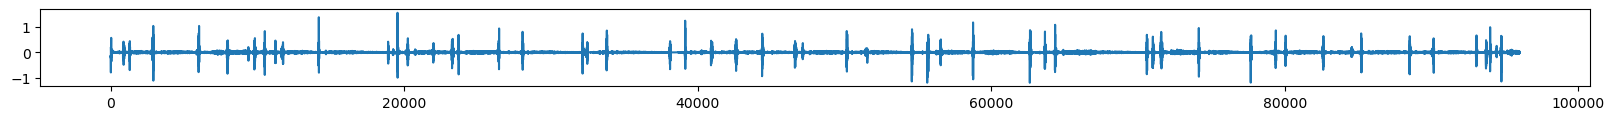

Finished epoch number 170 with a total of 10000 debug_seqs
 time: 2026-02-05 21:07:37.162676, epoch 171,  Loss: 0.2687
  Quantizer 0 Loss: 2.0119
  Quantizer 1 Loss: 2.6344
  Quantizer 2 Loss: 3.2349
  Quantizer 3 Loss: 3.6329
  Quantizer 4 Loss: 3.9134
  Quantizer 5 Loss: 4.1098
  Quantizer 6 Loss: 4.3072
  Quantizer 7 Loss: 4.4136
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


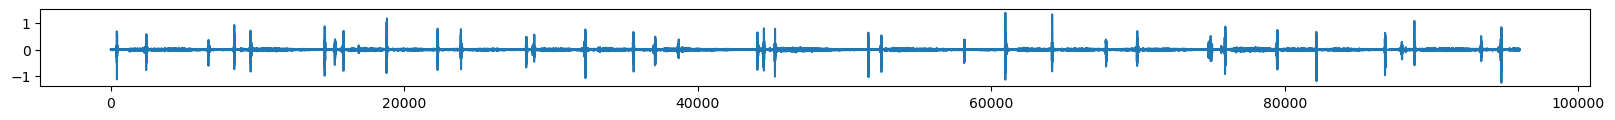

Finished epoch number 171 with a total of 10000 debug_seqs
 time: 2026-02-05 21:08:28.479962, epoch 172,  Loss: 0.2712
  Quantizer 0 Loss: 2.0122
  Quantizer 1 Loss: 2.6313
  Quantizer 2 Loss: 3.2298
  Quantizer 3 Loss: 3.6292
  Quantizer 4 Loss: 3.9097
  Quantizer 5 Loss: 4.0995
  Quantizer 6 Loss: 4.3069
  Quantizer 7 Loss: 4.4063
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


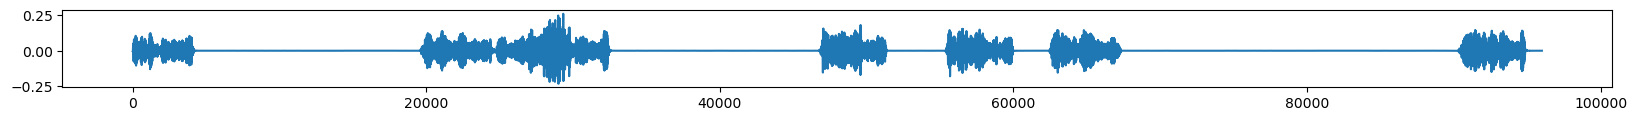

Finished epoch number 172 with a total of 10000 debug_seqs
 time: 2026-02-05 21:09:20.006498, epoch 173,  Loss: 0.2735
  Quantizer 0 Loss: 2.0320
  Quantizer 1 Loss: 2.6499
  Quantizer 2 Loss: 3.2490
  Quantizer 3 Loss: 3.6489
  Quantizer 4 Loss: 3.9316
  Quantizer 5 Loss: 4.1253
  Quantizer 6 Loss: 4.3185
  Quantizer 7 Loss: 4.4262
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


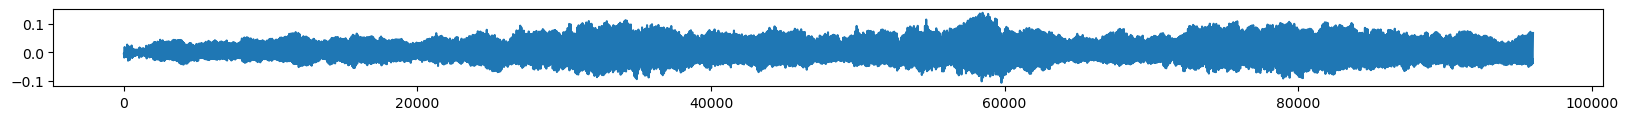

Finished epoch number 173 with a total of 10000 debug_seqs
 time: 2026-02-05 21:10:11.153526, epoch 174,  Loss: 0.2741
  Quantizer 0 Loss: 2.0199
  Quantizer 1 Loss: 2.6437
  Quantizer 2 Loss: 3.2408
  Quantizer 3 Loss: 3.6442
  Quantizer 4 Loss: 3.9203
  Quantizer 5 Loss: 4.1102
  Quantizer 6 Loss: 4.3092
  Quantizer 7 Loss: 4.4145
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


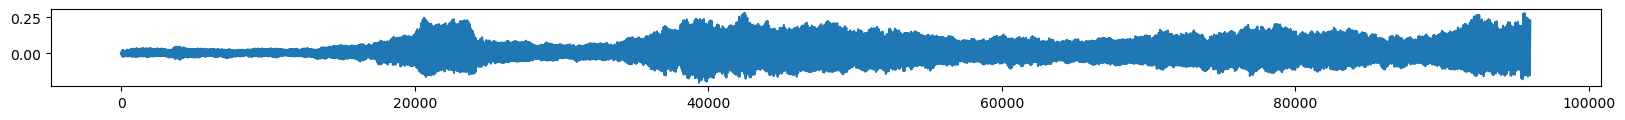

Finished epoch number 174 with a total of 10000 debug_seqs
 time: 2026-02-05 21:11:02.570438, epoch 175,  Loss: 0.2859
  Quantizer 0 Loss: 2.0297
  Quantizer 1 Loss: 2.6573
  Quantizer 2 Loss: 3.2532
  Quantizer 3 Loss: 3.6559
  Quantizer 4 Loss: 3.9351
  Quantizer 5 Loss: 4.1266
  Quantizer 6 Loss: 4.3294
  Quantizer 7 Loss: 4.4342
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


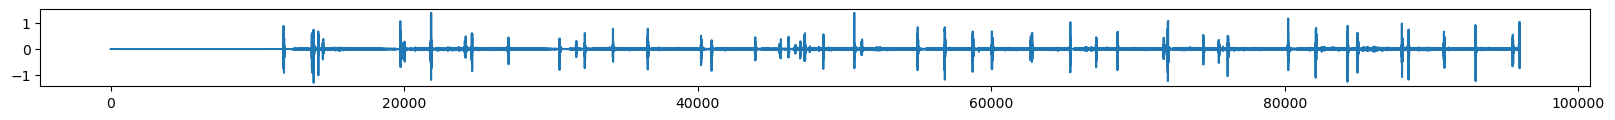

Saved checkpoint at epoch 175
Finished epoch number 175 with a total of 10000 debug_seqs
 time: 2026-02-05 21:11:54.174851, epoch 176,  Loss: 0.3192
  Quantizer 0 Loss: 2.0974
  Quantizer 1 Loss: 3.2661
  Quantizer 2 Loss: 4.0053
  Quantizer 3 Loss: 4.3863
  Quantizer 4 Loss: 4.6332
  Quantizer 5 Loss: 4.7751
  Quantizer 6 Loss: 4.9465
  Quantizer 7 Loss: 5.0160
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


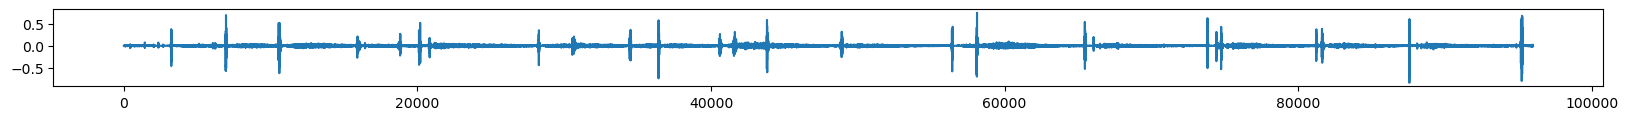

Finished epoch number 176 with a total of 10000 debug_seqs
 time: 2026-02-05 21:12:45.702433, epoch 177,  Loss: 0.3137
  Quantizer 0 Loss: 2.0744
  Quantizer 1 Loss: 3.1765
  Quantizer 2 Loss: 3.9331
  Quantizer 3 Loss: 4.3474
  Quantizer 4 Loss: 4.6110
  Quantizer 5 Loss: 4.7629
  Quantizer 6 Loss: 4.9405
  Quantizer 7 Loss: 5.0134
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


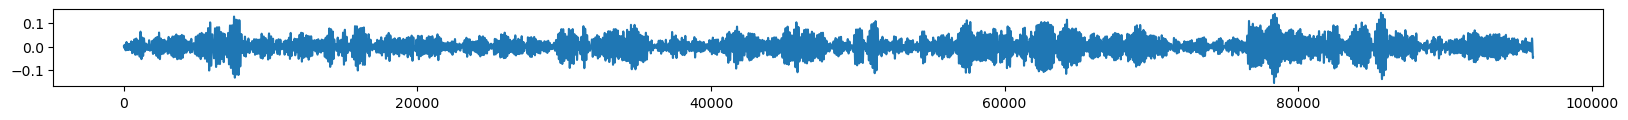

Finished epoch number 177 with a total of 10000 debug_seqs
 time: 2026-02-05 21:13:37.436988, epoch 178,  Loss: 0.3149
  Quantizer 0 Loss: 2.0636
  Quantizer 1 Loss: 3.1436
  Quantizer 2 Loss: 3.9039
  Quantizer 3 Loss: 4.3230
  Quantizer 4 Loss: 4.5911
  Quantizer 5 Loss: 4.7516
  Quantizer 6 Loss: 4.9324
  Quantizer 7 Loss: 5.0078
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


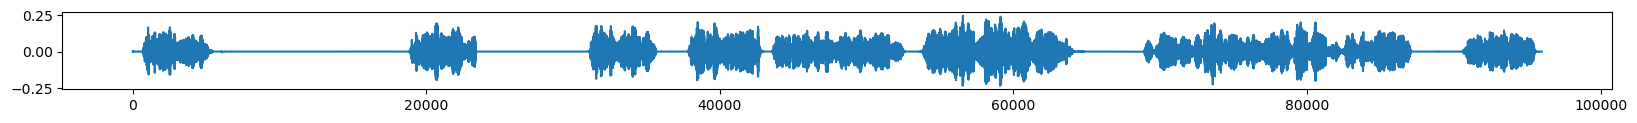

Finished epoch number 178 with a total of 10000 debug_seqs
 time: 2026-02-05 21:14:29.085213, epoch 179,  Loss: 0.3040
  Quantizer 0 Loss: 2.0473
  Quantizer 1 Loss: 3.1178
  Quantizer 2 Loss: 3.8730
  Quantizer 3 Loss: 4.2933
  Quantizer 4 Loss: 4.5666
  Quantizer 5 Loss: 4.7358
  Quantizer 6 Loss: 4.9115
  Quantizer 7 Loss: 4.9863
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


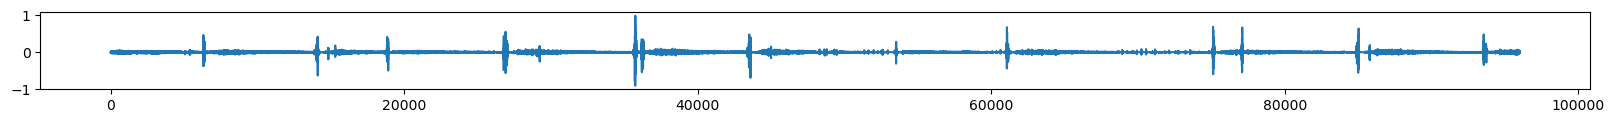

Finished epoch number 179 with a total of 10000 debug_seqs
 time: 2026-02-05 21:15:20.398906, epoch 180,  Loss: 0.3090
  Quantizer 0 Loss: 2.0593
  Quantizer 1 Loss: 3.1233
  Quantizer 2 Loss: 3.8771
  Quantizer 3 Loss: 4.2936
  Quantizer 4 Loss: 4.5651
  Quantizer 5 Loss: 4.7332
  Quantizer 6 Loss: 4.9151
  Quantizer 7 Loss: 4.9908
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


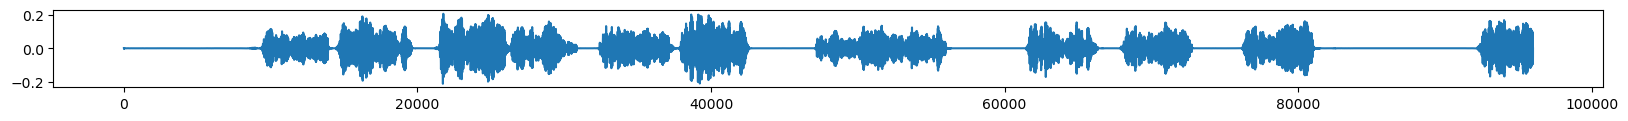

Finished epoch number 180 with a total of 10000 debug_seqs
 time: 2026-02-05 21:16:11.905463, epoch 181,  Loss: 0.3187
  Quantizer 0 Loss: 2.0455
  Quantizer 1 Loss: 3.1052
  Quantizer 2 Loss: 3.8564
  Quantizer 3 Loss: 4.2755
  Quantizer 4 Loss: 4.5519
  Quantizer 5 Loss: 4.7146
  Quantizer 6 Loss: 4.8976
  Quantizer 7 Loss: 4.9758
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


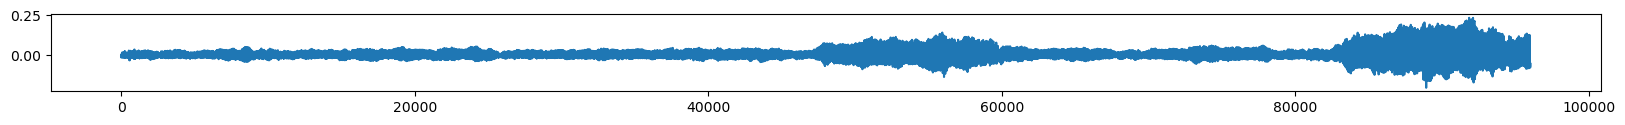

Finished epoch number 181 with a total of 10000 debug_seqs
 time: 2026-02-05 21:17:03.440262, epoch 182,  Loss: 0.3195
  Quantizer 0 Loss: 2.0548
  Quantizer 1 Loss: 3.1105
  Quantizer 2 Loss: 3.8584
  Quantizer 3 Loss: 4.2774
  Quantizer 4 Loss: 4.5497
  Quantizer 5 Loss: 4.7136
  Quantizer 6 Loss: 4.8896
  Quantizer 7 Loss: 4.9706
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


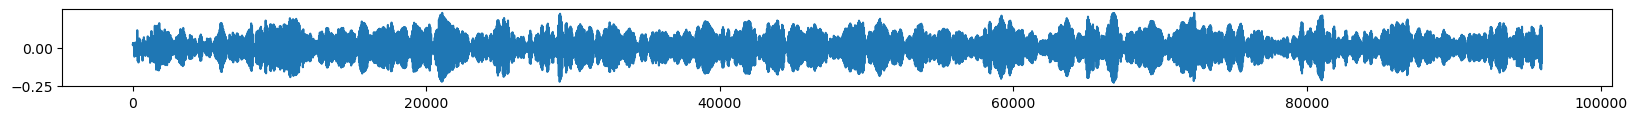

Finished epoch number 182 with a total of 10000 debug_seqs
 time: 2026-02-05 21:17:54.694233, epoch 183,  Loss: 0.3222
  Quantizer 0 Loss: 2.0555
  Quantizer 1 Loss: 3.1043
  Quantizer 2 Loss: 3.8552
  Quantizer 3 Loss: 4.2726
  Quantizer 4 Loss: 4.5500
  Quantizer 5 Loss: 4.7156
  Quantizer 6 Loss: 4.8998
  Quantizer 7 Loss: 4.9808
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


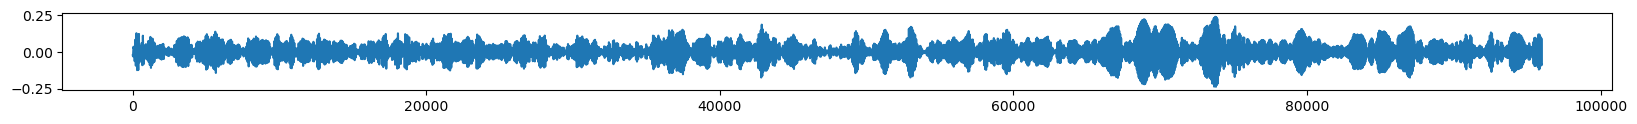

Finished epoch number 183 with a total of 10000 debug_seqs
 time: 2026-02-05 21:18:46.031475, epoch 184,  Loss: 0.3185
  Quantizer 0 Loss: 2.0391
  Quantizer 1 Loss: 3.0850
  Quantizer 2 Loss: 3.8323
  Quantizer 3 Loss: 4.2550
  Quantizer 4 Loss: 4.5352
  Quantizer 5 Loss: 4.7034
  Quantizer 6 Loss: 4.8851
  Quantizer 7 Loss: 4.9607
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


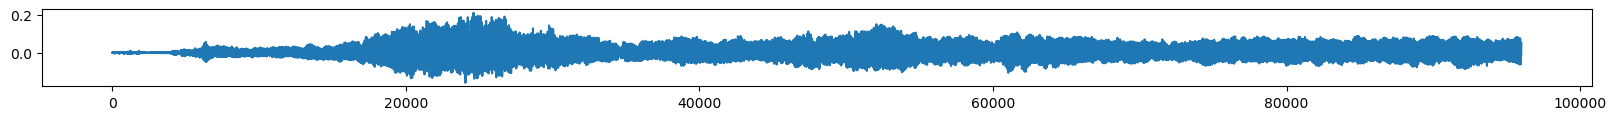

Finished epoch number 184 with a total of 10000 debug_seqs
 time: 2026-02-05 21:19:37.539608, epoch 185,  Loss: 0.3274
  Quantizer 0 Loss: 2.0472
  Quantizer 1 Loss: 3.0975
  Quantizer 2 Loss: 3.8384
  Quantizer 3 Loss: 4.2628
  Quantizer 4 Loss: 4.5339
  Quantizer 5 Loss: 4.7043
  Quantizer 6 Loss: 4.8825
  Quantizer 7 Loss: 4.9670
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


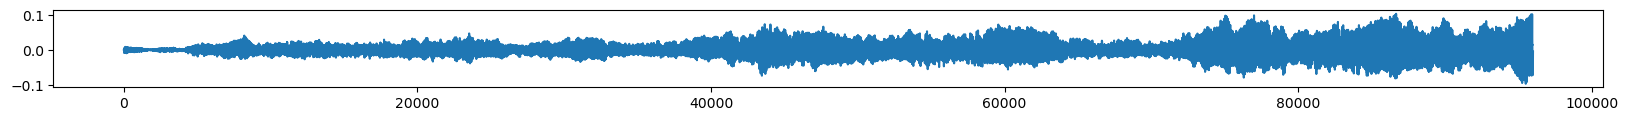

Finished epoch number 185 with a total of 10000 debug_seqs
 time: 2026-02-05 21:20:29.085339, epoch 186,  Loss: 0.3113
  Quantizer 0 Loss: 2.0381
  Quantizer 1 Loss: 3.0851
  Quantizer 2 Loss: 3.8308
  Quantizer 3 Loss: 4.2462
  Quantizer 4 Loss: 4.5280
  Quantizer 5 Loss: 4.6988
  Quantizer 6 Loss: 4.8795
  Quantizer 7 Loss: 4.9626
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


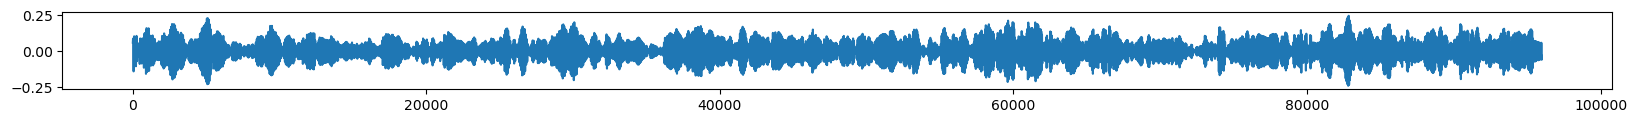

Finished epoch number 186 with a total of 10000 debug_seqs
 time: 2026-02-05 21:21:20.642641, epoch 187,  Loss: 0.3074
  Quantizer 0 Loss: 2.0457
  Quantizer 1 Loss: 3.0797
  Quantizer 2 Loss: 3.8236
  Quantizer 3 Loss: 4.2489
  Quantizer 4 Loss: 4.5217
  Quantizer 5 Loss: 4.6910
  Quantizer 6 Loss: 4.8735
  Quantizer 7 Loss: 4.9540
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


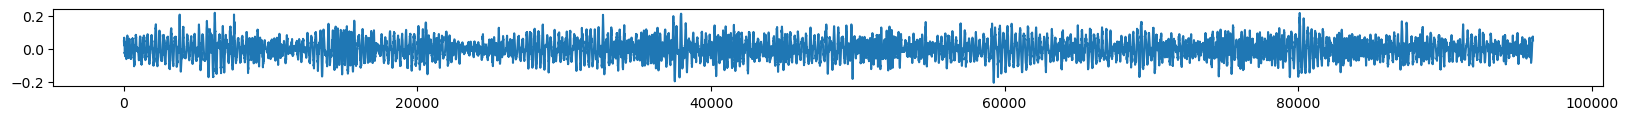

Finished epoch number 187 with a total of 10000 debug_seqs
 time: 2026-02-05 21:22:12.041292, epoch 188,  Loss: 0.3096
  Quantizer 0 Loss: 2.0488
  Quantizer 1 Loss: 3.0921
  Quantizer 2 Loss: 3.8409
  Quantizer 3 Loss: 4.2615
  Quantizer 4 Loss: 4.5357
  Quantizer 5 Loss: 4.7078
  Quantizer 6 Loss: 4.8868
  Quantizer 7 Loss: 4.9718
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


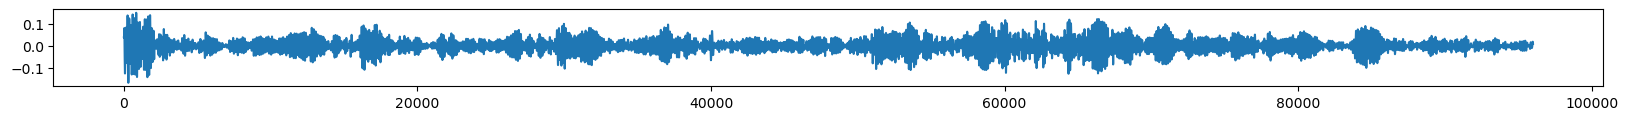

Finished epoch number 188 with a total of 10000 debug_seqs
 time: 2026-02-05 21:23:03.560108, epoch 189,  Loss: 0.3019
  Quantizer 0 Loss: 2.0410
  Quantizer 1 Loss: 3.0796
  Quantizer 2 Loss: 3.8229
  Quantizer 3 Loss: 4.2448
  Quantizer 4 Loss: 4.5253
  Quantizer 5 Loss: 4.6990
  Quantizer 6 Loss: 4.8748
  Quantizer 7 Loss: 4.9555
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


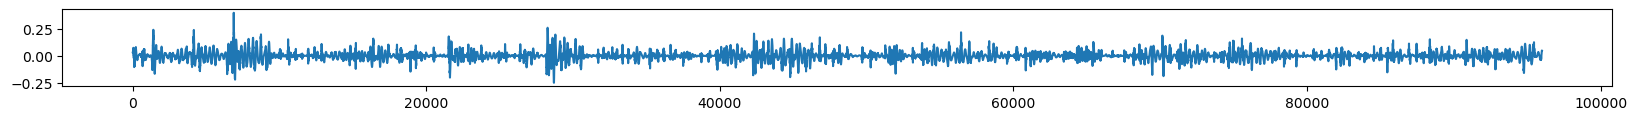

Finished epoch number 189 with a total of 10000 debug_seqs
 time: 2026-02-05 21:23:55.183392, epoch 190,  Loss: 0.3136
  Quantizer 0 Loss: 2.0451
  Quantizer 1 Loss: 3.0904
  Quantizer 2 Loss: 3.8323
  Quantizer 3 Loss: 4.2567
  Quantizer 4 Loss: 4.5406
  Quantizer 5 Loss: 4.7140
  Quantizer 6 Loss: 4.8972
  Quantizer 7 Loss: 4.9787
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


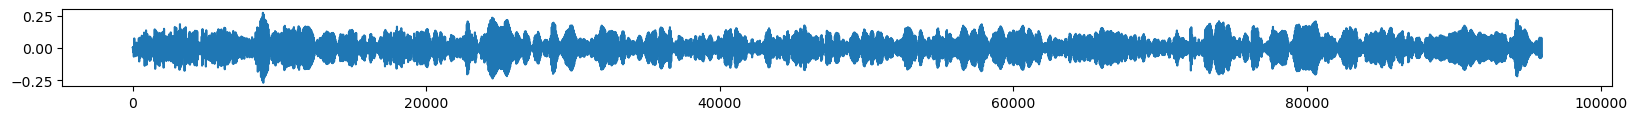

Finished epoch number 190 with a total of 10000 debug_seqs
 time: 2026-02-05 21:24:46.649304, epoch 191,  Loss: 0.3172
  Quantizer 0 Loss: 2.0427
  Quantizer 1 Loss: 3.0792
  Quantizer 2 Loss: 3.8198
  Quantizer 3 Loss: 4.2444
  Quantizer 4 Loss: 4.5235
  Quantizer 5 Loss: 4.6922
  Quantizer 6 Loss: 4.8755
  Quantizer 7 Loss: 4.9543
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


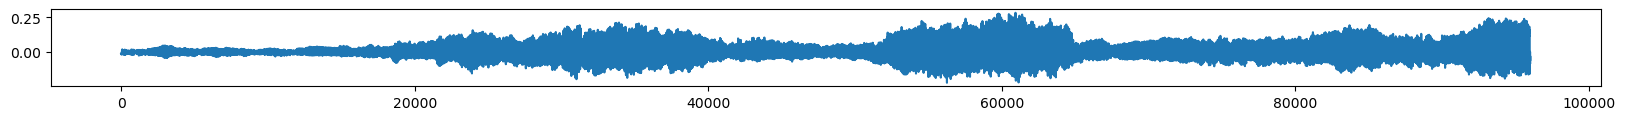

Finished epoch number 191 with a total of 10000 debug_seqs
 time: 2026-02-05 21:25:38.057489, epoch 192,  Loss: 0.3061
  Quantizer 0 Loss: 2.0435
  Quantizer 1 Loss: 3.0762
  Quantizer 2 Loss: 3.8236
  Quantizer 3 Loss: 4.2414
  Quantizer 4 Loss: 4.5196
  Quantizer 5 Loss: 4.6866
  Quantizer 6 Loss: 4.8701
  Quantizer 7 Loss: 4.9512
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


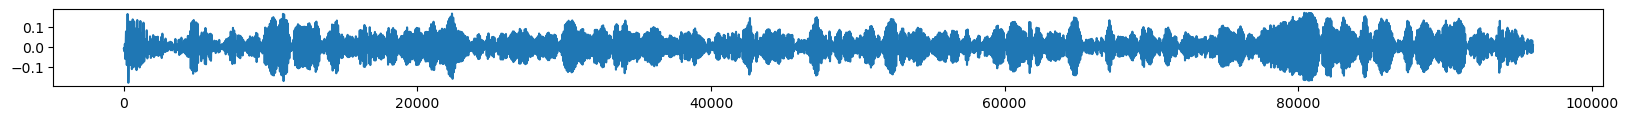

Finished epoch number 192 with a total of 10000 debug_seqs
 time: 2026-02-05 21:26:29.567468, epoch 193,  Loss: 0.3127
  Quantizer 0 Loss: 2.0331
  Quantizer 1 Loss: 3.0681
  Quantizer 2 Loss: 3.8107
  Quantizer 3 Loss: 4.2292
  Quantizer 4 Loss: 4.5091
  Quantizer 5 Loss: 4.6777
  Quantizer 6 Loss: 4.8622
  Quantizer 7 Loss: 4.9456
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


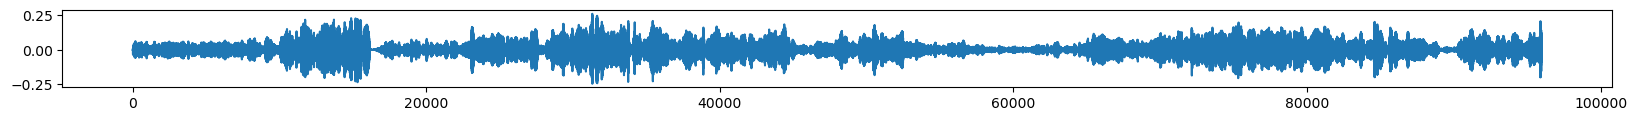

Finished epoch number 193 with a total of 10000 debug_seqs
 time: 2026-02-05 21:27:21.075481, epoch 194,  Loss: 0.3149
  Quantizer 0 Loss: 2.0424
  Quantizer 1 Loss: 3.0820
  Quantizer 2 Loss: 3.8288
  Quantizer 3 Loss: 4.2480
  Quantizer 4 Loss: 4.5257
  Quantizer 5 Loss: 4.7033
  Quantizer 6 Loss: 4.8826
  Quantizer 7 Loss: 4.9641
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


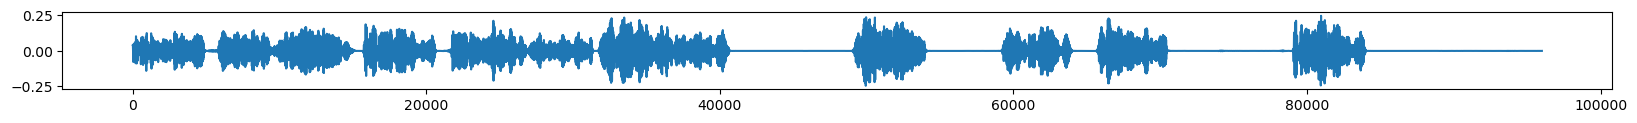

Finished epoch number 194 with a total of 10000 debug_seqs
 time: 2026-02-05 21:28:12.341583, epoch 195,  Loss: 0.3119
  Quantizer 0 Loss: 2.0344
  Quantizer 1 Loss: 3.0706
  Quantizer 2 Loss: 3.8117
  Quantizer 3 Loss: 4.2378
  Quantizer 4 Loss: 4.5134
  Quantizer 5 Loss: 4.6856
  Quantizer 6 Loss: 4.8705
  Quantizer 7 Loss: 4.9497
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


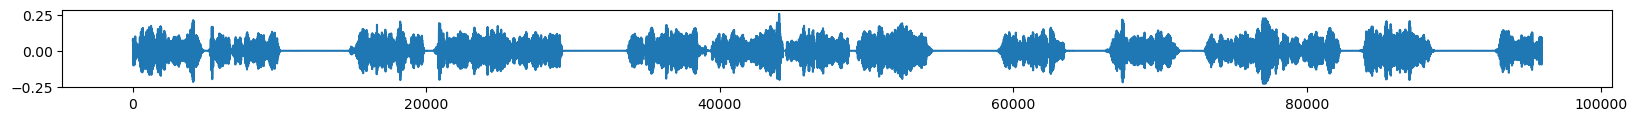

Finished epoch number 195 with a total of 10000 debug_seqs
 time: 2026-02-05 21:29:03.883608, epoch 196,  Loss: 0.3122
  Quantizer 0 Loss: 2.0304
  Quantizer 1 Loss: 3.0682
  Quantizer 2 Loss: 3.8104
  Quantizer 3 Loss: 4.2333
  Quantizer 4 Loss: 4.5071
  Quantizer 5 Loss: 4.6784
  Quantizer 6 Loss: 4.8612
  Quantizer 7 Loss: 4.9444
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


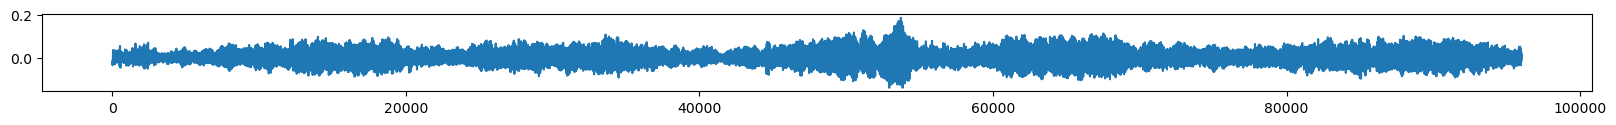

Finished epoch number 196 with a total of 10000 debug_seqs
 time: 2026-02-05 21:29:55.411666, epoch 197,  Loss: 0.3030
  Quantizer 0 Loss: 2.0343
  Quantizer 1 Loss: 3.0614
  Quantizer 2 Loss: 3.8016
  Quantizer 3 Loss: 4.2182
  Quantizer 4 Loss: 4.4972
  Quantizer 5 Loss: 4.6709
  Quantizer 6 Loss: 4.8562
  Quantizer 7 Loss: 4.9361
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


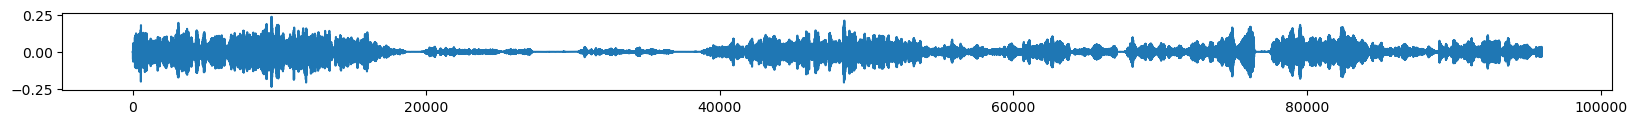

Finished epoch number 197 with a total of 10000 debug_seqs
 time: 2026-02-05 21:30:47.027927, epoch 198,  Loss: 0.3184
  Quantizer 0 Loss: 2.0427
  Quantizer 1 Loss: 3.0814
  Quantizer 2 Loss: 3.8172
  Quantizer 3 Loss: 4.2395
  Quantizer 4 Loss: 4.5142
  Quantizer 5 Loss: 4.6877
  Quantizer 6 Loss: 4.8653
  Quantizer 7 Loss: 4.9473
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


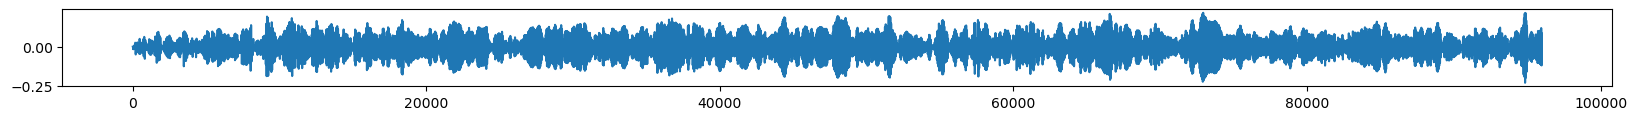

Finished epoch number 198 with a total of 10000 debug_seqs
 time: 2026-02-05 21:31:38.369559, epoch 199,  Loss: 0.3078
  Quantizer 0 Loss: 2.0343
  Quantizer 1 Loss: 3.0713
  Quantizer 2 Loss: 3.8099
  Quantizer 3 Loss: 4.2360
  Quantizer 4 Loss: 4.5148
  Quantizer 5 Loss: 4.6883
  Quantizer 6 Loss: 4.8711
  Quantizer 7 Loss: 4.9501
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


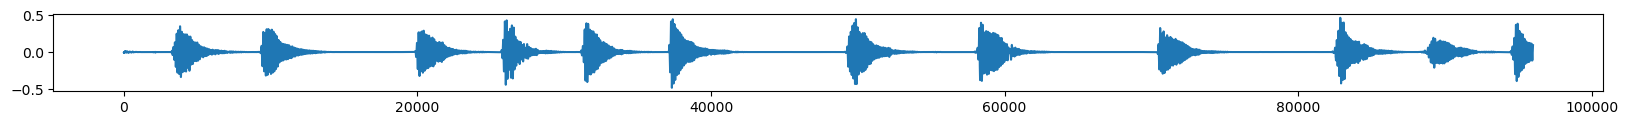

Finished epoch number 199 with a total of 10000 debug_seqs
 time: 2026-02-05 21:32:29.967401, epoch 200,  Loss: 0.3120
  Quantizer 0 Loss: 2.0421
  Quantizer 1 Loss: 3.0702
  Quantizer 2 Loss: 3.8063
  Quantizer 3 Loss: 4.2260
  Quantizer 4 Loss: 4.4998
  Quantizer 5 Loss: 4.6742
  Quantizer 6 Loss: 4.8519
  Quantizer 7 Loss: 4.9333
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


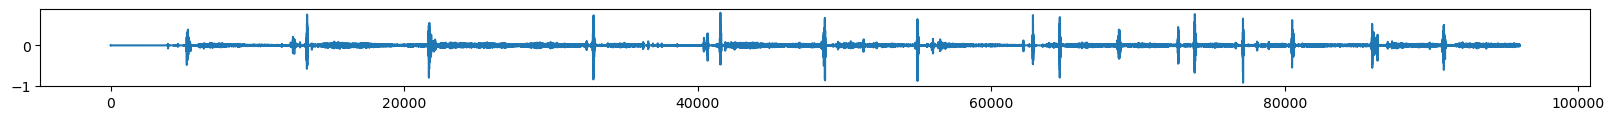

Saved checkpoint at epoch 200
Finished epoch number 200 with a total of 10000 debug_seqs
 time: 2026-02-05 21:33:21.340057, epoch 201,  Loss: 0.2819
  Quantizer 0 Loss: 2.0281
  Quantizer 1 Loss: 2.7180
  Quantizer 2 Loss: 3.3756
  Quantizer 3 Loss: 3.7986
  Quantizer 4 Loss: 4.0865
  Quantizer 5 Loss: 4.2891
  Quantizer 6 Loss: 4.4883
  Quantizer 7 Loss: 4.5939
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


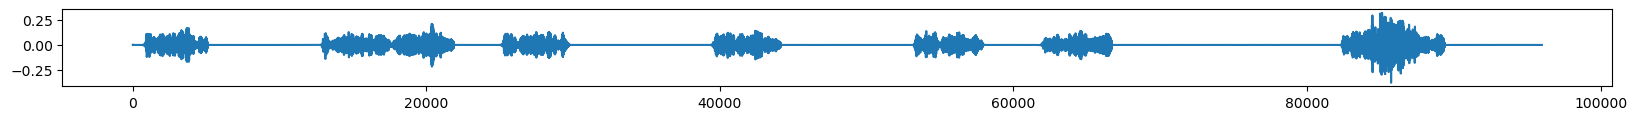

Finished epoch number 201 with a total of 10000 debug_seqs
 time: 2026-02-05 21:34:12.532603, epoch 202,  Loss: 0.2717
  Quantizer 0 Loss: 2.0260
  Quantizer 1 Loss: 2.6712
  Quantizer 2 Loss: 3.2917
  Quantizer 3 Loss: 3.7037
  Quantizer 4 Loss: 3.9947
  Quantizer 5 Loss: 4.1911
  Quantizer 6 Loss: 4.3955
  Quantizer 7 Loss: 4.4992
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


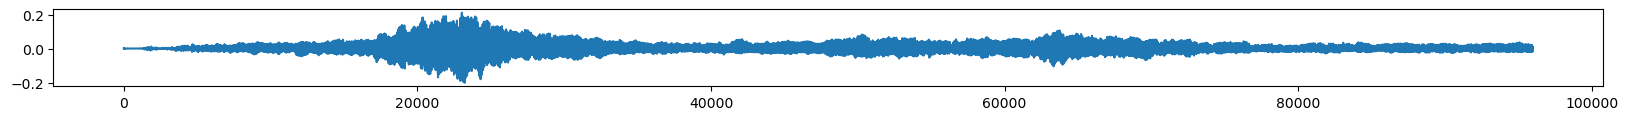

Finished epoch number 202 with a total of 10000 debug_seqs
 time: 2026-02-05 21:35:04.066951, epoch 203,  Loss: 0.2700
  Quantizer 0 Loss: 2.0157
  Quantizer 1 Loss: 2.6628
  Quantizer 2 Loss: 3.2714
  Quantizer 3 Loss: 3.6786
  Quantizer 4 Loss: 3.9647
  Quantizer 5 Loss: 4.1650
  Quantizer 6 Loss: 4.3664
  Quantizer 7 Loss: 4.4730
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


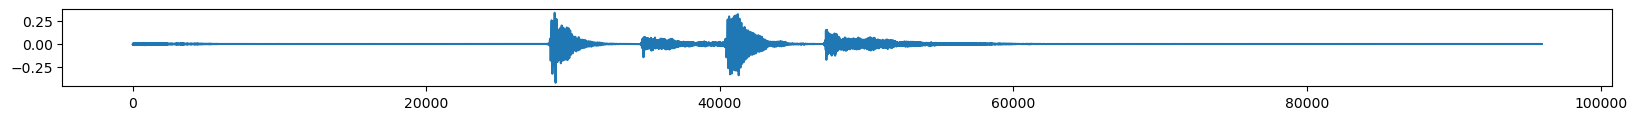

Finished epoch number 203 with a total of 10000 debug_seqs
 time: 2026-02-05 21:35:55.476611, epoch 204,  Loss: 0.2818
  Quantizer 0 Loss: 2.0173
  Quantizer 1 Loss: 2.6517
  Quantizer 2 Loss: 3.2591
  Quantizer 3 Loss: 3.6613
  Quantizer 4 Loss: 3.9473
  Quantizer 5 Loss: 4.1398
  Quantizer 6 Loss: 4.3397
  Quantizer 7 Loss: 4.4477
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


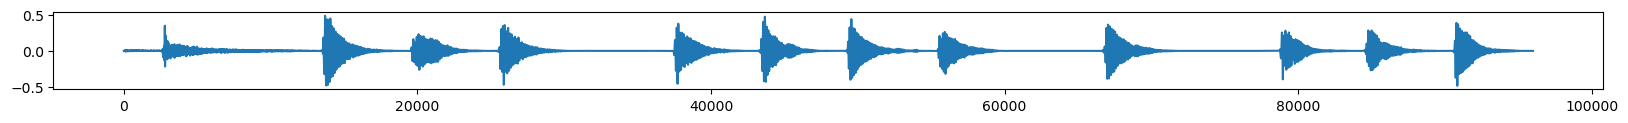

Finished epoch number 204 with a total of 10000 debug_seqs
 time: 2026-02-05 21:36:47.014713, epoch 205,  Loss: 0.2778
  Quantizer 0 Loss: 2.0267
  Quantizer 1 Loss: 2.6667
  Quantizer 2 Loss: 3.2681
  Quantizer 3 Loss: 3.6729
  Quantizer 4 Loss: 3.9556
  Quantizer 5 Loss: 4.1521
  Quantizer 6 Loss: 4.3524
  Quantizer 7 Loss: 4.4577
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


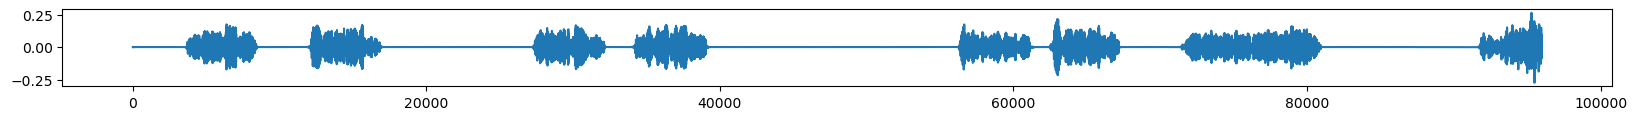

Finished epoch number 205 with a total of 10000 debug_seqs
 time: 2026-02-05 21:37:38.599490, epoch 206,  Loss: 0.2702
  Quantizer 0 Loss: 2.0175
  Quantizer 1 Loss: 2.6536
  Quantizer 2 Loss: 3.2508
  Quantizer 3 Loss: 3.6523
  Quantizer 4 Loss: 3.9374
  Quantizer 5 Loss: 4.1311
  Quantizer 6 Loss: 4.3287
  Quantizer 7 Loss: 4.4360
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


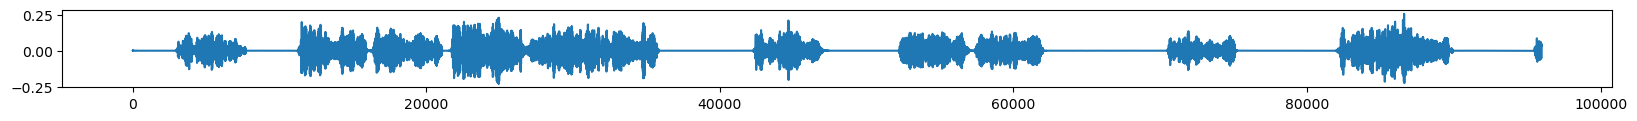

Finished epoch number 206 with a total of 10000 debug_seqs
 time: 2026-02-05 21:38:30.128509, epoch 207,  Loss: 0.2757
  Quantizer 0 Loss: 2.0176
  Quantizer 1 Loss: 2.6427
  Quantizer 2 Loss: 3.2459
  Quantizer 3 Loss: 3.6455
  Quantizer 4 Loss: 3.9282
  Quantizer 5 Loss: 4.1270
  Quantizer 6 Loss: 4.3232
  Quantizer 7 Loss: 4.4306
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


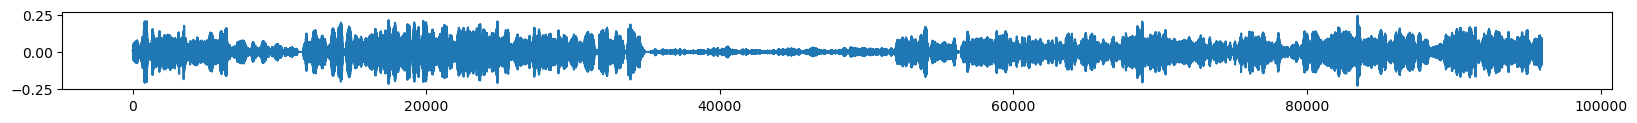

Finished epoch number 207 with a total of 10000 debug_seqs
 time: 2026-02-05 21:39:21.506277, epoch 208,  Loss: 0.2725
  Quantizer 0 Loss: 2.0251
  Quantizer 1 Loss: 2.6574
  Quantizer 2 Loss: 3.2598
  Quantizer 3 Loss: 3.6613
  Quantizer 4 Loss: 3.9420
  Quantizer 5 Loss: 4.1325
  Quantizer 6 Loss: 4.3282
  Quantizer 7 Loss: 4.4403
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


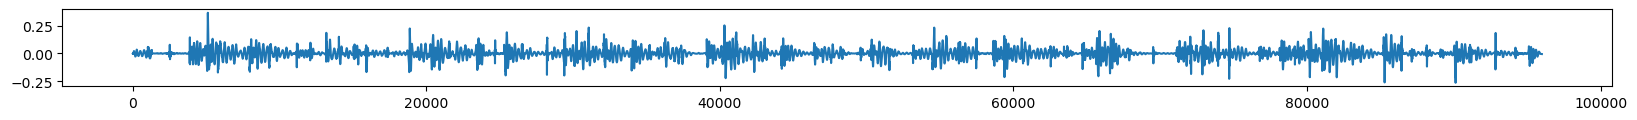

Finished epoch number 208 with a total of 10000 debug_seqs
 time: 2026-02-05 21:40:12.954572, epoch 209,  Loss: 0.2697
  Quantizer 0 Loss: 2.0284
  Quantizer 1 Loss: 2.6575
  Quantizer 2 Loss: 3.2597
  Quantizer 3 Loss: 3.6533
  Quantizer 4 Loss: 3.9392
  Quantizer 5 Loss: 4.1265
  Quantizer 6 Loss: 4.3256
  Quantizer 7 Loss: 4.4310
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


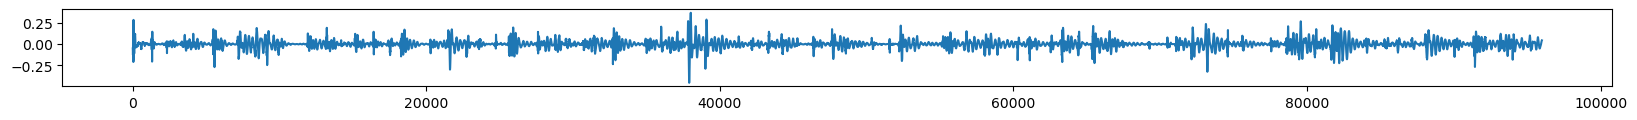

Finished epoch number 209 with a total of 10000 debug_seqs
 time: 2026-02-05 21:41:04.313910, epoch 210,  Loss: 0.2774
  Quantizer 0 Loss: 2.0207
  Quantizer 1 Loss: 2.6419
  Quantizer 2 Loss: 3.2487
  Quantizer 3 Loss: 3.6500
  Quantizer 4 Loss: 3.9317
  Quantizer 5 Loss: 4.1283
  Quantizer 6 Loss: 4.3275
  Quantizer 7 Loss: 4.4374
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


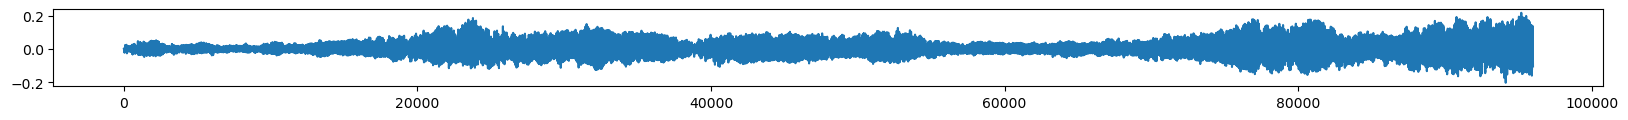

Finished epoch number 210 with a total of 10000 debug_seqs
 time: 2026-02-05 21:41:55.844404, epoch 211,  Loss: 0.2789
  Quantizer 0 Loss: 2.0337
  Quantizer 1 Loss: 2.6569
  Quantizer 2 Loss: 3.2493
  Quantizer 3 Loss: 3.6474
  Quantizer 4 Loss: 3.9268
  Quantizer 5 Loss: 4.1153
  Quantizer 6 Loss: 4.3145
  Quantizer 7 Loss: 4.4205
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


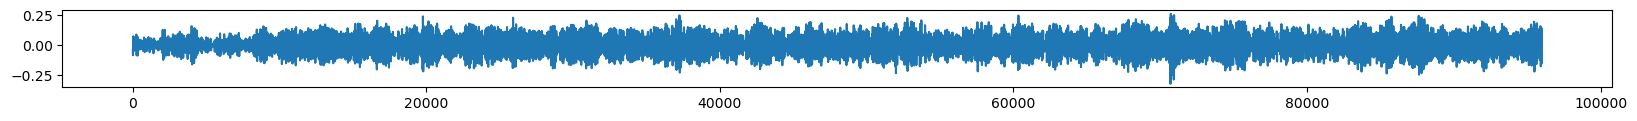

Finished epoch number 211 with a total of 10000 debug_seqs
 time: 2026-02-05 21:42:47.103923, epoch 212,  Loss: 0.2687
  Quantizer 0 Loss: 2.0203
  Quantizer 1 Loss: 2.6457
  Quantizer 2 Loss: 3.2437
  Quantizer 3 Loss: 3.6454
  Quantizer 4 Loss: 3.9193
  Quantizer 5 Loss: 4.1217
  Quantizer 6 Loss: 4.3194
  Quantizer 7 Loss: 4.4236
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


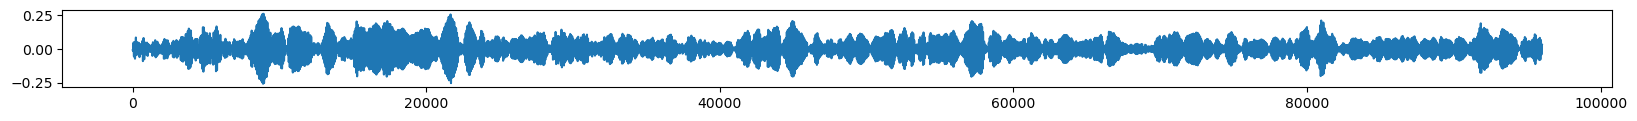

Finished epoch number 212 with a total of 10000 debug_seqs
 time: 2026-02-05 21:43:38.369657, epoch 213,  Loss: 0.2660
  Quantizer 0 Loss: 2.0163
  Quantizer 1 Loss: 2.6416
  Quantizer 2 Loss: 3.2397
  Quantizer 3 Loss: 3.6391
  Quantizer 4 Loss: 3.9235
  Quantizer 5 Loss: 4.1186
  Quantizer 6 Loss: 4.3126
  Quantizer 7 Loss: 4.4208
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


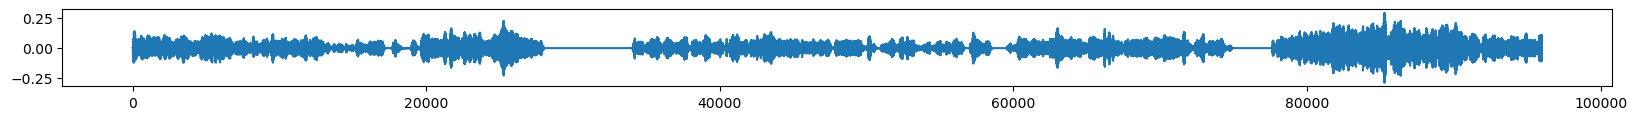

Finished epoch number 213 with a total of 10000 debug_seqs
 time: 2026-02-05 21:44:29.750413, epoch 214,  Loss: 0.2752
  Quantizer 0 Loss: 2.0286
  Quantizer 1 Loss: 2.6488
  Quantizer 2 Loss: 3.2498
  Quantizer 3 Loss: 3.6454
  Quantizer 4 Loss: 3.9270
  Quantizer 5 Loss: 4.1212
  Quantizer 6 Loss: 4.3147
  Quantizer 7 Loss: 4.4250
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


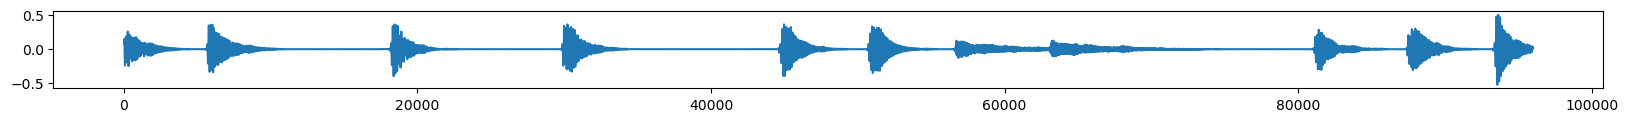

Finished epoch number 214 with a total of 10000 debug_seqs
 time: 2026-02-05 21:45:20.810384, epoch 215,  Loss: 0.2671
  Quantizer 0 Loss: 2.0179
  Quantizer 1 Loss: 2.6445
  Quantizer 2 Loss: 3.2458
  Quantizer 3 Loss: 3.6441
  Quantizer 4 Loss: 3.9263
  Quantizer 5 Loss: 4.1181
  Quantizer 6 Loss: 4.3180
  Quantizer 7 Loss: 4.4282
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


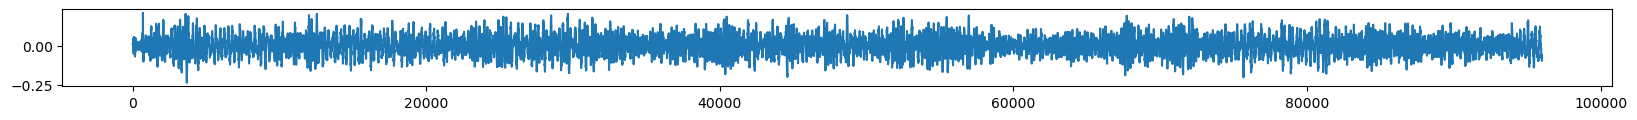

Finished epoch number 215 with a total of 10000 debug_seqs
 time: 2026-02-05 21:46:12.214293, epoch 216,  Loss: 0.2664
  Quantizer 0 Loss: 2.0130
  Quantizer 1 Loss: 2.6389
  Quantizer 2 Loss: 3.2347
  Quantizer 3 Loss: 3.6362
  Quantizer 4 Loss: 3.9221
  Quantizer 5 Loss: 4.1165
  Quantizer 6 Loss: 4.3167
  Quantizer 7 Loss: 4.4264
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


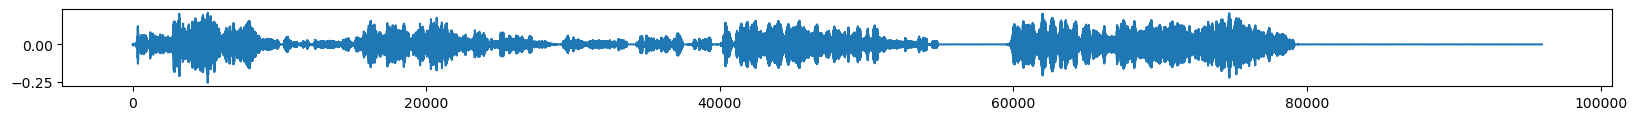

Finished epoch number 216 with a total of 10000 debug_seqs
 time: 2026-02-05 21:47:03.206336, epoch 217,  Loss: 0.2695
  Quantizer 0 Loss: 2.0192
  Quantizer 1 Loss: 2.6380
  Quantizer 2 Loss: 3.2385
  Quantizer 3 Loss: 3.6365
  Quantizer 4 Loss: 3.9158
  Quantizer 5 Loss: 4.1095
  Quantizer 6 Loss: 4.3073
  Quantizer 7 Loss: 4.4118
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


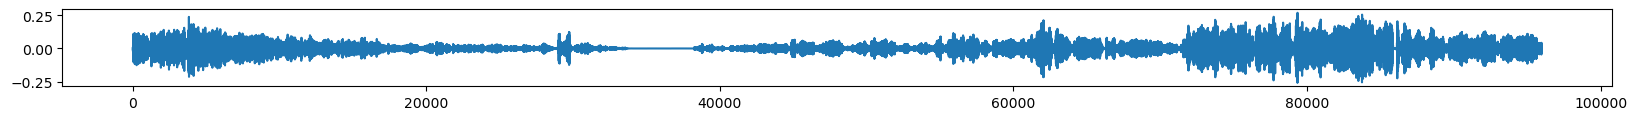

Finished epoch number 217 with a total of 10000 debug_seqs
 time: 2026-02-05 21:47:54.533647, epoch 218,  Loss: 0.2698
  Quantizer 0 Loss: 2.0116
  Quantizer 1 Loss: 2.6304
  Quantizer 2 Loss: 3.2264
  Quantizer 3 Loss: 3.6230
  Quantizer 4 Loss: 3.9056
  Quantizer 5 Loss: 4.1021
  Quantizer 6 Loss: 4.2953
  Quantizer 7 Loss: 4.3985
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


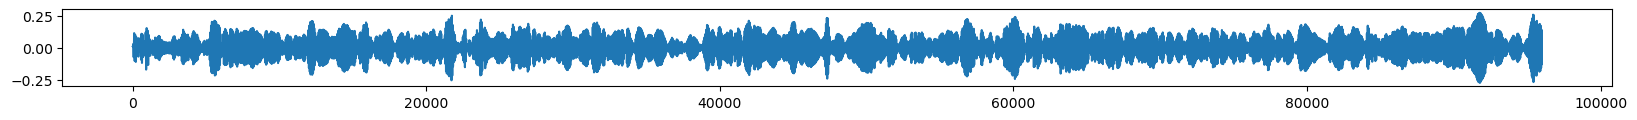

Finished epoch number 218 with a total of 10000 debug_seqs
 time: 2026-02-05 21:48:45.937494, epoch 219,  Loss: 0.2809
  Quantizer 0 Loss: 2.0144
  Quantizer 1 Loss: 2.6335
  Quantizer 2 Loss: 3.2278
  Quantizer 3 Loss: 3.6246
  Quantizer 4 Loss: 3.9104
  Quantizer 5 Loss: 4.1010
  Quantizer 6 Loss: 4.3004
  Quantizer 7 Loss: 4.4025
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


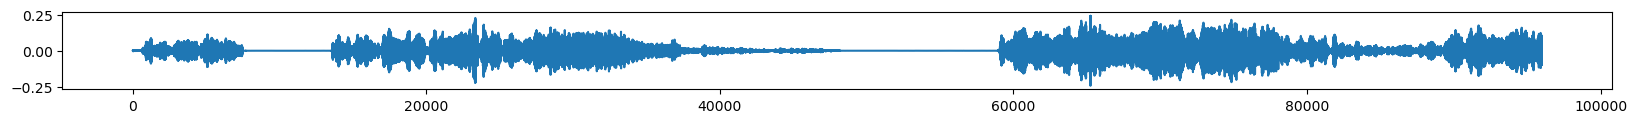

Finished epoch number 219 with a total of 10000 debug_seqs
 time: 2026-02-05 21:49:37.410529, epoch 220,  Loss: 0.2748
  Quantizer 0 Loss: 2.0191
  Quantizer 1 Loss: 2.6386
  Quantizer 2 Loss: 3.2399
  Quantizer 3 Loss: 3.6337
  Quantizer 4 Loss: 3.9117
  Quantizer 5 Loss: 4.1027
  Quantizer 6 Loss: 4.3015
  Quantizer 7 Loss: 4.4059
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


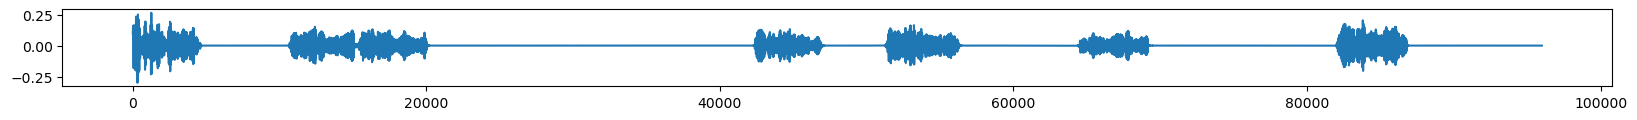

Finished epoch number 220 with a total of 10000 debug_seqs
 time: 2026-02-05 21:50:29.255101, epoch 221,  Loss: 0.2779
  Quantizer 0 Loss: 2.0147
  Quantizer 1 Loss: 2.6288
  Quantizer 2 Loss: 3.2260
  Quantizer 3 Loss: 3.6275
  Quantizer 4 Loss: 3.9067
  Quantizer 5 Loss: 4.1021
  Quantizer 6 Loss: 4.2973
  Quantizer 7 Loss: 4.4020
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


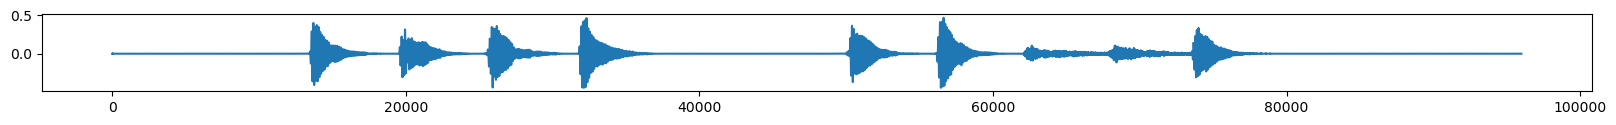

Finished epoch number 221 with a total of 10000 debug_seqs
 time: 2026-02-05 21:51:20.731540, epoch 222,  Loss: 0.2798
  Quantizer 0 Loss: 2.0124
  Quantizer 1 Loss: 2.6277
  Quantizer 2 Loss: 3.2337
  Quantizer 3 Loss: 3.6277
  Quantizer 4 Loss: 3.9138
  Quantizer 5 Loss: 4.1109
  Quantizer 6 Loss: 4.3129
  Quantizer 7 Loss: 4.4183
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


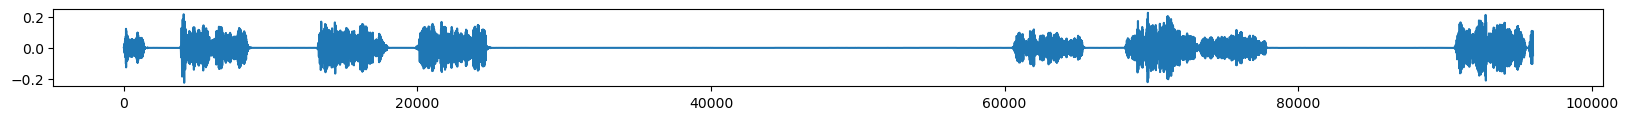

Finished epoch number 222 with a total of 10000 debug_seqs
 time: 2026-02-05 21:52:11.972126, epoch 223,  Loss: 0.2742
  Quantizer 0 Loss: 2.0242
  Quantizer 1 Loss: 2.6486
  Quantizer 2 Loss: 3.2424
  Quantizer 3 Loss: 3.6442
  Quantizer 4 Loss: 3.9262
  Quantizer 5 Loss: 4.1219
  Quantizer 6 Loss: 4.3206
  Quantizer 7 Loss: 4.4261
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


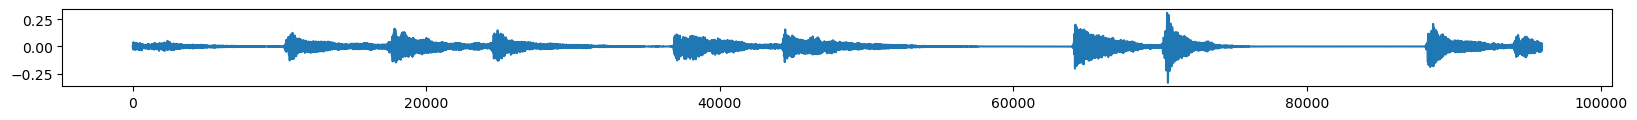

Finished epoch number 223 with a total of 10000 debug_seqs
 time: 2026-02-05 21:53:03.488458, epoch 224,  Loss: 0.2795
  Quantizer 0 Loss: 2.0100
  Quantizer 1 Loss: 2.6302
  Quantizer 2 Loss: 3.2285
  Quantizer 3 Loss: 3.6265
  Quantizer 4 Loss: 3.9081
  Quantizer 5 Loss: 4.0993
  Quantizer 6 Loss: 4.3010
  Quantizer 7 Loss: 4.4038
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


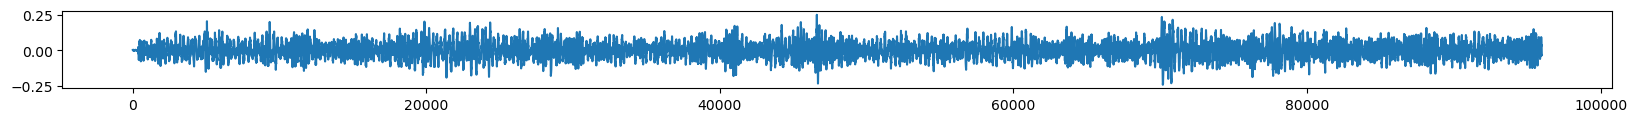

Finished epoch number 224 with a total of 10000 debug_seqs
 time: 2026-02-05 21:53:54.701975, epoch 225,  Loss: 0.2682
  Quantizer 0 Loss: 2.0135
  Quantizer 1 Loss: 2.6335
  Quantizer 2 Loss: 3.2372
  Quantizer 3 Loss: 3.6353
  Quantizer 4 Loss: 3.9157
  Quantizer 5 Loss: 4.1113
  Quantizer 6 Loss: 4.3084
  Quantizer 7 Loss: 4.4190
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (96000,)


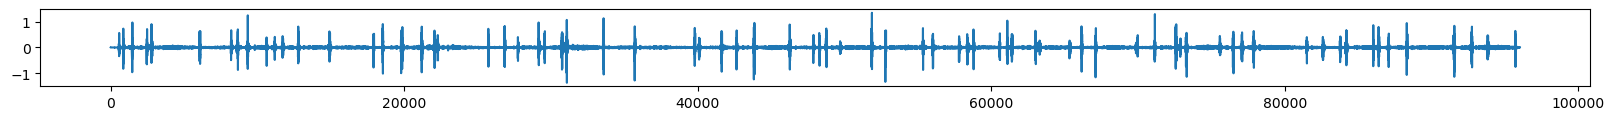

Saved checkpoint at epoch 225
Training time taken: 3:15:24
Saved checkpoint at epoch 225


'/home/lonce/TESTING/RNeNcodec/dev_notebooks/output/20260205_183830_datapreptest_dynamic_forkad/checkpoints/last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


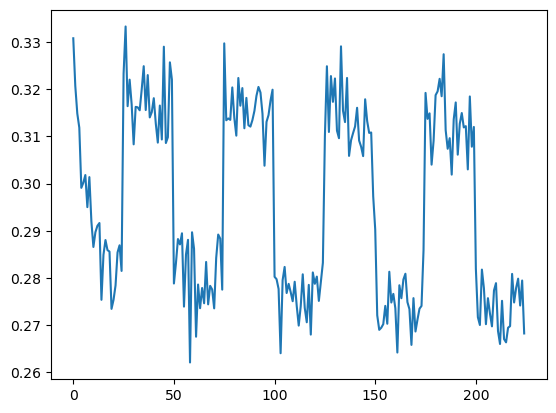

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.33077308654785154,
 0.3206936264038086,
 0.3148332405090332,
 0.31181663513183594,
 0.29908164978027346,
 0.3001763153076172,
 0.3017960357666016,
 0.29499967575073244,
 0.3013606834411621,
 0.2919807243347168,
 0.28656023025512695,
 0.28969350814819333,
 0.2910481071472168,
 0.29163679122924807,
 0.2753675079345703,
 0.2848940658569336,
 0.2880269432067871,
 0.2858909606933594,
 0.2855863380432129,
 0.27344747543334963,
 0.2753568077087402,
 0.2784115219116211,
 0.28541656494140627,
 0.28692047119140623,
 0.28148475646972654,
 0.3232596969604492,
 0.33327182769775393,
 0.3163895034790039,
 0.3220047378540039,
 0.31682247161865235,
 0.3083035087585449,
 0.3162452507019043,
 0.3161454772949219,
 0.31551496505737303,
 0.3199302673339844,
 0.3248599624633789,
 0.3155668640136719,
 0.32297447204589846,
 0.3140045356750488,
 0.31512372970581054,
 0.31807680130004884,
 0.3126998519897461,
 0.3086675071716309,
 0.3165205764770508,
 0.309329833984375,
 0.32898727416992185,
 0.30857780456542